In [3]:
import quspin as qs
import numpy as np
import matplotlib.pyplot as plt
from quspin.operators import hamiltonian # Hamiltonians and operators
from quspin.basis import spin_basis_1d # Hilbert space spin basis
from quspin.operators import quantum_operator
import math
from quspin.basis import spin_basis_general
from matplotlib import colors
import random
import time

In [4]:
pulse_time = 0.0478e-3 # in s
free_time = 15000 * pulse_time # 0.6e-3 # in s
rabi_frequency = 2*np.pi*(1/pulse_time)/4 # From RbCs Ramsey Paper https://doi.org/10.1088/2058-9565/aaee35 Figure 7
print((pulse_time*rabi_frequency)/(np.pi/2)) # Check pulse time and rabi frequency give a pi/2 pulse area 

0.9999999999999999


In [5]:
def intmatrix(Lx, J, xs=1, ys=1, theta=0, phi=0, Ly='_', plot=False):
    # define side length of simulated system as L
    if Lx % 2 == 1:
        pass
    else:
        Lx += 1

    if Ly == '_':
        Ly = Lx
    else:
        if Ly % 2 == 1:
            pass
        else:
            Ly += 1
    
    mat = np.zeros((Lx, Ly))
    
    L_xrange, L_yrange = range(Lx), range(Ly)
    center_xindex = int(L_xrange[-1]/2)
    center_yindex = int(L_yrange[-1]/2)
    
    
    center = np.array([xs*center_xindex, ys*center_yindex, 0]) #position of matrix center (in 3D)
    
    quan_axis = [np.cos(theta)*np.sin(phi), np.sin(theta)*np.sin(phi), np.cos(phi)] #quantization axis as an unit vector
    
    
    for i in L_xrange:
        for j in L_yrange:
            displacement = np.array([xs*i, ys*j, 0]) - center
            r = np.linalg.norm(displacement)
            angle = np.arccos(displacement @ quan_axis/r)
            mat[i, j] = J*(1-3*(np.cos(angle)**2))/(r**3)
    mat[center_xindex, center_yindex] = 0.0

    if plot == True:
        fig, ax = plt.subplots()

        mat, xside, yside = intmatrix(Lx, J, Ly=Ly, theta=theta, phi=phi)
        couplings = np.transpose(mat) #transpose to show x and y axis correctly (this will also switch x and y corrdinate ordering when indexing)

        cmap = plt.cm.RdBu
        ax.matshow(couplings, cmap=cmap, norm=colors.CenteredNorm())

        for i in range(len(couplings)):
            for j in range(len(couplings[0])): 
                c = '{:g}'.format(float('{:.2g}'.format(couplings[i, j])))
                #c = '(' + str(j) + ', ' + str(i) + ')'
                    
                ax.text(j, i, str(c), va='center', ha='center')
    
    return mat, Lx, Ly #indexing interaction matrix is done with mat[x coordinate, y coordinate]

def up_prob(L, row_len, populations):
    basis = spin_basis_general(N=L, pauli=False)
    col_len = int(math.ceil(L/row_len))

    #contruct outer product of single particle up spin state operator to find the probability it is in up
    outer_products = []
    for i in range(L):
        factors = [[[0.5, i]], [[-1, i]]]
        opers = [['I', factors[0]], ['z', factors[1]]]
        input_dict = {'up': opers}
        outer_products.append(quantum_operator(input_dict, basis=basis))
        #__ = quantum_operator(input_dict, basis=basis).tohamiltonian()
        #print(__.toarray())


    #calculate the probability each particle is spin up for each time evolved
    results = []
    for i in np.transpose(populations):
        probs = np.zeros((col_len, row_len))
        for n in range(L):
            if n==4:
                print(outer_products[n].expt_value(i))
            probs[n//row_len][n%row_len] = outer_products[n].expt_value(i)
        results.append(probs)

    #print(results)
    return results

def up_pop_plot(L, populations, values, dep_var, fig, axes):
    #basis = [r'0', r'1']
    #labels = [r'0', r'1']
    #for i in range(L - 1):
        #labels = str_tens(labels, basis)
    n_rows = len(populations[0])
    print(populations[0][0])
    n_cols = len(populations[0][0])
    probs = [[matrix[i][j] for matrix in populations] for i in range(n_rows) for j in range(n_cols)]
    values = values*(10**3)    
    #fig, axes = plt.subplots(1, 1)
    for i in range(L):
        axes.plot(values, probs[i], label=f'Particle {i+1}')
        
    #for i in range(5):
        #print(populations[:,1][100*i])

    axes.set_ylabel(r"Probability of detecting $\left|1\right>$", fontsize=20)
    axes.set_xlabel(dep_var, fontsize=20)
    axes.legend(loc=1, prop={'size': 14})

    axes.minorticks_on()
    axes.tick_params(which='major', length=10, width=2, direction='in', bottom=True, top=True, left=True, right=True)
    axes.tick_params(which='minor', length=5, width=2, direction='in', bottom=True, top=True, left=True, right=True)
    axes.set_yticks([0, 0.5, 1]) 
    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16)
    
    plt.show(block=False)


def ran_occupied_sites(N, x, y): #dimensions of simulated lattice and no of particles to distribute
    total_sites = int(x*y)

    # Randomize which lattice sites are occupied
    occupied_sites = []
    free_sites = list(range(total_sites))
    
    for i in range(N):
        ran = random.randint(0, total_sites-i-1)
        #print('random int = ' + str(ran))
        occupied_sites.append(free_sites.pop(ran))
        
    return sorted(occupied_sites) #returns ordered list of N unique numbers between 0 and the total sites - 1 inclusive

def couples(sites, pairs, interactions, xy='_'):
    if xy == '_':    
        int_x, int_y = len(interactions)//2 + 1, len(interactions[0])//2 + 1 #dimensions of interaction matrix
    else:
        int_x, int_y = xy
    #use interaction matrix to get couplings between each occupied site and output this in the correct formatt with particle number
    couples = []
    for i in pairs:
        p1, p2 = sites[i[0]], sites[i[1]]
        
        couples.append([interactions[int_x - 1  + (p1 % int_x) - (p2 % int_x), int_y - 1 + (p1 // int_x) - (p2 // int_x)], i[0], i[1]]) 
    return couples

def tri_couples(angle):
    couples = [[1.0, 0, 1], [1.0, 1, 2], [(np.sin((np.pi - angle)/2)/np.sin(angle))**3, 0, 2]] 
    return couples

def pbc_couples(sites, pairs, interactions, xy='_'): #Constructs interaction strengths for periodic boundry conditions
    if xy == '_':    
        int_x, int_y = len(interactions)//2 + 1, len(interactions[0])//2 + 1 #centre of interaction matrix
    else:
        int_x, int_y = xy
    #use interaction matrix to get couplings between each occupied site and output this in the correct formatt with particle number
    couples = []
    for i in pairs:
        p1, p2 = sites[i[0]], sites[i[1]]
        dx, dy = (p1 % int_x) - (p2 % int_x), (p1 // int_x) - (p2 // int_x)
        
        if dx >= int_x:
            dx = dx - len(interactions)
        elif dx <= -int_x:
            dx = dx + len(interactions)
            
        if dy >= int_y:
            dy = dy - len(interactions[0])
        elif dy <= -int_y:
            dy = dy + len(interactions[0])
        
        couples.append([interactions[int_x - 1  + dx, int_y - 1 + dy], i[0], i[1]]) 
    return couples

def symm_mat(x, y, occupied_sites, basis, axis=1): #defult finds mirror plane transformation which flips x coordinates
    #only relevent if lattice simulated has the symmetry which is tested on basis staes
    #occupied sites labelled left to right up to down in basis
    #for rectangular simulated systems (but sites occupied can be picked)

    symm = np.zeros((len(basis), len(basis)))
    count1 = 0
    asymmetrics = []
    flips = []
    for i in basis:
        basis_on_lattice = np.zeros((x, y))
        count2 = 0
        for n in i:
            if n == 1:
                basis_on_lattice[occupied_sites[count2] % x, occupied_sites[count2] // x] = 1

            count2 += 1

        flipped = np.flip(basis_on_lattice, axis)
        
        
        if flipped == basis_on_lattice:
            symm[count1, count1] = 1
        else:
            asymmetrics.append(basis_on_lattice)
            flips.append(flipped)
        count1 += 1

    for state in asymmetrics:
        pair = np.where(flips == state)[0]
        symm[pair[0], pair[1]], symm[pair[1], pair[0]] = 1, 1

    return symm
    
def str_tens(A, B):
    new = []
    for i in A:
        for n in B:
            new.append(i + n)
    return new

def sparse_up_prob(L, row_len, col_len, populations):
    basis = spin_basis_general(N=L, pauli=False)
    #col_len = int(math.ceil(L/row_len))

    #contruct outer product of single particle up spin state operator to find the probability it is in up
    outer_products = []
    for i in range(L):
        factors = [[[0.5, i]], [[-1, i]]]
        opers = [['I', factors[0]], ['z', factors[1]]]
        input_dict = {'up': opers}
        outer_products.append(quantum_operator(input_dict, basis=basis))
        #__ = quantum_operator(input_dict, basis=basis).tohamiltonian()
        #print(__.toarray())


    #calculate the probability each particle is spin up for each time evolved
    results = []
    for i in np.transpose(populations):
        probs = []
        for n in range(L):
            probs.append(outer_products[n].expt_value(i))
        results.append(sum(probs)/L)

    #print(results)
    return results

#define pulse sequences
def pulse_ramsey(t, pulse_time, free_time, rabi_frequency):
    if t <= pulse_time:
        return rabi_frequency
    elif t < pulse_time + free_time:
        return 0 
    elif t <= 2 * pulse_time + free_time:
        return rabi_frequency
    else:
        return 0

def pulse_single(t, pulse_time, free_time, rabi_frequency):
    if t <= pulse_time:
        return rabi_frequency
    else:
        return 0

def no_pulse(t, pulse_time, free_time, rabi_frequency):
    return 0

def construct_H(N, J, det, ax, ay, Lx, params, pulse, theta=0, phi=0, Ly='_', int_plot=False, occupied_sites='_', pbc=False, tri=False, angle=np.pi):
    basis = spin_basis_general(N=N, pauli=False)
    #print(basis)
    if Ly == '_':
        Ly = 1

    #construct interaction
    sites = range(N)
    pairs = [[i, k] for idx, i in enumerate(sites) for k in sites[idx + 1:]]

    if tri == True:
        if N != 3:
            print('Invalid particle number')
        intr = tri_couples(angle)
    else:
        #interaction strengths between each particle
        interaction_matrix, _, _ = intmatrix(Lx*2 - 1, 1, xs=ax, ys=ay, theta=theta, phi=phi, Ly=Ly*2 - 1, plot=int_plot) 
        #above outputs 3 variables (also set J=1 in this function as it xJ at the end anyway) 
    
        #determin sites that are occupied (random or not)
        if occupied_sites == '_':
            sites = ran_occupied_sites(N, Lx, Ly)
        else:
            sites = sorted(occupied_sites) #make sure occupied sites is the correct length with numbers under total sites
    
        
        #contruct infomation in to reqired format
        if pbc == True: #For periodic boundry conditions
            intr = pbc_couples(sites, pairs, interaction_matrix)
        else:    
            intr = couples(sites, pairs, interaction_matrix)
    
    #construct resonant and detuning terms
    drive = [[1.0, i] for i in range(N)]
    detuning = [[1.0, i] for i in range(N)]

    operator_list_0 = [['z', detuning]]
    operator_list_1 = [['x', drive]]

    #print(intr)

    #construct full Hamiltonian
    interaction = [['+-', intr], ['-+', intr]]
    operator_dict = {'detuning': operator_list_0, 'drive': operator_list_1, 'interaction': interaction}
    H = quantum_operator(operator_dict, basis=basis)
    params_dict = dict(detuning=det, drive=(pulse, params), interaction=J)
    H_lmbda1 = H.tohamiltonian(params_dict)
    return H_lmbda1

def ensemble_Ramsey(samples, time, p_max, r_max, initial_state, N, J, det, ax, ay, params, pulse, theta=0, phi=0):
    results = []
    for i in range(samples):
        r = random.randint(0, int(3000*r_max/4))/1000
        p = p_max*(1 - (r/r_max)**2)
        side_length = int(np.sqrt(N/p))+1
        #print(side_length)
        #side_length = 2
        Hamiltonian = construct_H(N, J, det, ax, ay, side_length, params, pulse, theta=theta, phi=phi, Ly=side_length)
        populations = Hamiltonian.evolve(initial_state, 0, time)
        ups = sparse_up_prob(N, side_length, side_length, populations)
        results.append(ups[-1])
        #print('Sample ' + str(i) + ' completed')
    return sum(results)/samples

In [9]:
single_Ramsey_fringe = False
if single_Ramsey_fringe == True:
    start_time = time.time()

    intervals = 150
    holds = np.linspace(0, 300 * pulse_time, intervals)
    J = 1000
    L = 2
    row_len = L
    ax, ay = 1, 1
    
    psi_0 = np.zeros(2**L)
    psi_0[0] = 1 
    probs = []
    for free_time in holds:
        params = [pulse_time, free_time, rabi_frequency]
        H_lmb = construct_H(L, J, 0, ax, ay, row_len, params, pulse_ramsey)
        times = np.linspace(0, 2*pulse_time + free_time, 2)
        populations = H_lmb.evolve(psi_0, 0, times)
        #print(populations[0][-1])
        probs.append([abs(populations[0][-1])**2, abs(populations[1][-1])**2, abs(populations[2][-1])**2, abs(populations[3][-1])**2])
    print("--- %s seconds ---" % (time.time() - start_time))
    
    ket = [r'0', r'1']
    labels = [r'0', r'1']
    for i in range(L - 1):
        labels = str_tens(labels, ket)
    fig, axes = plt.subplots(1, 1)
    for i in range(2**L):
        axes.plot(holds*(10**3), [row[i] for row in probs], label='|' + labels[i] + r'$\rangle$')
        
        #for i in range(5):
            #print(populations[:,1][100*i])

    axes.set_ylabel(r"Probability", fontsize=20)
    axes.set_xlabel('Free evolution time (ms)', fontsize=20)
    axes.legend(loc=1, prop={'size': 14})

    axes.minorticks_on()
    axes.tick_params(which='major', length=10, width=2, direction='in', bottom=True, top=True, left=True, right=True)
    axes.tick_params(which='minor', length=5, width=2, direction='in', bottom=True, top=True, left=True, right=True)
    axes.set_yticks([0, 0.5, 1]) 
    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16)
    plt.savefig(f'{L}_Particle_ramsey.png', bbox_inches='tight')
    
    plt.show(block=False)
    

In [15]:
start_time = time.time()

intervals = 200
holds = np.linspace(0, 350 * pulse_time, intervals)
samples = 1

particles_per_sample = 5
J, det, ax, ay = 1200, 0, 1, 1
p_max, r_max = 0.0544, 1000
theta, phi = 0, 0

initial_state = np.zeros(2**particles_per_sample)
initial_state[-1] = 1

up_probabilities = []
progress = 0
for i in holds:
    #time = [0, pulse_time, pulse_time + i, 2*pulse_time + i]
    times2 = np.linspace(0, 2*pulse_time + i, 2)
    params = [pulse_time, i, rabi_frequency]
    up_probabilities.append(ensemble_Ramsey(samples, times2, p_max, r_max, initial_state, particles_per_sample, J, det, ax, ay, params, pulse_ramsey, theta=theta, phi=phi))
    progress += 1
    print(str(progress) + '/' + str(intervals) + ' Done')
print("--- %s seconds ---" % (time.time() - start_time))

/var/folders/ln/c_qknrr51xbgxcyyp59605kr0000gn/T/ipykernel_88981/3440858033.py:32: RuntimeWarning: invalid value encountered in scalar divide
  angle = np.arccos(displacement @ quan_axis/r)


Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
1/200 Done
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
2/200 Done
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
3/200 Done
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check

/var/folders/ln/c_qknrr51xbgxcyyp59605kr0000gn/T/ipykernel_88981/3440858033.py:32: RuntimeWarning: invalid value encountered in scalar divide
  angle = np.arccos(displacement @ quan_axis/r)


Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
15/200 Done
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
16/200 Done
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
17/200 Done
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity ch

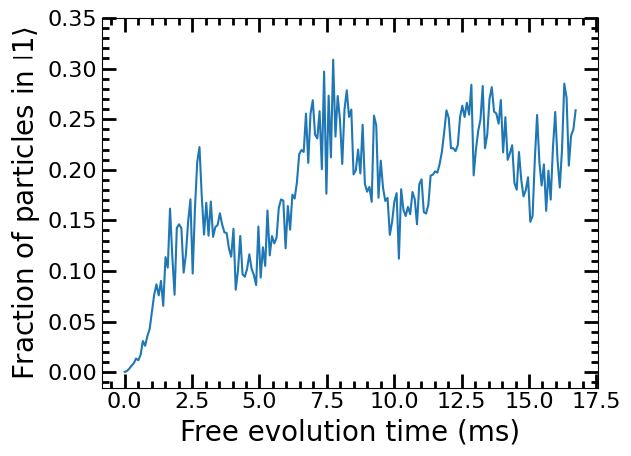

In [26]:
fig, axes = plt.subplots(1, 1)

axes.plot(holds*(10**3), up_probabilities)
        
    #for i in range(5):
        #print(populations[:,1][100*i])

axes.set_ylabel(r"Fraction of particles in $\left|1\right>$", fontsize=20)
axes.set_xlabel('Free evolution time (ms)', fontsize=20)

axes.minorticks_on()
axes.tick_params(which='major', length=10, width=2, direction='in', bottom=True, top=True, left=True, right=True)
axes.tick_params(which='minor', length=5, width=2, direction='in', bottom=True, top=True, left=True, right=True)
yticks = np.linspace(0, 0.35, 8)
axes.set_yticks(yticks) 
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
plt.savefig(f'Ensemble_Ramsey_{particles_per_sample}_Particle_{samples}_samples_{J}Hz.png', bbox_inches='tight')
    
plt.show(block=False)

In [11]:
def generate_radial_distribution(lattice_filling_max, r_max):
    def generator_dist(r):
        return lattice_filling_max*(1 - (r/r_max)**2)
    return generator_dist

def generate_uniform_distribution(lattice_filling):
    def uniform_dist(r):
        return lattice_filling
    return uniform_dist

def prob_mat(function, lattice_dimensions, samples=1, ax=1, ay=1, polar=True):
    
    dist = np.zeros(lattice_dimensions)
    cen_x, cen_y = lattice_dimensions[0]/2, lattice_dimensions[1]/2
    
    cy = -cen_y
    for i in range(lattice_dimensions[1]):
        cx = -cen_x
        for n in range(lattice_dimensions[0]):
            sam_xpoints, sam_ypoints = np.linspace(cx - ax/2, cx + ax/2, samples + 1), np.linspace(cy - ay/2, cy + ay/2, samples + 1)

            if polar == True:
                values = []
                for u in sam_xpoints:
                    sam_radii = np.sqrt(u**2 + sam_ypoints**2)
                    values.append(function(sam_radii))
            ###################### next 'else' code is untested #####################
            else:
                values = []
                for u in sam_xpoints:
                    values.append(function(u, sam_ypoints))

            segments = 0
            for l in range(samples**2):
                avg_func = sum([values[ l % samples][ l // samples], values[ l % samples + 1][ l // samples], values[ l % samples][ l // samples + 1], values[ l % samples + 1][ l // samples + 1]])/4 
                segments += avg_func * (ax/samples) * (ay/samples)
            
            dist[n, i] = segments

            cx += ax
        cy += ay

    return dist

def count_geometry(image, kernel, particle_no='_'):
    kernel = np.array(kernel)
    m, n = kernel.shape
    if particle_no == '_':
        particle_no = m*n
        #print(particle_no)
    y, x = image.shape
    y = y - m + 1
    x = x - n + 1
    
    found = 0
    for i in range(y):
        for j in range(x):
            if np.sum(image[i:i+m, j:j+n]*kernel) == particle_no:
                found += 1
    return found

def rotated(array_2d):
    list_of_tuples = zip(*array_2d[::-1])
    return [list(elem) for elem in list_of_tuples]

def pattern_search(image, kernel, particle_no = '_', symmetrical=False):
    rot = 4
    if symmetrical == True:
        rot = 2
    patterns_found = 0
    for i in range(rot):
        patterns_found += count_geometry(image, kernel, particle_no=particle_no)
        kernel = rotated(kernel)
    return patterns_found

def random_config(discrete_dist):
    y, x = discrete_dist.shape
    config = np.zeros((y, x))
    for i in range(y):
        for n in range(x):
            roll = random.randint(0, 1000)/1000
            if roll <= discrete_dist[i, n]:
                config[i, n] = 1
    return config
            

In [72]:
for i in range(2):
    print('activated, no = ' + str(i))

activated, no = 0
activated, no = 1


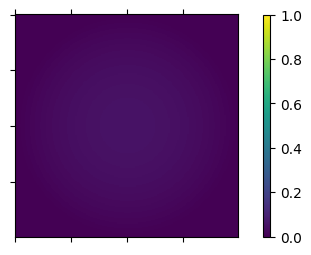

In [74]:
max_lattice_filling = 0.05
r_max = 100

distribution = generate_radial_distribution(max_lattice_filling, r_max)

result = prob_mat(distribution, (2*r_max, 2*r_max), samples=1, ax=1, ay=1, polar=True)

fig, ax = plt.subplots()

ax.xaxis.set_tick_params(labelbottom=False)
ax.yaxis.set_tick_params(labelleft=False)
ax.set_xticks([])
ax.set_yticks([])

cax = ax.matshow(result)
cax.set_clim(0, 1)
cbar = fig.colorbar(cax, location="right", 
        shrink=0.6,
        aspect=30,
        fraction=0.5)

plt.savefig(f'discrete_lattice_dist.pdf', bbox_inches='tight')

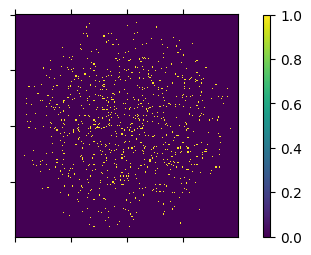

In [76]:
sample_config = random_config(result)

fig, ax = plt.subplots()

ax.xaxis.set_tick_params(labelbottom=False)
ax.yaxis.set_tick_params(labelleft=False)
ax.set_xticks([])
ax.set_yticks([])

cax = ax.matshow(sample_config)
cax.set_clim(0, 1)
cbar = fig.colorbar(cax, location="right", 
        shrink=0.6,
        aspect=30,
        fraction=0.5)
plt.savefig(f'example_system_4.pdf', bbox_inches='tight')

In [80]:
norm = 0
for i in sample_config:
    for n in i:
        norm += n

print('Number of particles: ' + str(norm))

no = [[1]]
pair = [[1, 1]]
diag_pair = [[1, 0], [0, 1]]
triangle = [[1, 1], [1, 0]]
chain_3 = [[1, 1, 1]]
chain_4 = [[1, 1, 1, 1]]

def find_geometries(discrete_dist, samples):
    no = [[1]]
    pair = [[0, 0, 0, 0], [0, 1, 1, 0], [0, 0, 0, 0]]
    diag_pair = [[0, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 0]]
    triangle = [[0, 0, 0, 0], [0, 1, 1, 0], [0, 1, 0, 0], [0, 0, 0, 0]]
    chain_3 = [[0, 0, 0, 0, 0], [0, 1, 1, 1, 0], [0, 0, 0, 0, 0]]
    chain_4 = [[0, 0, 0, 0, 0, 0], [0, 1, 1, 1, 1, 0], [0, 0, 0, 0, 0, 0]]

    particle_no, pair_no, diag_pair_no, triangle_no, chain_3_no, chain_4_no = [], [], [], [], [], []
    for i in range(samples):
        sample_config = random_config(discrete_dist)
        sample_config = np.pad(sample_config, ((1, 1), (1, 1)), 'constant', constant_values=((0, 0), (0, 0)))
        particle_no.append(pattern_search(sample_config, no, symmetrical=True)/2)
        pair_no.append(pattern_search(sample_config, pair, symmetrical=True))
        diag_pair_no.append(pattern_search(sample_config, diag_pair, symmetrical=True, particle_no=2))
        triangle_no.append(pattern_search(sample_config, triangle, particle_no=3))
        chain_3_no.append(pattern_search(sample_config, chain_3, symmetrical=True, particle_no=3))
        chain_4_no.append(pattern_search(sample_config, chain_4, symmetrical=True))

    # returns list of averages and list of standard deviations
    return np.array([np.mean(particle_no), np.mean(pair_no), np.mean(diag_pair_no), np.mean(triangle_no), np.mean(chain_3_no), np.mean(chain_4_no)]), [np.std(particle_no), np.std(pair_no), np.std(diag_pair_no), np.std(triangle_no), np.std(chain_3_no), np.std(chain_4_no)]

averages, standard_deviations = find_geometries(result, 5)
print(averages)
print('Number of particles, Number of pairs, Number of diagonal pairs, Number of triangles, Number of 3 particle chains, Number of 4 particle chains')



Number of particles: 856.0
[808.6   0.   51.6   2.4   2.    0. ]
Number of particles, Number of pairs, Number of diagonal pairs, Number of triangles, Number of 3 particle chains, Number of 4 particle chains


<ErrorbarContainer object of 3 artists>

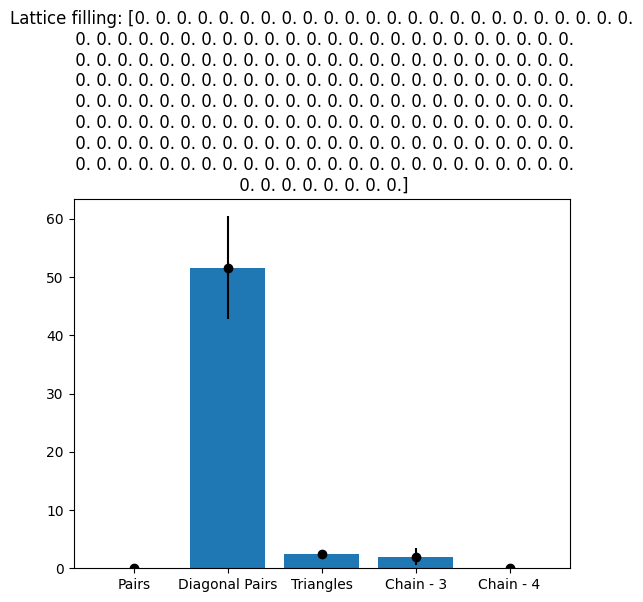

In [82]:
labels = ['Particle number', 'Pairs', 'Diagonal Pairs', 'Triangles', 'Chain - 3', 'Chain - 4']

fig, ax = plt.subplots()
ax.set_title('Lattice filling: ' + str(i))
ax.bar(labels[1:], averages[1:])
ax.errorbar(labels[1:], averages[1:], yerr=standard_deviations[1:], color='black', fmt='o')

In [84]:
a = np.array([[1, 2, 3], 
     [4, 5, 6]])
print(a)
print(rotated(rotated(a)))
for i in range(4):
    print(i)

[[1 2 3]
 [4 5 6]]
[[np.int64(6), np.int64(5), np.int64(4)], [np.int64(3), np.int64(2), np.int64(1)]]
0
1
2
3


In [86]:
lat_fils = np.linspace(0, 1, 50)
r_max = 100
iterations = 15
labels = ['Particle number', 'Pairs', 'Diagonal Pairs', 'Triangles', 'Chain - 3', 'Chain - 4']


all_avg, all_std = [], []
for i in lat_fils:
        distribution = generate_radial_distribution(i, r_max)
        result = prob_mat(distribution, (2*r_max, 2*r_max), samples=1, ax=1, ay=1, polar=True)
        averages, standard_deviations = find_geometries(result, iterations)
        all_avg.append(averages[1:])
        all_std.append(standard_deviations[1:])
        print('Done: ' + str(i))

all_avg, all_std = np.array(all_avg), np.array(all_std)

Done: 0.0
Done: 0.02040816326530612
Done: 0.04081632653061224
Done: 0.061224489795918366
Done: 0.08163265306122448
Done: 0.1020408163265306
Done: 0.12244897959183673
Done: 0.14285714285714285
Done: 0.16326530612244897
Done: 0.18367346938775508
Done: 0.2040816326530612
Done: 0.22448979591836732
Done: 0.24489795918367346
Done: 0.26530612244897955
Done: 0.2857142857142857
Done: 0.3061224489795918
Done: 0.32653061224489793
Done: 0.3469387755102041
Done: 0.36734693877551017
Done: 0.3877551020408163
Done: 0.4081632653061224
Done: 0.42857142857142855
Done: 0.44897959183673464
Done: 0.4693877551020408
Done: 0.4897959183673469
Done: 0.5102040816326531
Done: 0.5306122448979591
Done: 0.5510204081632653
Done: 0.5714285714285714
Done: 0.5918367346938775
Done: 0.6122448979591836
Done: 0.6326530612244897
Done: 0.6530612244897959
Done: 0.673469387755102
Done: 0.6938775510204082
Done: 0.7142857142857142
Done: 0.7346938775510203
Done: 0.7551020408163265
Done: 0.7755102040816326
Done: 0.7959183673469387


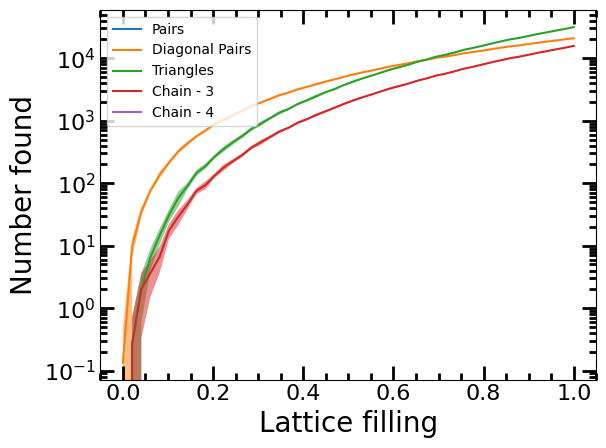

In [87]:
fig, axes = plt.subplots()

for i in range(len(labels[1:])):
    
    axes.plot(lat_fils, np.transpose(all_avg)[i], label=labels[i + 1])
    axes.fill_between(lat_fils, np.transpose(all_avg)[i]-np.transpose(all_std)[i], np.transpose(all_avg)[i]+np.transpose(all_std)[i], alpha=0.5)    
    #for i in range(5):
        #print(populations[:,1][100*i])

axes.set_xlabel(r"Lattice filling", fontsize=20)
axes.set_ylabel('Number found', fontsize=20)

axes.minorticks_on()
axes.tick_params(which='major', length=10, width=2, direction='in', bottom=True, top=True, left=True, right=True)
axes.tick_params(which='minor', length=5, width=2, direction='in', bottom=True, top=True, left=True, right=True)
plt.yticks(fontsize=16)
plt.xticks(fontsize=16)
axes.legend(loc=2)
plt.yscale("log")


plt.savefig(f'geomerty_search.pdf', bbox_inches='tight')
plt.show(block=False)

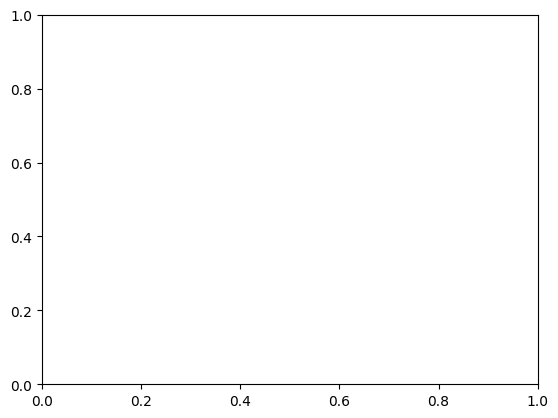

In [88]:
# animation
from matplotlib.animation import PillowWriter



metadata = dict(title='Movie', artist='codinglikemad')
writer = PillowWriter(fps=24, metadata=metadata)

fig, ax = plt.subplots()

with writer.saving(fig, f'distribution_geometry_frequency.gif', 100):
    for i in lat_fils:
        distribution = generate_radial_distribution(i, r_max)
        result = prob_mat(distribution, (2*r_max, 2*r_max), samples=1, ax=1, ay=1, polar=True)
        averages, standard_deviations = find_geometries(result, iterations)
        
        ax.set_title('Lattice filling: ' + str(i))
        ax.bar(labels[1:], averages[1:])
        ax.errorbar(labels[1:], averages[1:], yerr=standard_deviations[1:], color='black', fmt='o')
        
        writer.grab_frame()
        ax.clear()

In [13]:
def str_tens(A, B):
    new = []
    for i in A:
        for n in B:
            new.append(i + n)
    return new

In [15]:
print('A\nB')

A
B


Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :180.0

[0. 0. 1.]


/var/folders/ln/c_qknrr51xbgxcyyp59605kr0000gn/T/ipykernel_45503/3804342073.py:76: ComplexWarning: Casting complex values to real discards the imaginary part
  probs[n//row_len][n%row_len] = outer_products[n].expt_value(i)


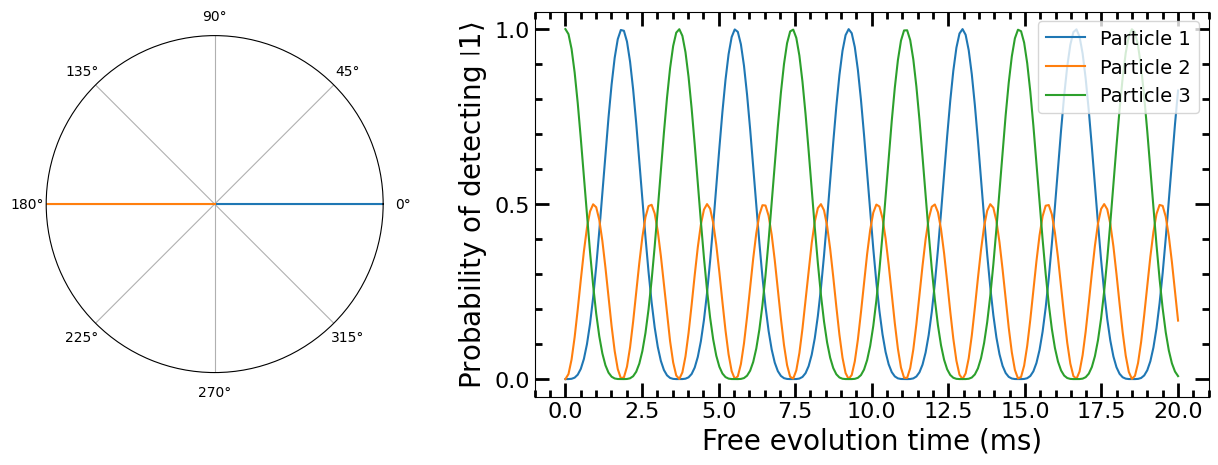

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :179.55388471177946

[0. 0. 1.]


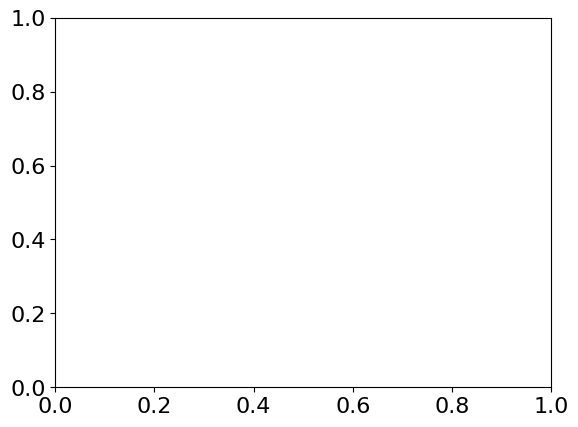

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :179.1077694235589

[0. 0. 1.]


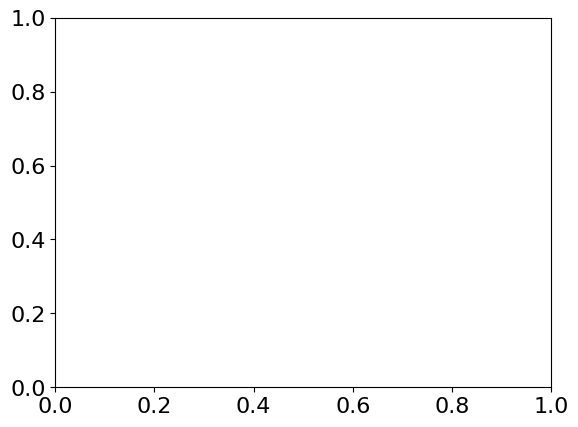

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :178.66165413533835

[0. 0. 1.]


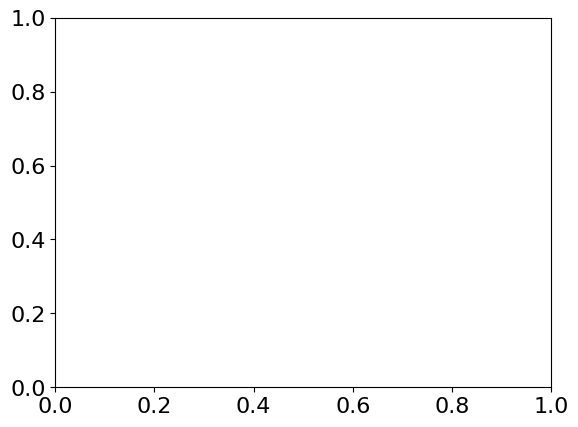

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :178.2155388471178

[0. 0. 1.]


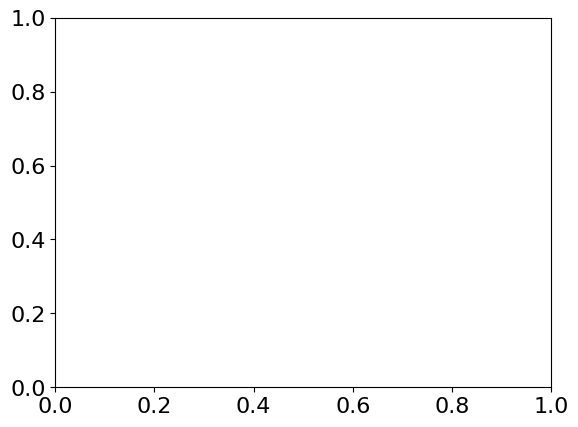

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :177.76942355889724

[0. 0. 1.]


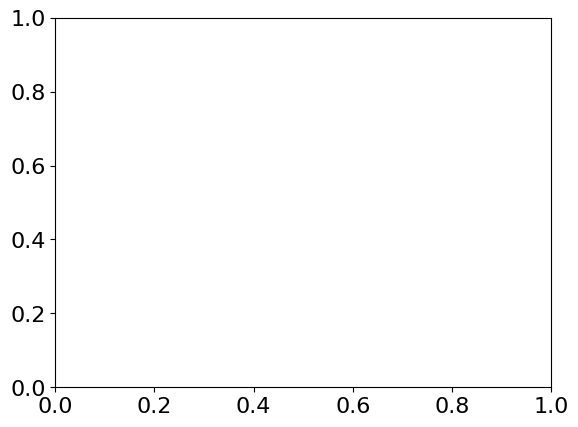

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :177.3233082706767

[0. 0. 1.]


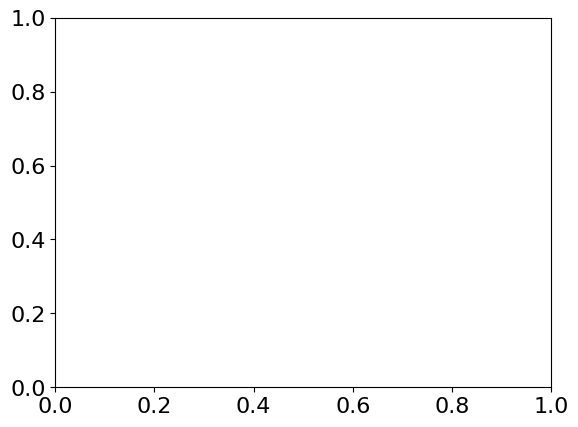

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :176.87719298245617

[0. 0. 1.]


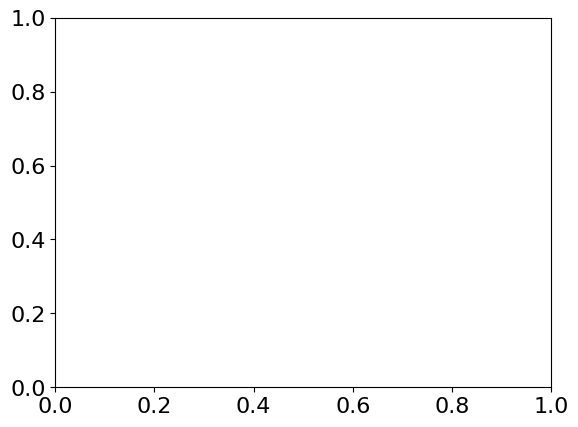

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :176.4310776942356

[0. 0. 1.]


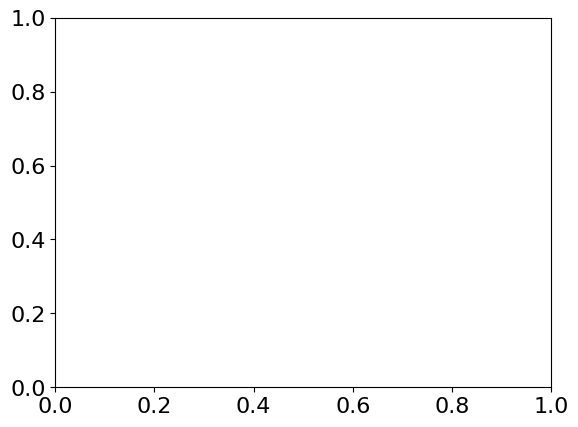

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :175.98496240601506

[0. 0. 1.]


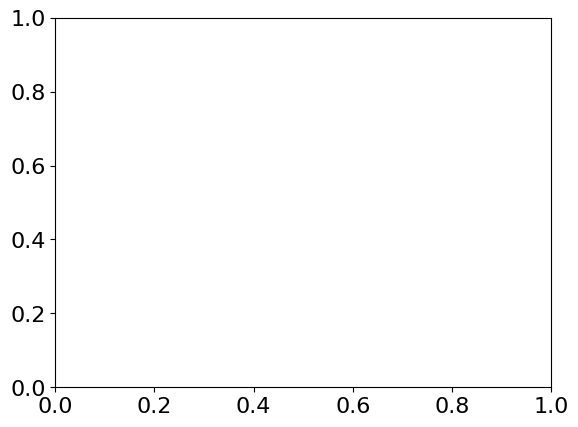

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :175.53884711779446

[0. 0. 1.]


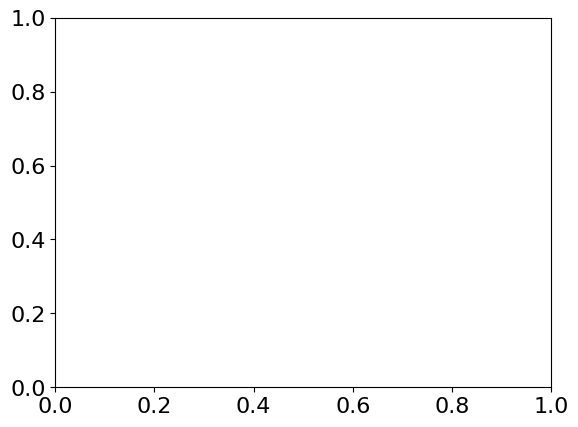

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :175.09273182957392

[0. 0. 1.]


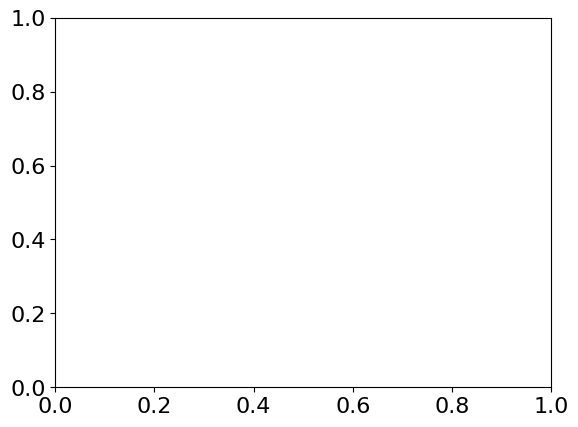

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :174.64661654135338

[0. 0. 1.]


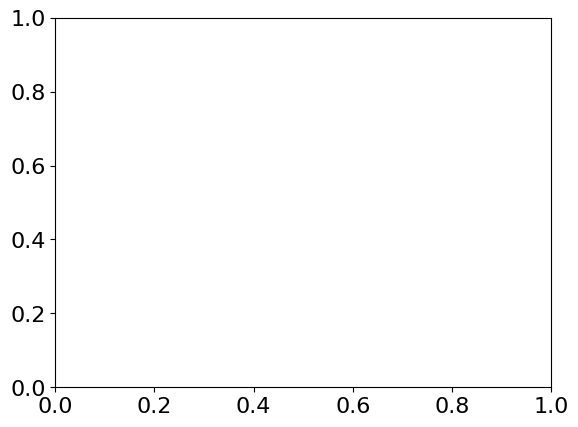

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :174.20050125313284

[0. 0. 1.]


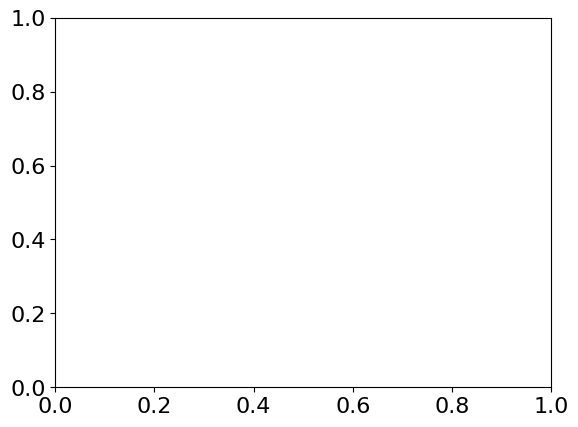

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :173.75438596491227

[0. 0. 1.]


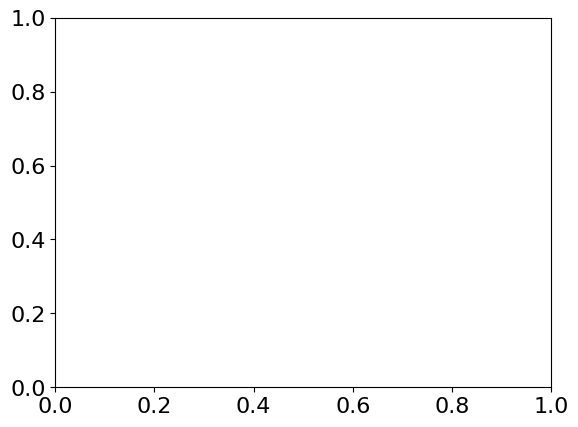

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :173.3082706766917

[0. 0. 1.]


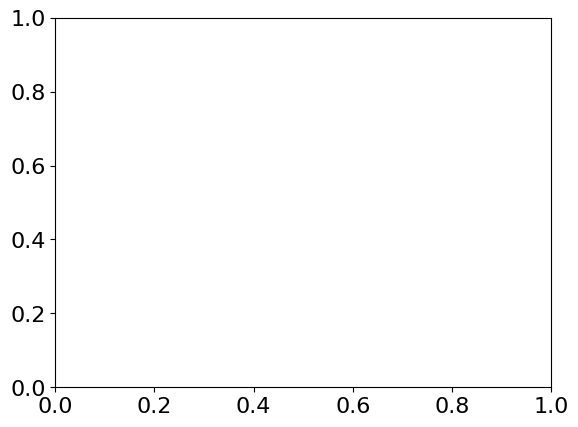

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :172.86215538847117

[0. 0. 1.]


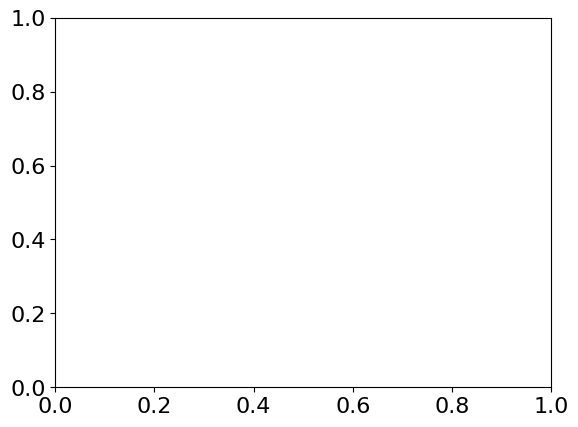

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :172.41604010025063

[0. 0. 1.]


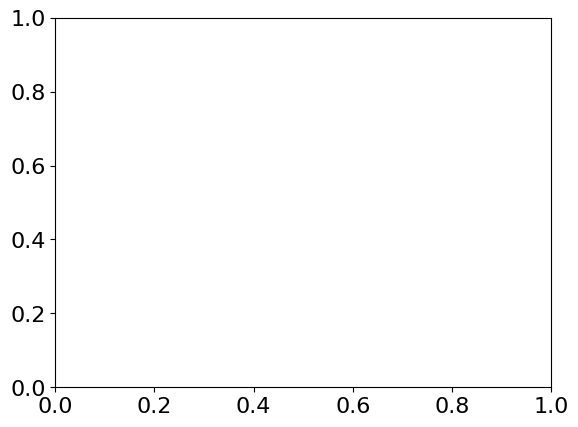

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :171.9699248120301

[0. 0. 1.]


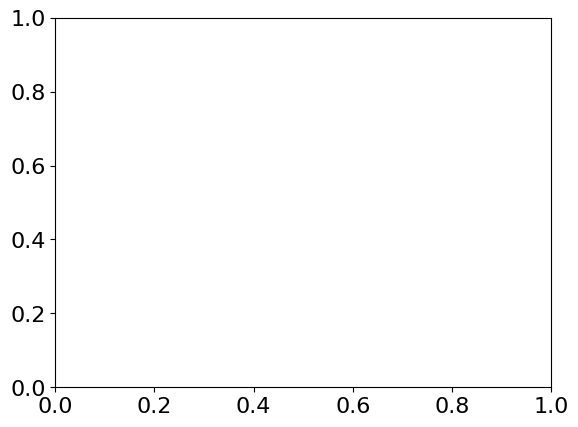

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :171.52380952380955

[0. 0. 1.]


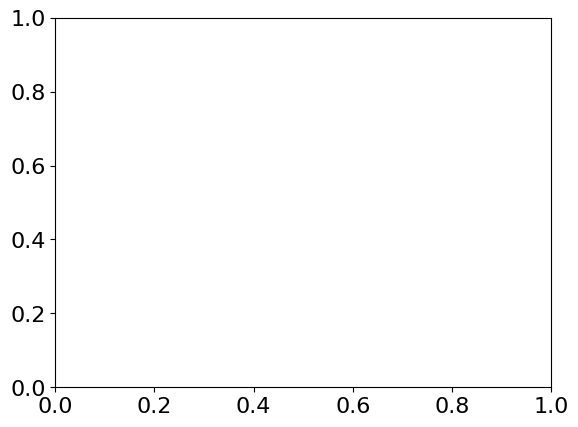

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :171.07769423558898

[0. 0. 1.]


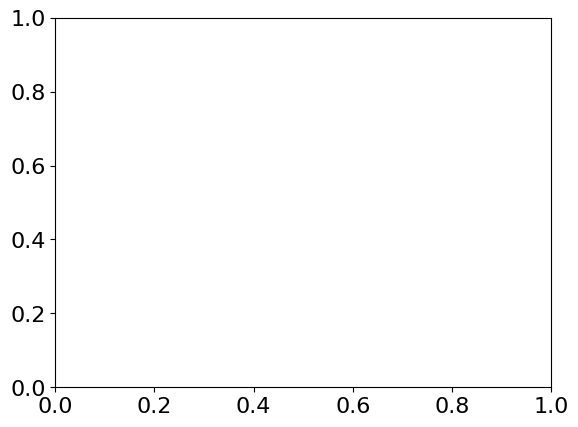

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :170.6315789473684

[0. 0. 1.]


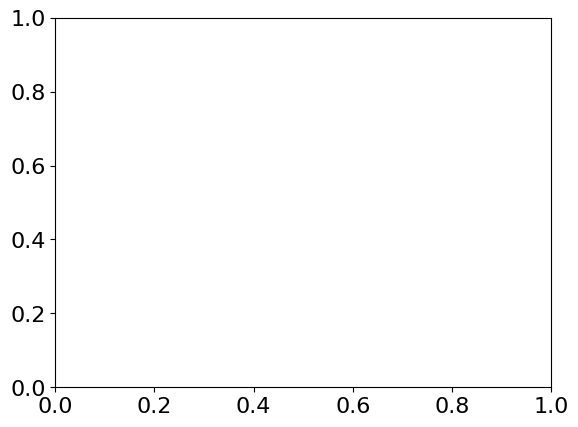

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :170.18546365914787

[0. 0. 1.]


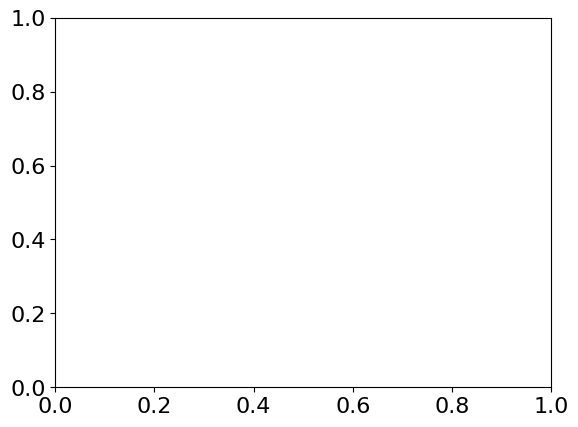

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :169.73934837092733

[0. 0. 1.]


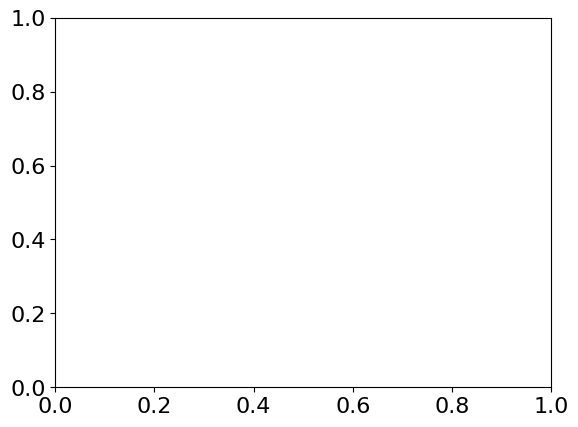

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :169.2932330827068

[0. 0. 1.]


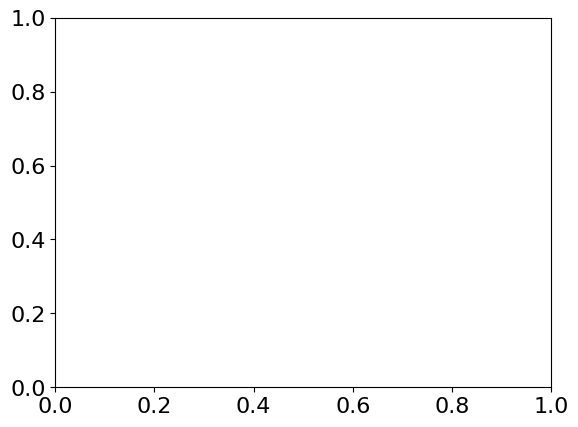

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :168.84711779448625

[0. 0. 1.]


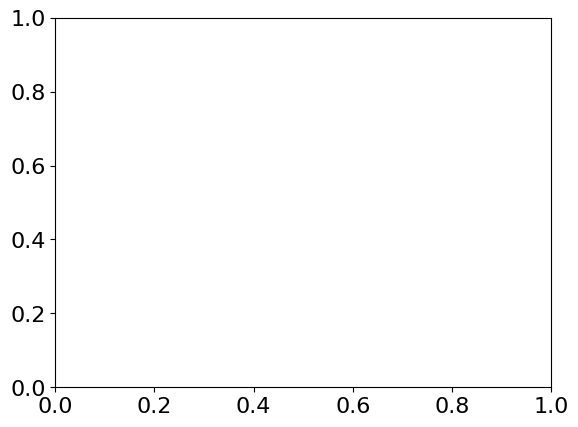

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :168.40100250626568

[0. 0. 1.]


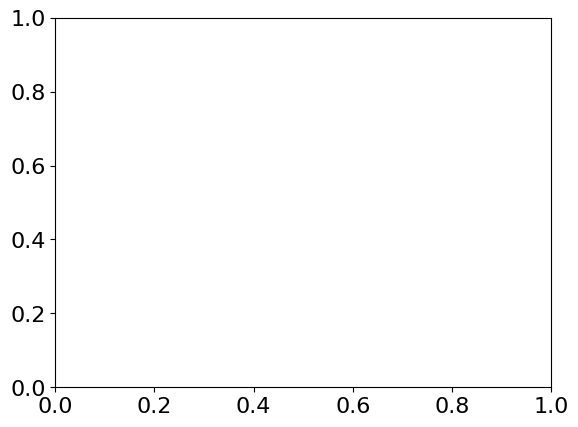

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :167.9548872180451

[0. 0. 1.]


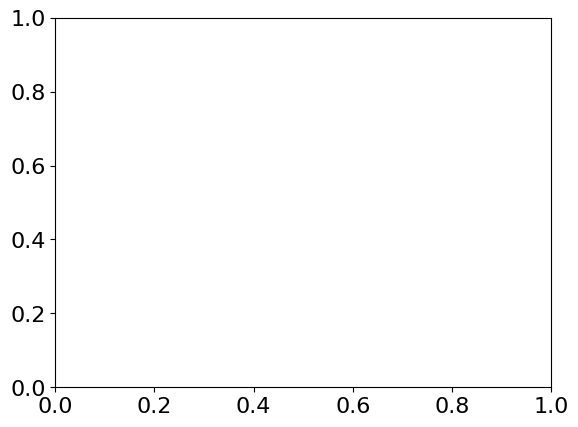

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :167.50877192982455

[0. 0. 1.]


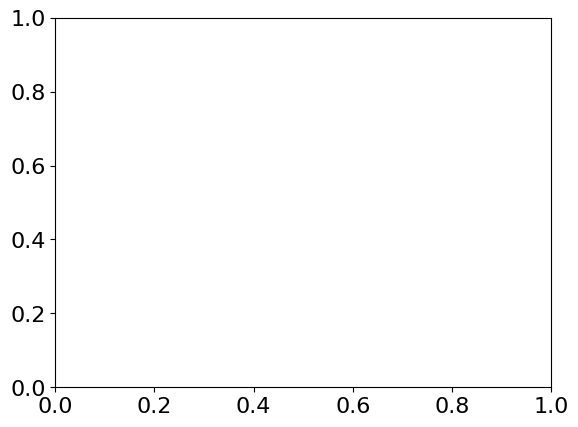

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :167.062656641604

[0. 0. 1.]


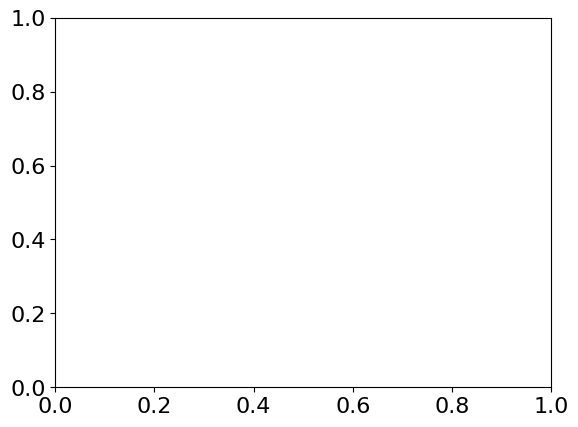

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :166.61654135338347

[0. 0. 1.]


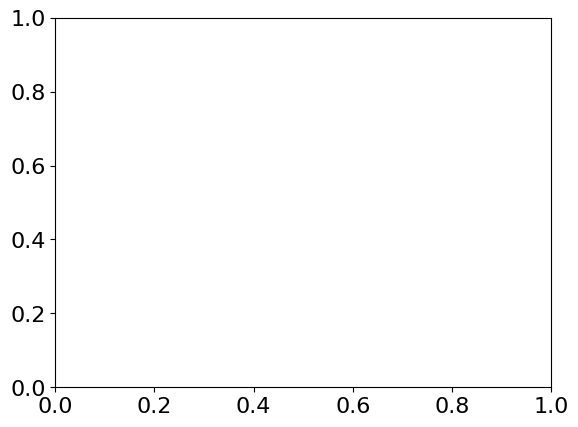

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :166.17042606516293

[0. 0. 1.]


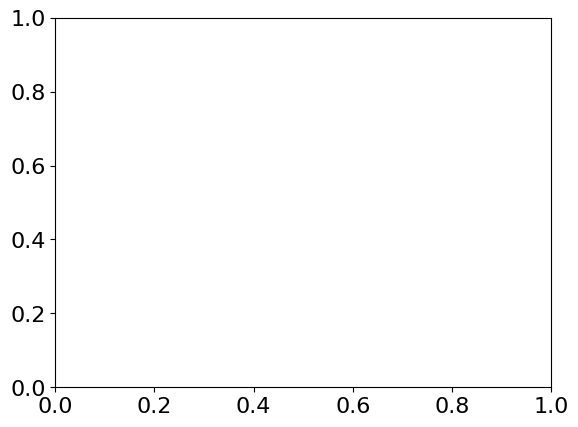

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :165.72431077694236

[0. 0. 1.]


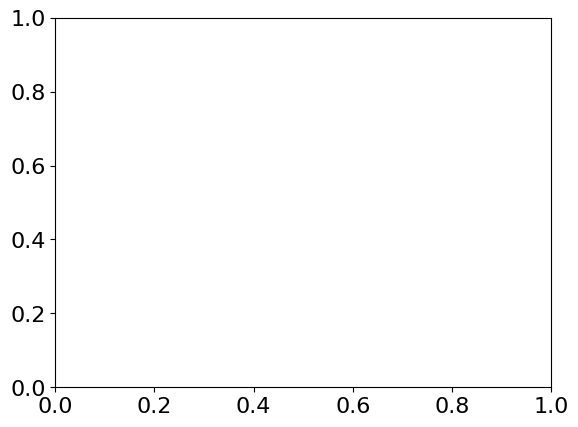

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :165.2781954887218

[0. 0. 1.]


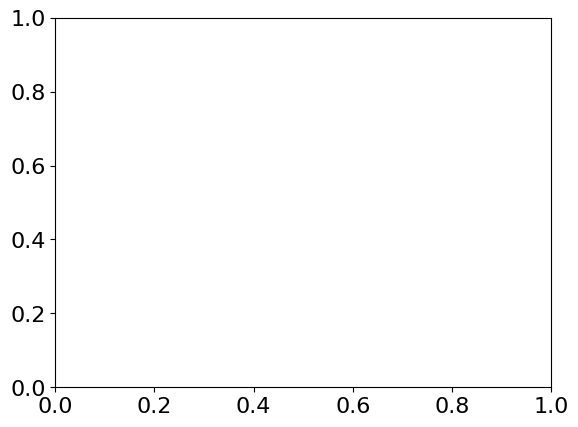

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :164.83208020050125

[0. 0. 1.]


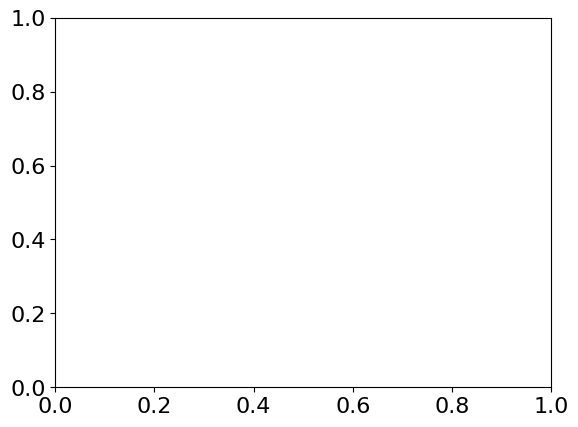

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :164.3859649122807

[0. 0. 1.]


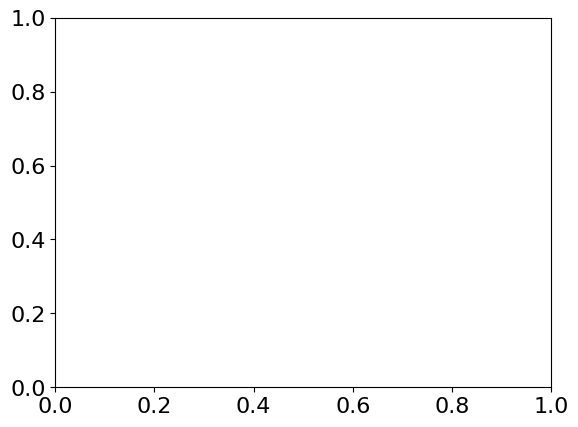

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :163.93984962406017

[0. 0. 1.]


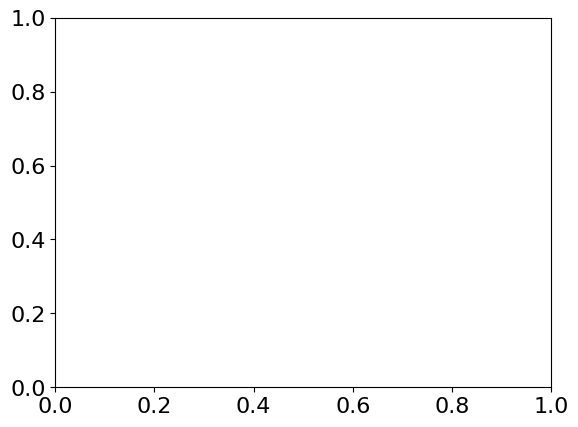

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :163.4937343358396

[0. 0. 1.]


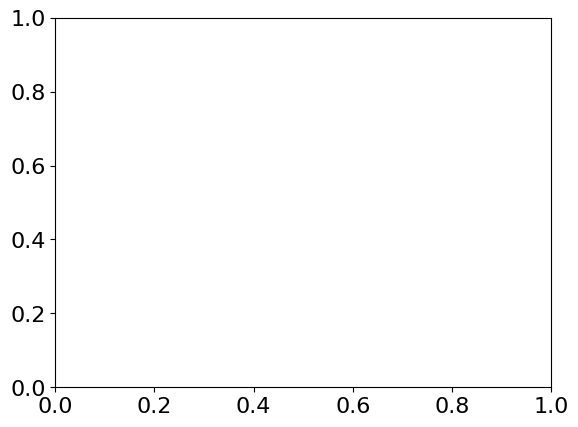

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :163.04761904761907

[0. 0. 1.]


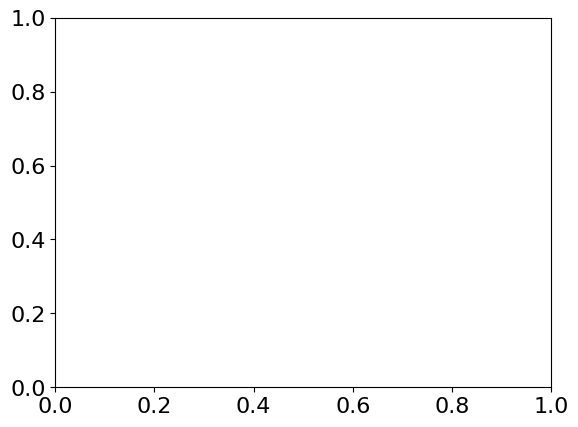

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :162.6015037593985

[0. 0. 1.]


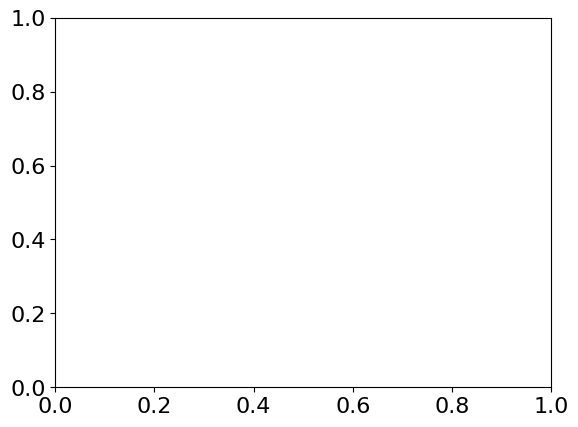

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :162.15538847117796

[0. 0. 1.]


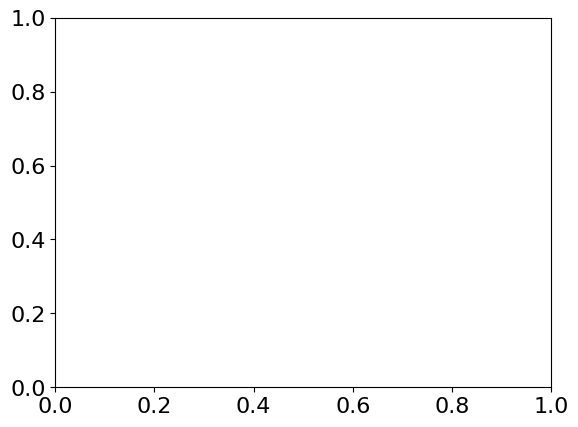

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :161.70927318295742

[0. 0. 1.]


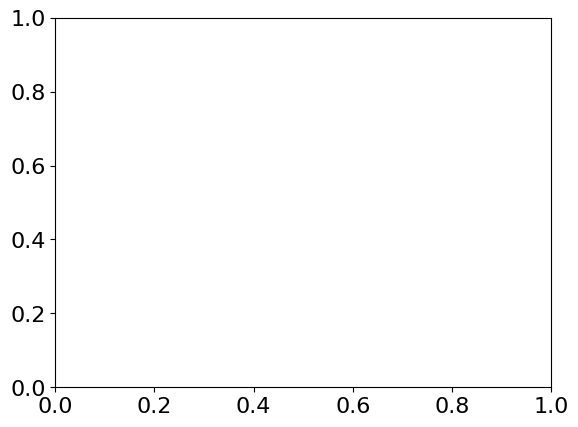

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :161.26315789473688

[0. 0. 1.]


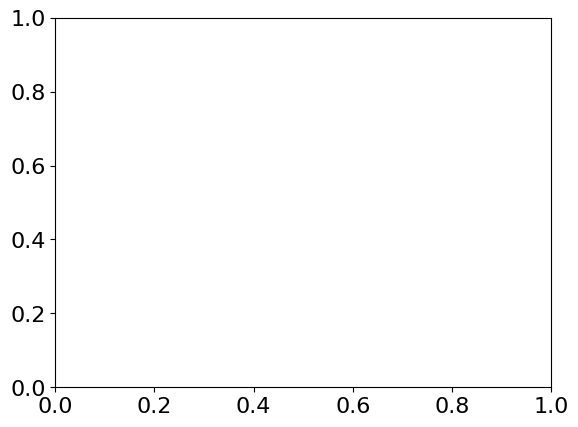

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :160.81704260651628

[0. 0. 1.]


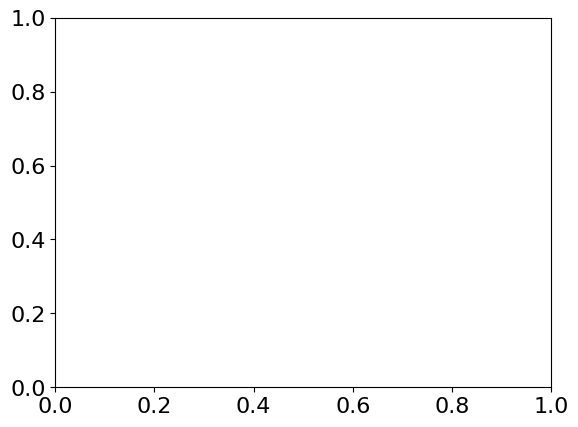

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :160.37092731829574

[0. 0. 1.]


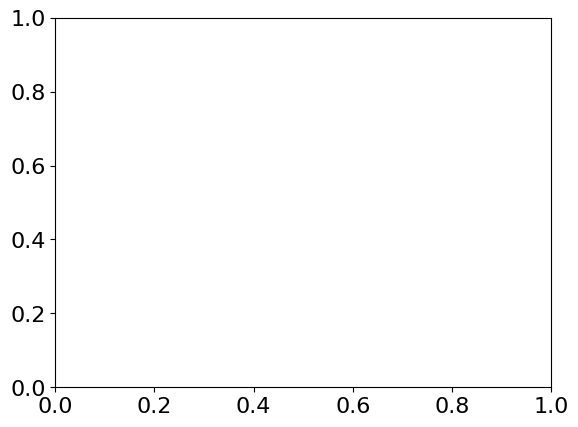

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :159.9248120300752

[0. 0. 1.]


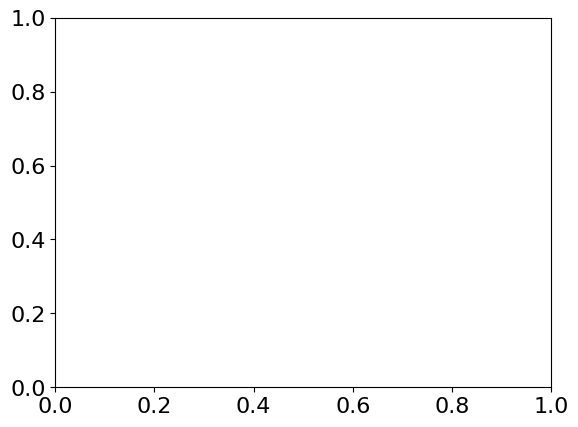

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :159.47869674185463

[0. 0. 1.]


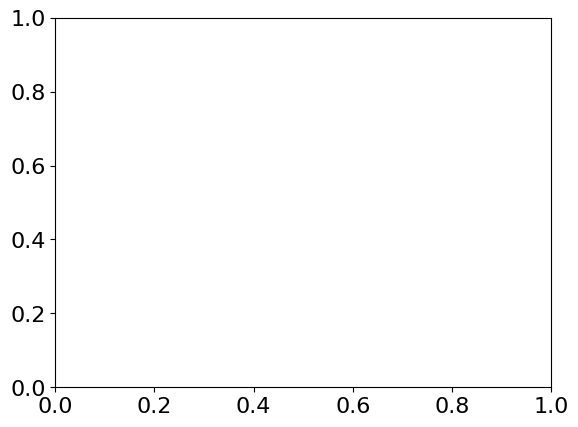

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :159.0325814536341

[0. 0. 1.]


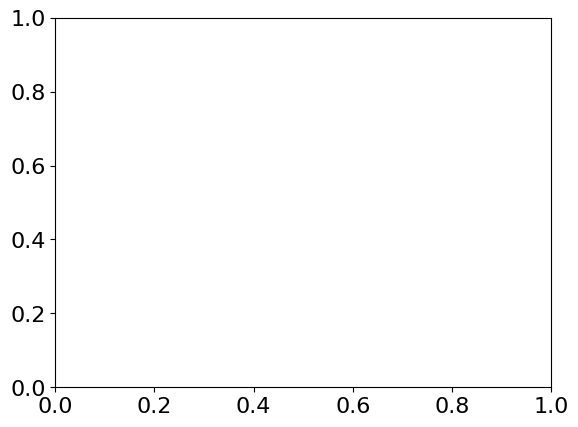

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :158.58646616541353

[0. 0. 1.]


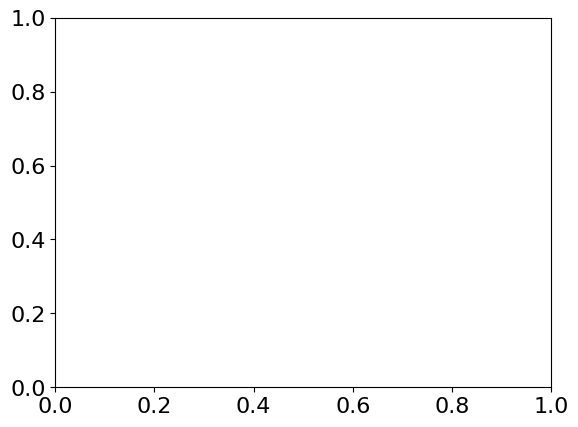

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :158.140350877193

[0. 0. 1.]


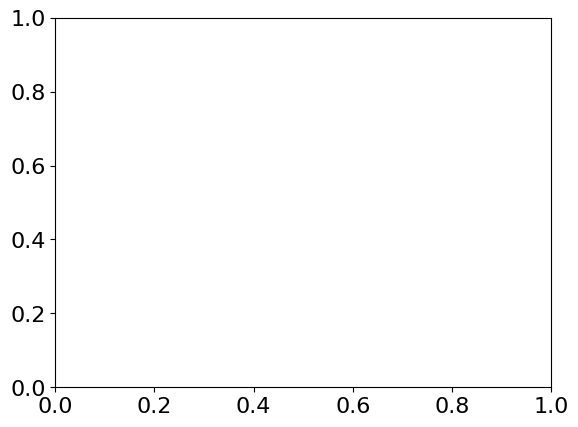

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :157.69423558897242

[0. 0. 1.]


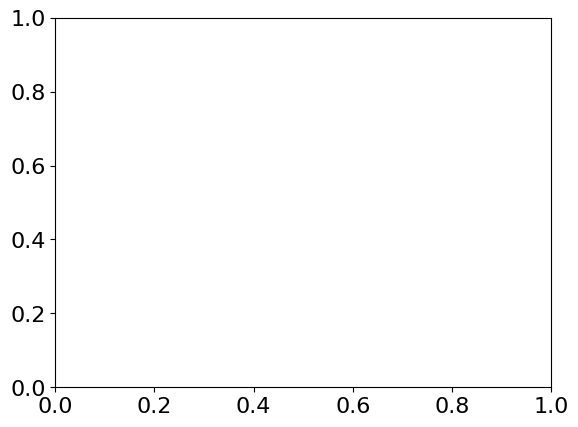

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :157.24812030075188

[0. 0. 1.]


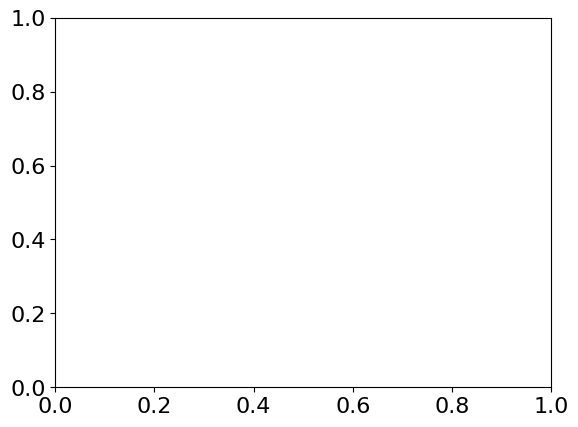

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :156.80200501253134

[0. 0. 1.]


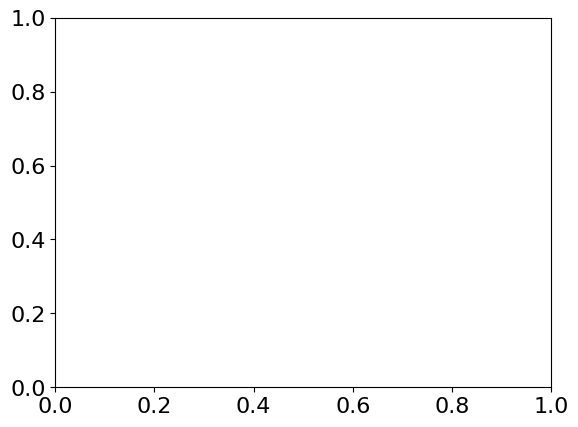

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :156.3558897243108

[0. 0. 1.]


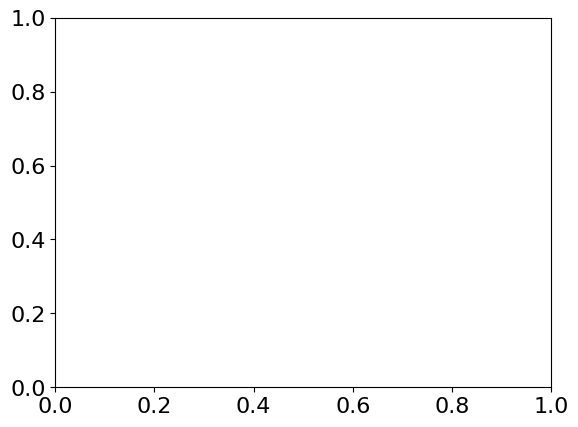

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :155.90977443609023

[0. 0. 1.]


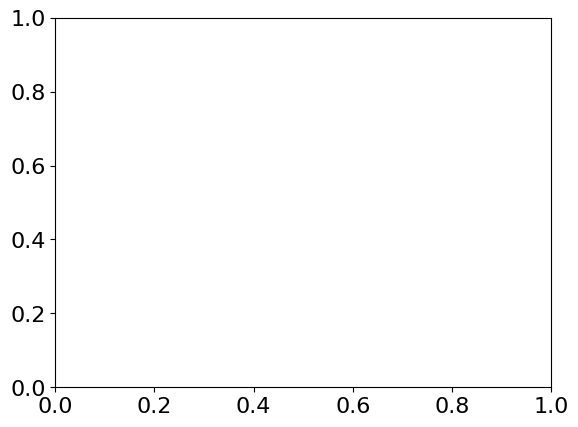

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :155.4636591478697

[0. 0. 1.]


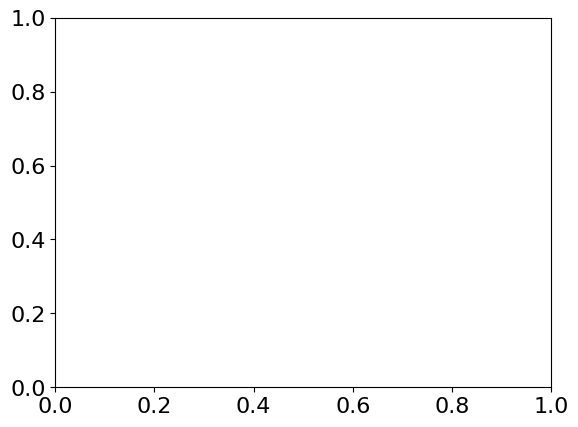

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :155.01754385964912

[0. 0. 1.]


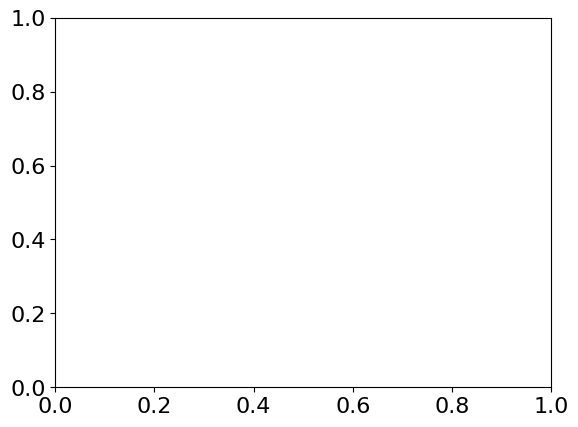

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :154.57142857142858

[0. 0. 1.]


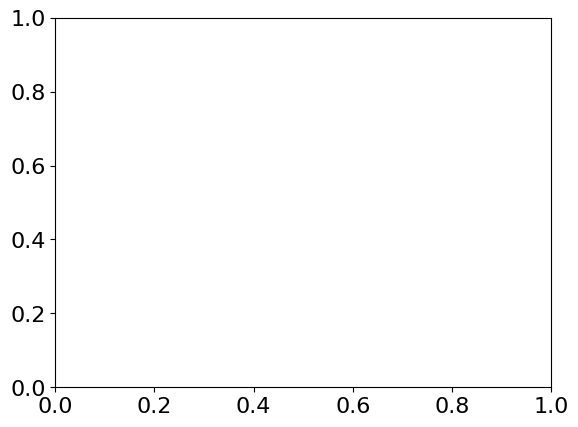

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :154.12531328320804

[0. 0. 1.]


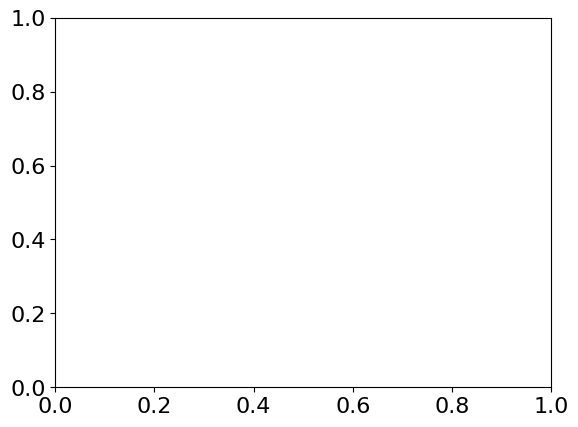

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :153.67919799498745

[0. 0. 1.]


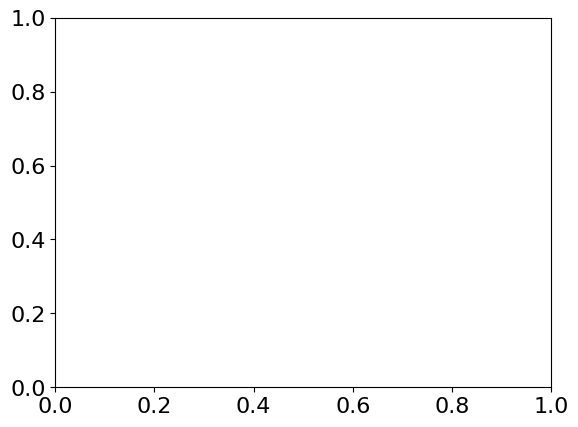

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :153.2330827067669

[0. 0. 1.]


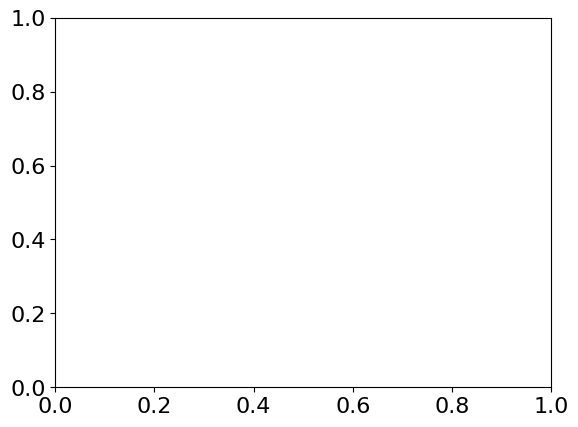

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :152.78696741854637

[0. 0. 1.]


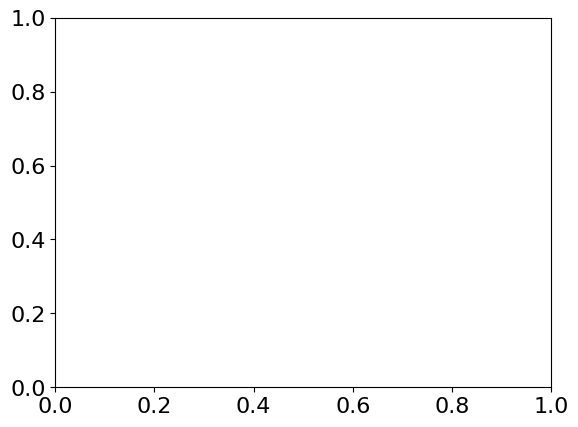

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :152.34085213032583

[0. 0. 1.]


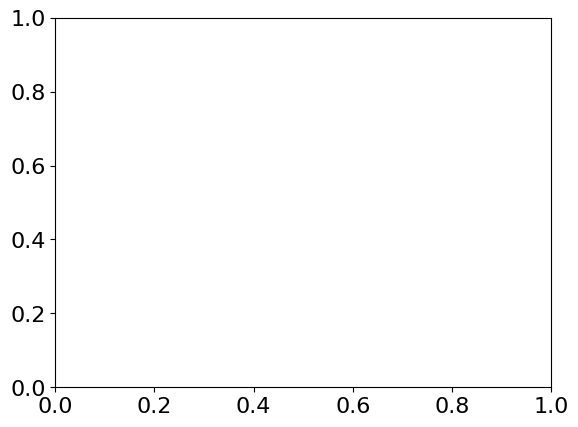

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :151.8947368421053

[0. 0. 1.]


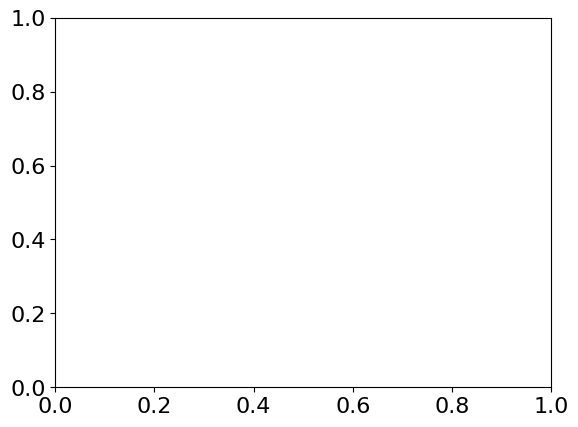

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :151.44862155388472

[0. 0. 1.]


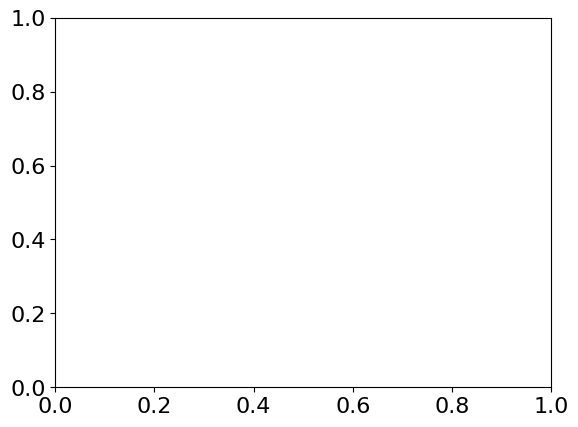

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :151.00250626566415

[0. 0. 1.]


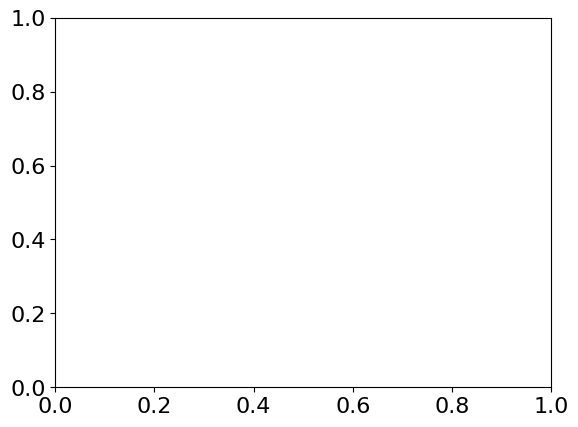

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :150.5563909774436

[0. 0. 1.]


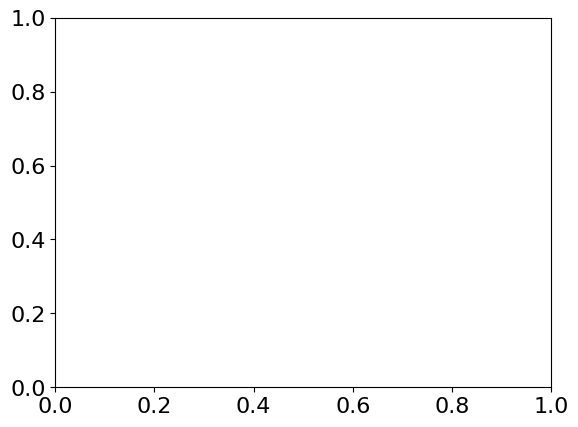

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :150.11027568922307

[0. 0. 1.]


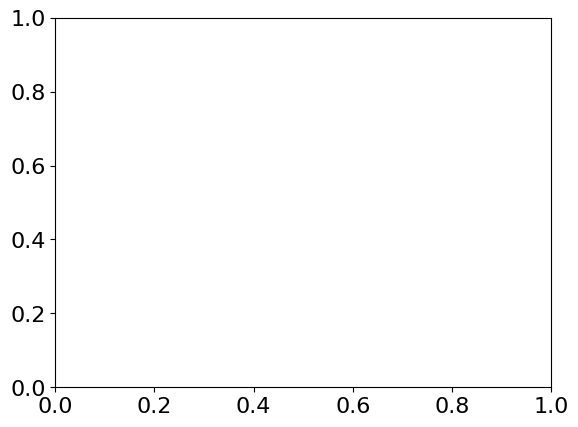

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :149.6641604010025

[0. 0. 1.]


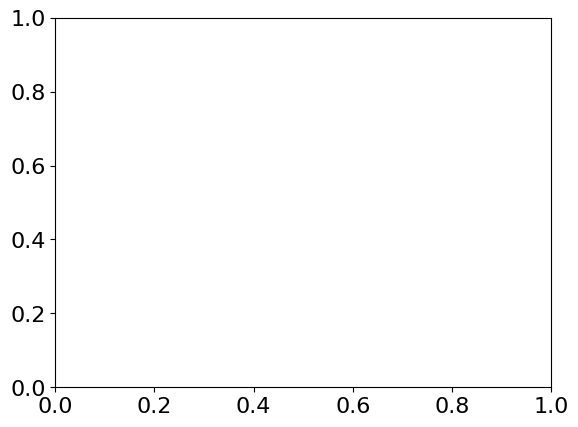

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :149.21804511278197

[0. 0. 1.]


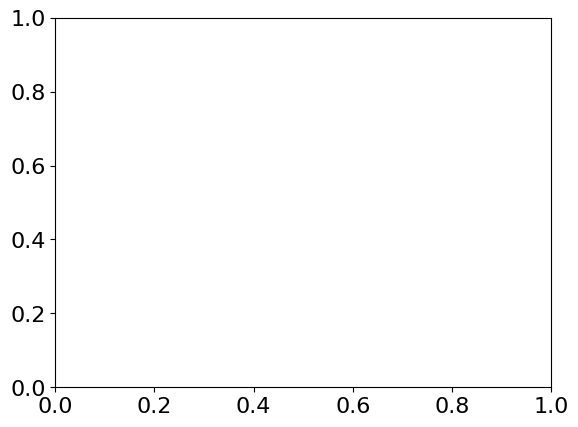

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :148.7719298245614

[0. 0. 1.]


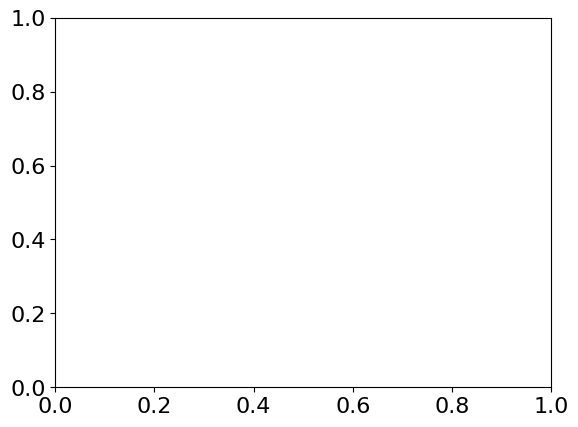

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :148.32581453634086

[0. 0. 1.]


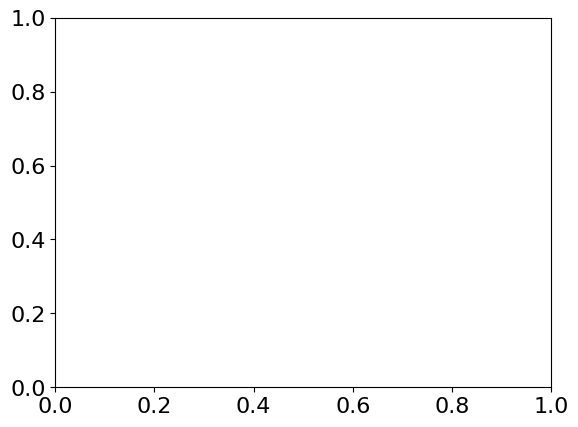

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :147.87969924812032

[0. 0. 1.]


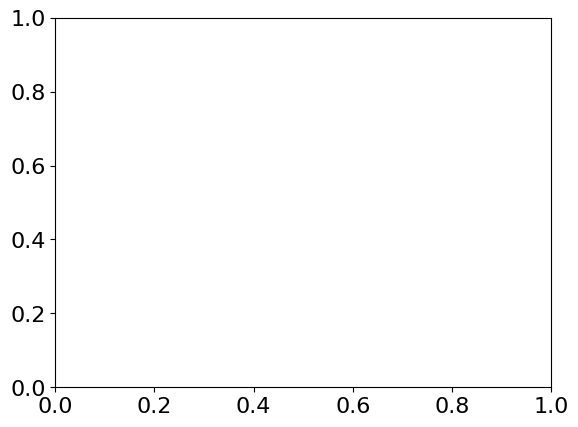

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :147.43358395989978

[0. 0. 1.]


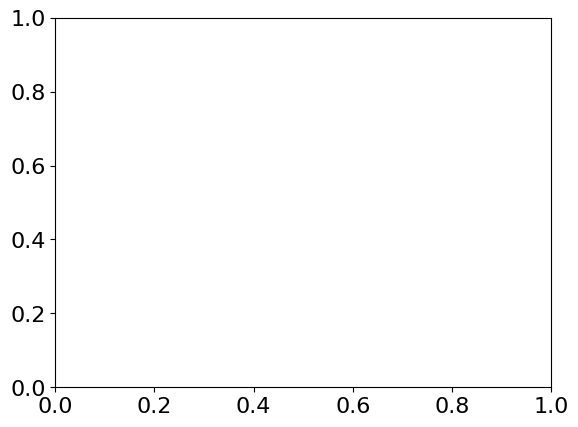

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :146.9874686716792

[0. 0. 1.]


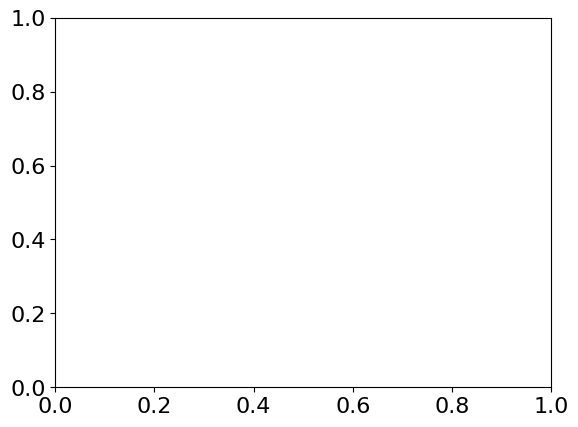

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :146.54135338345864

[0. 0. 1.]


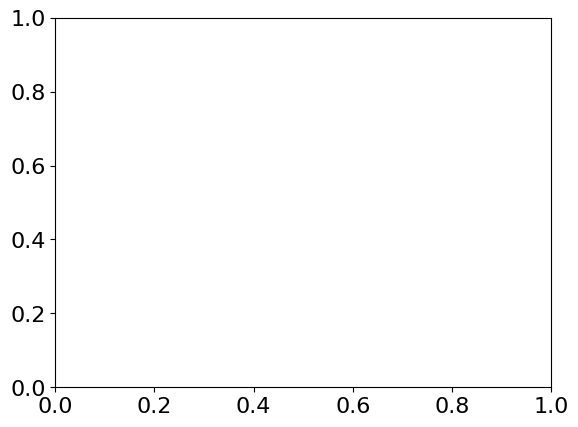

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :146.0952380952381

[0. 0. 1.]


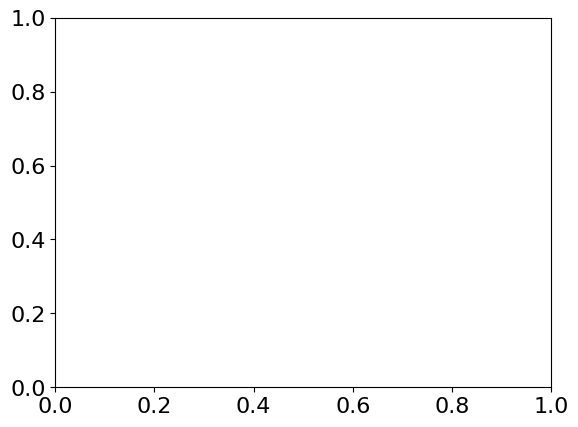

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :145.64912280701753

[0. 0. 1.]


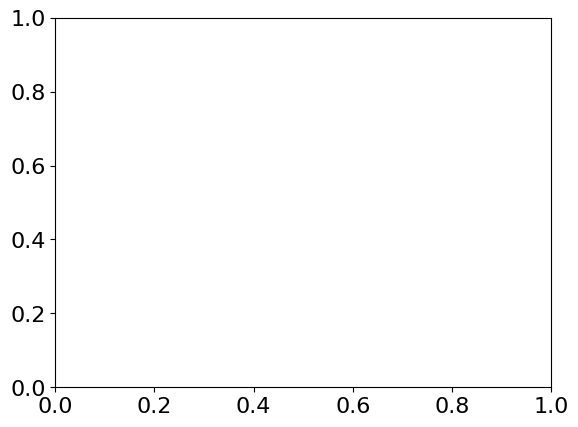

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :145.203007518797

[0. 0. 1.]


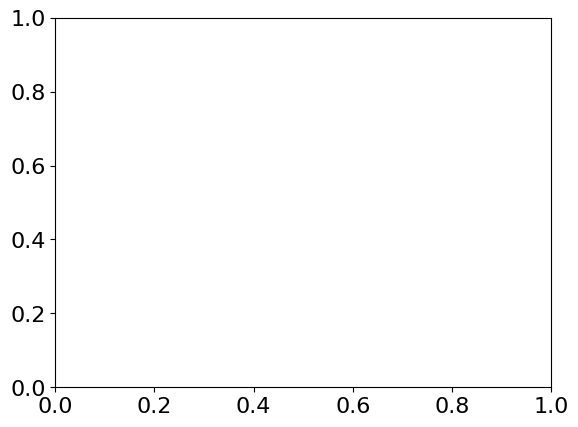

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :144.75689223057645

[0. 0. 1.]


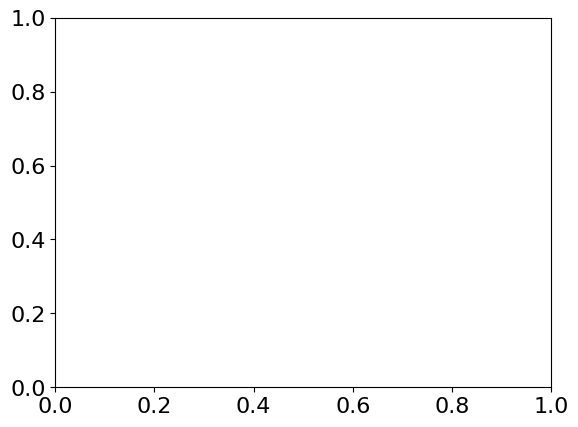

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :144.31077694235591

[0. 0. 1.]


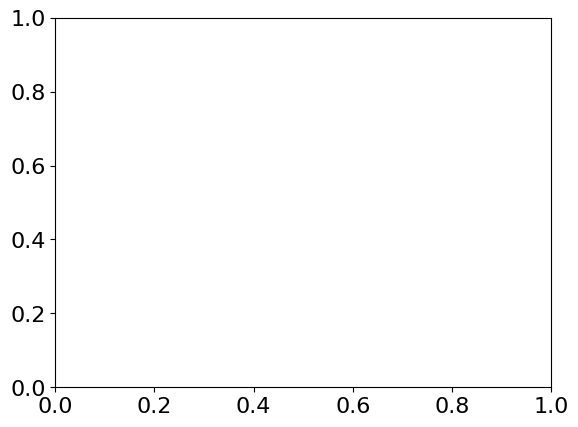

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :143.86466165413532

[0. 0. 1.]


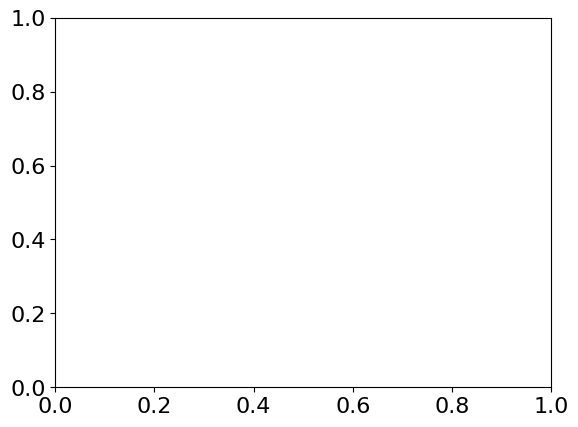

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :143.41854636591478

[0. 0. 1.]


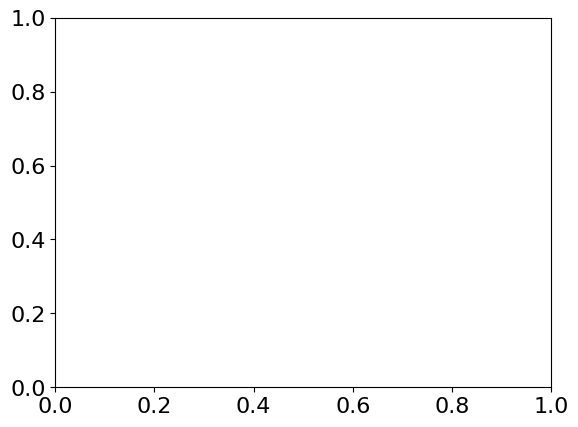

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :142.97243107769424

[0. 0. 1.]


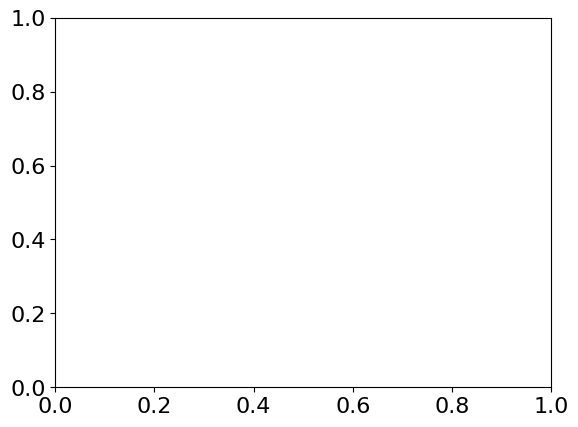

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :142.5263157894737

[0. 0. 1.]


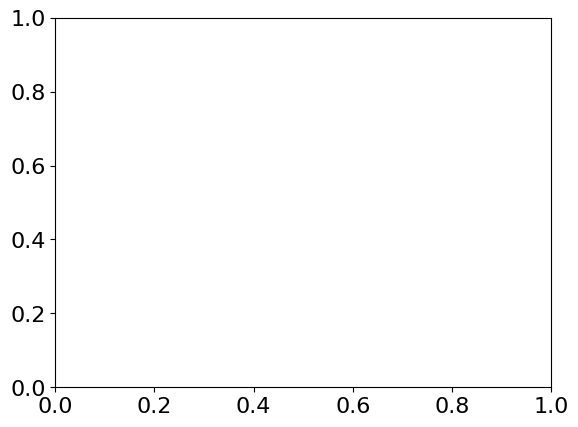

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :142.08020050125313

[0. 0. 1.]


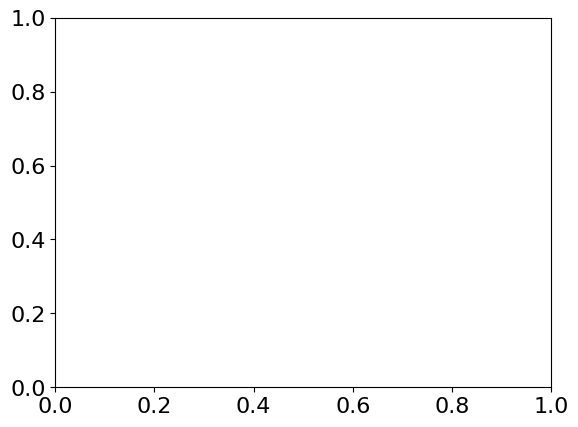

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :141.6340852130326

[0. 0. 1.]


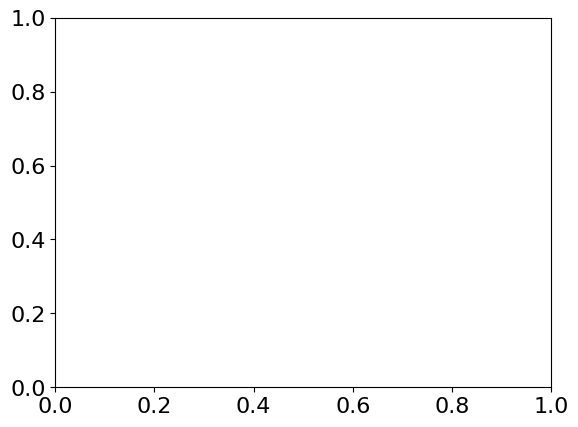

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :141.18796992481202

[0. 0. 1.]


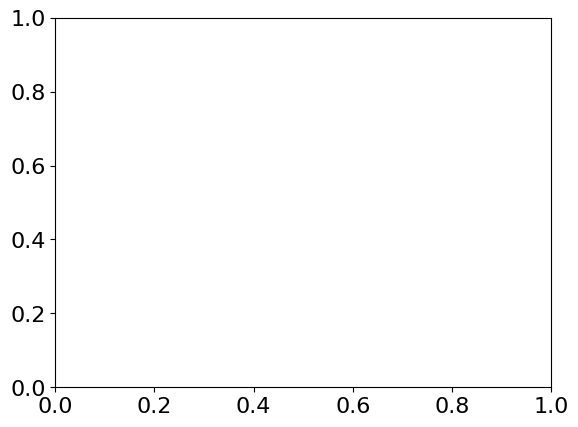

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :140.74185463659148

[0. 0. 1.]


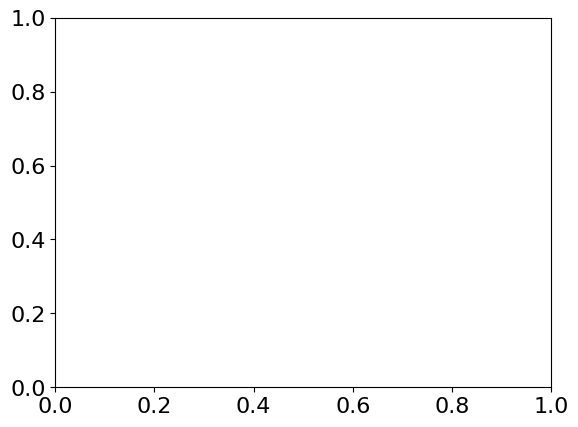

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :140.29573934837092

[0. 0. 1.]


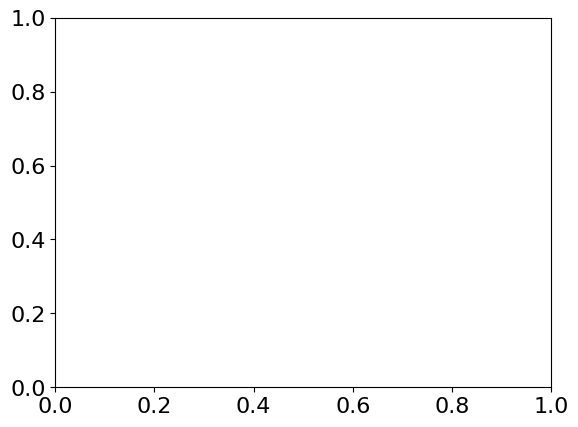

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :139.8496240601504

[0. 0. 1.]


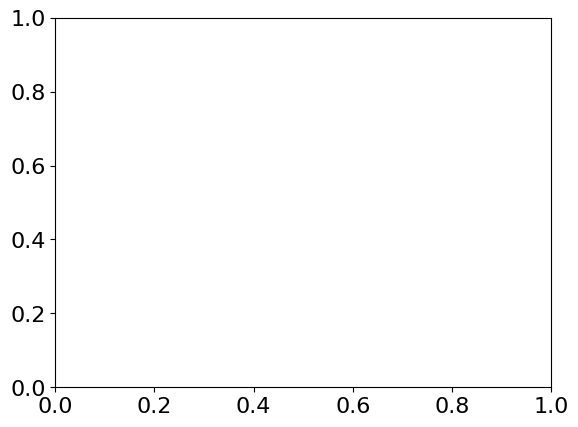

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :139.40350877192984

[0. 0. 1.]


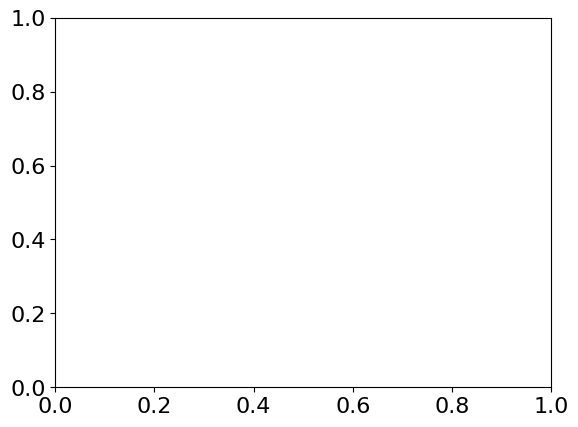

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :138.95739348370927

[0. 0. 1.]


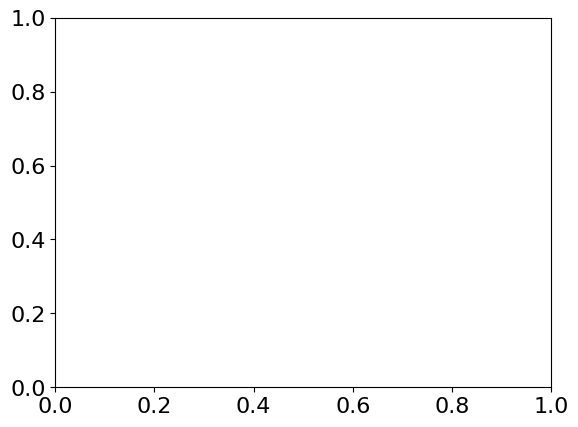

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :138.51127819548873

[0. 0. 1.]


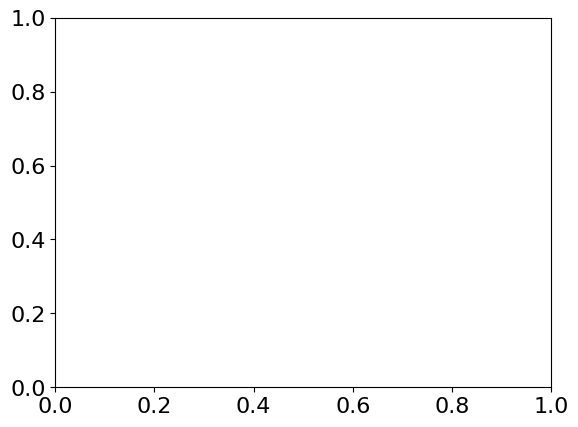

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :138.0651629072682

[0. 0. 1.]


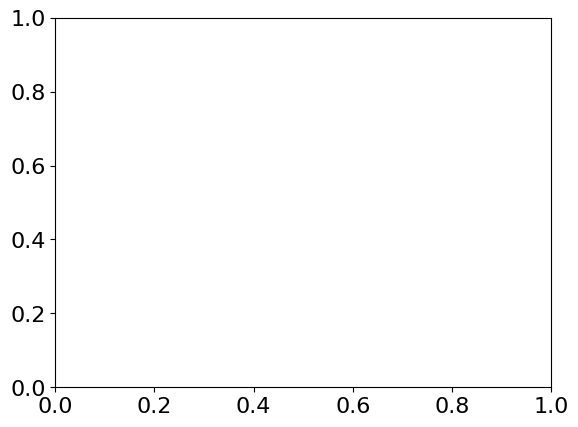

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :137.61904761904762

[0. 0. 1.]


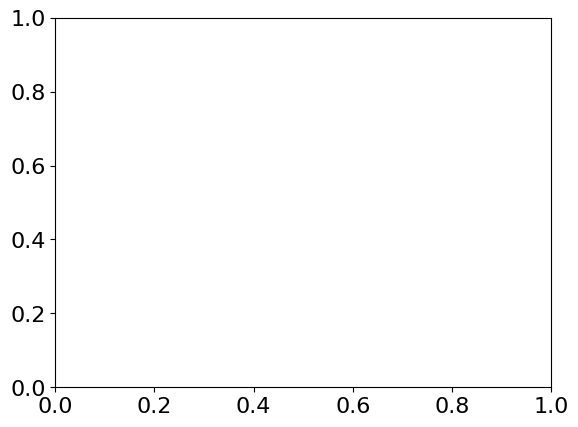

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :137.17293233082708

[0. 0. 1.]


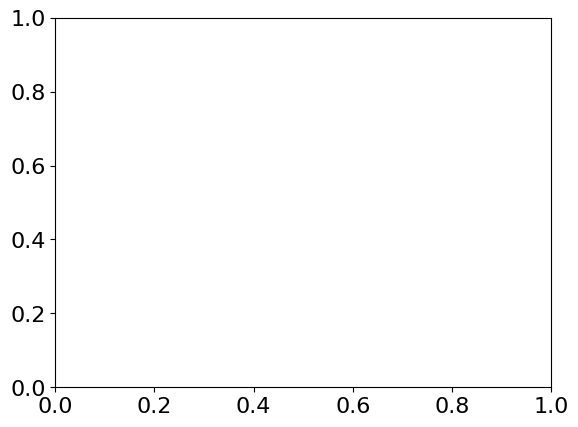

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :136.7268170426065

[0. 0. 1.]


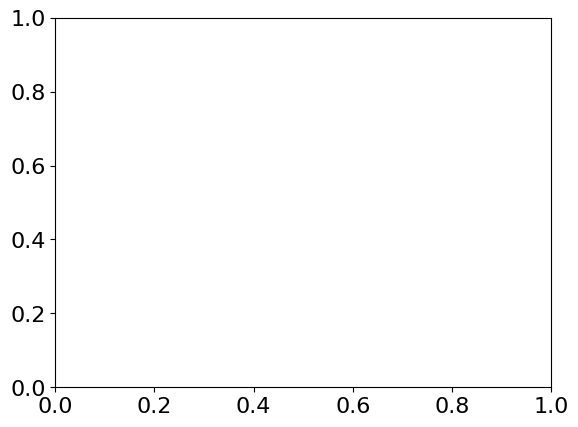

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :136.28070175438597

[0. 0. 1.]


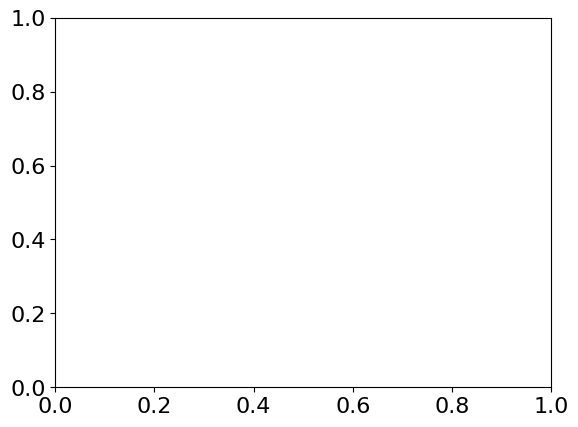

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :135.8345864661654

[0. 0. 1.]


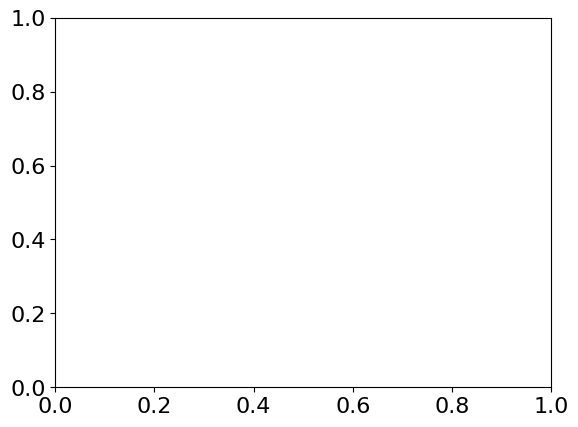

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :135.38847117794487

[0. 0. 1.]


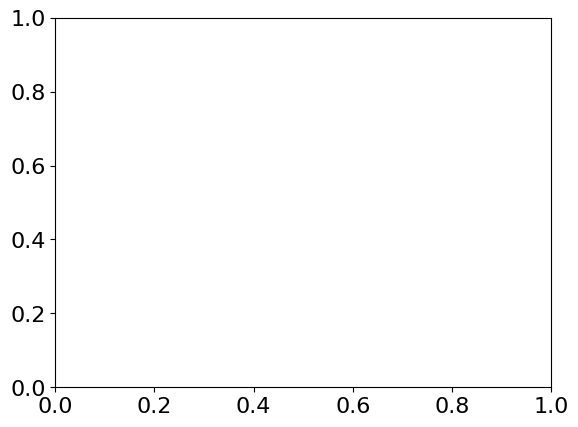

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :134.94235588972433

[0. 0. 1.]


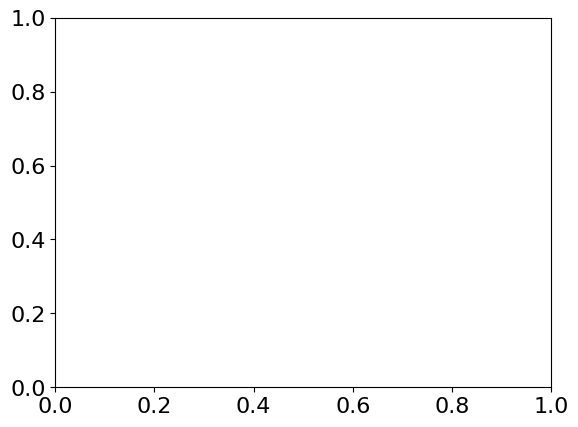

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :134.49624060150379

[0. 0. 1.]


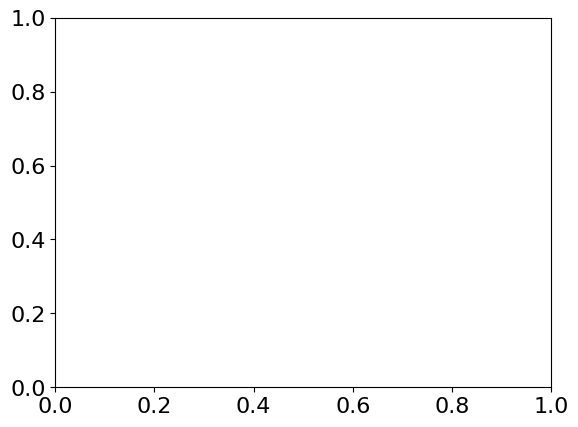

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :134.05012531328322

[0. 0. 1.]


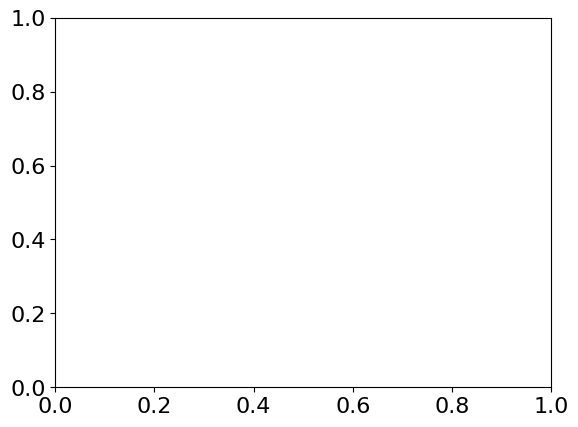

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :133.60401002506268

[0. 0. 1.]


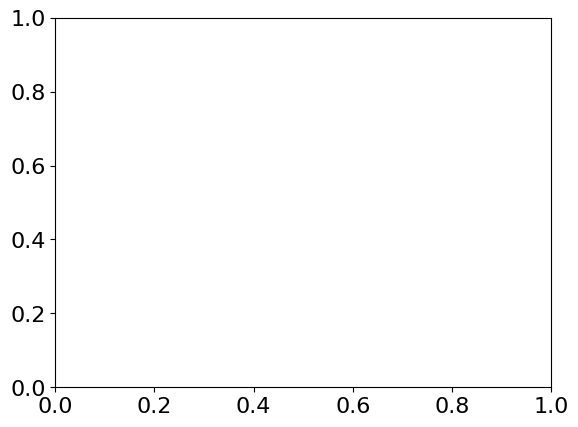

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :133.1578947368421

[0. 0. 1.]


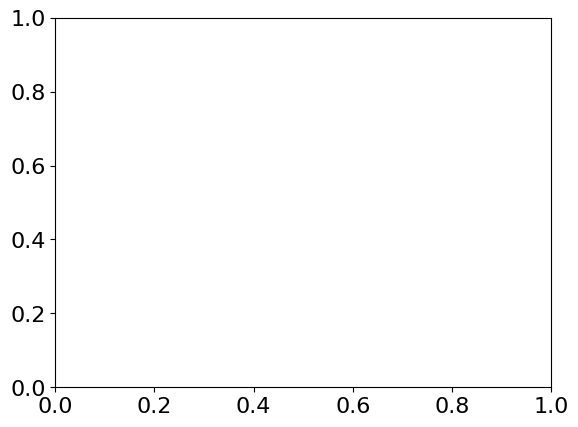

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :132.71177944862157

[0. 0. 1.]


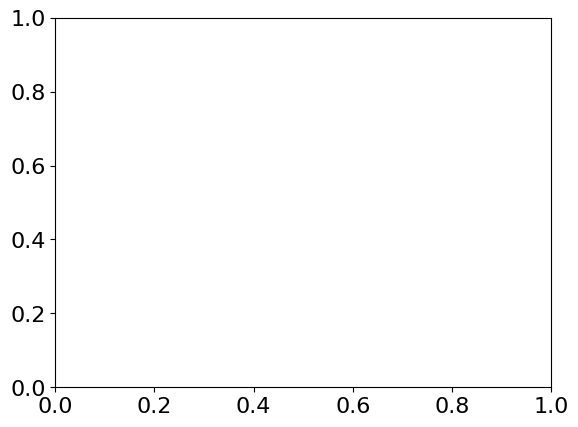

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :132.265664160401

[0. 0. 1.]


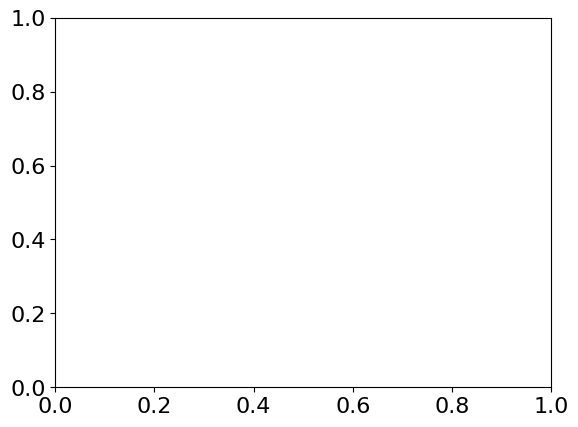

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :131.81954887218043

[0. 0. 1.]


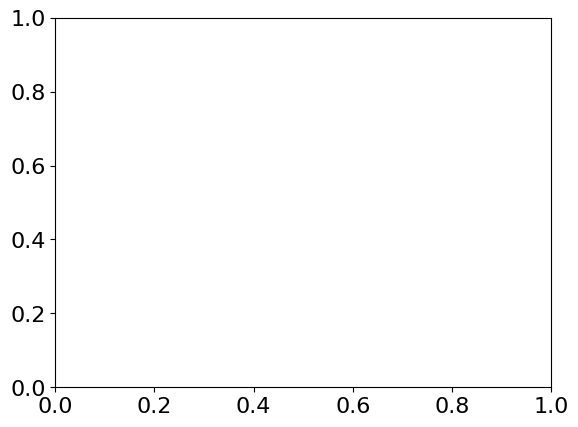

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :131.3734335839599

[0. 0. 1.]


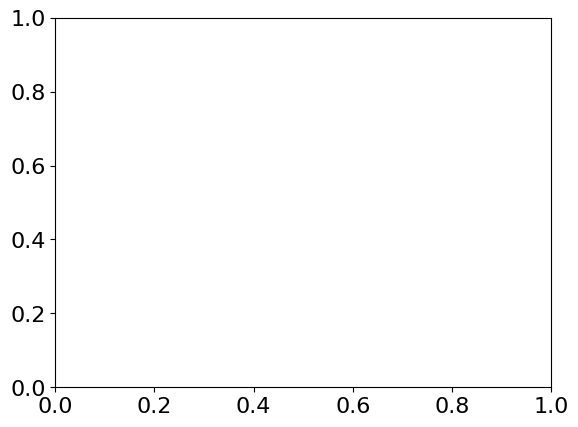

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :130.92731829573935

[0. 0. 1.]


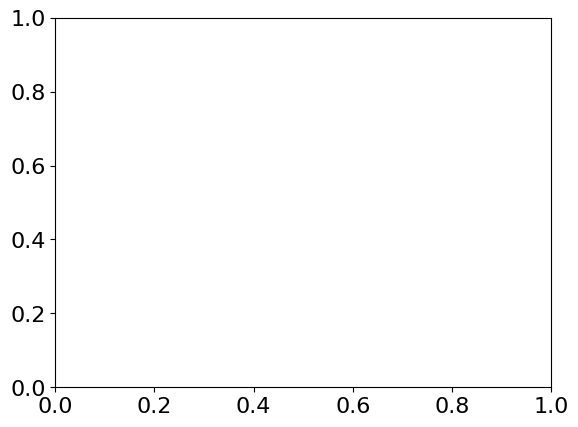

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :130.48120300751881

[0. 0. 1.]


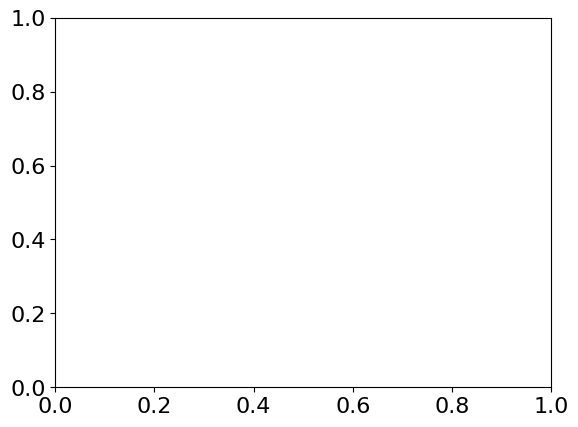

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :130.03508771929828

[0. 0. 1.]


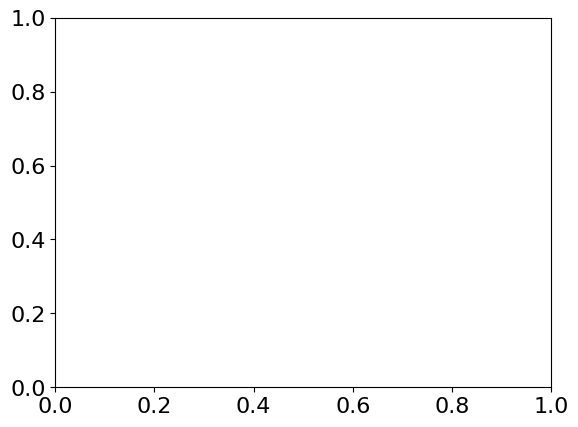

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :129.5889724310777

[0. 0. 1.]


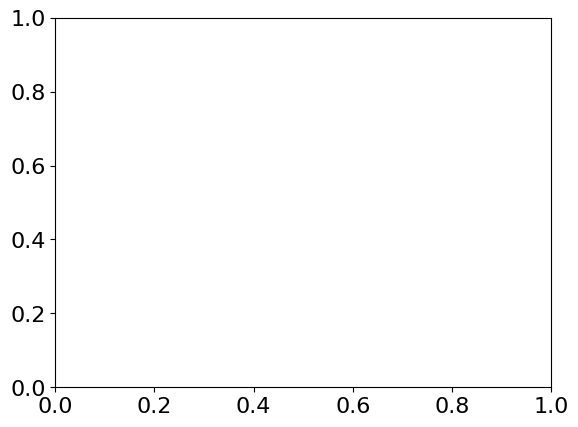

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :129.14285714285714

[0. 0. 1.]


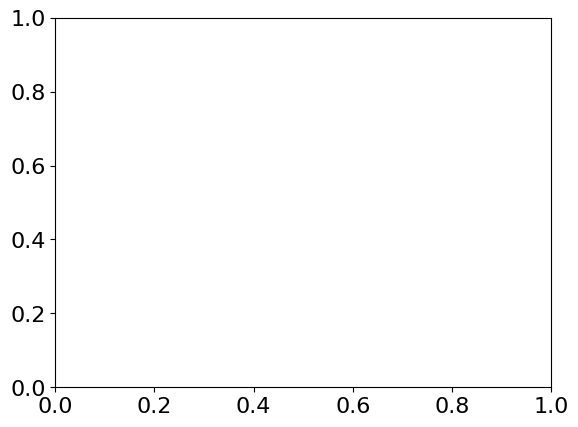

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :128.6967418546366

[0. 0. 1.]


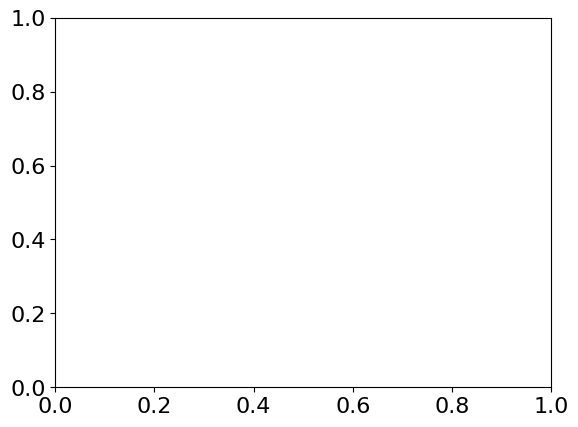

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :128.25062656641603

[0. 0. 1.]


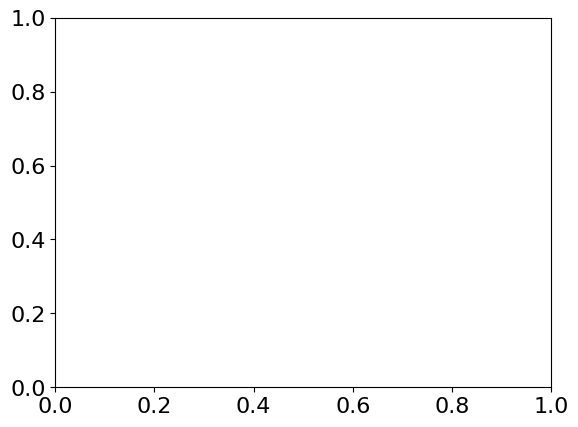

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :127.8045112781955

[0. 0. 1.]


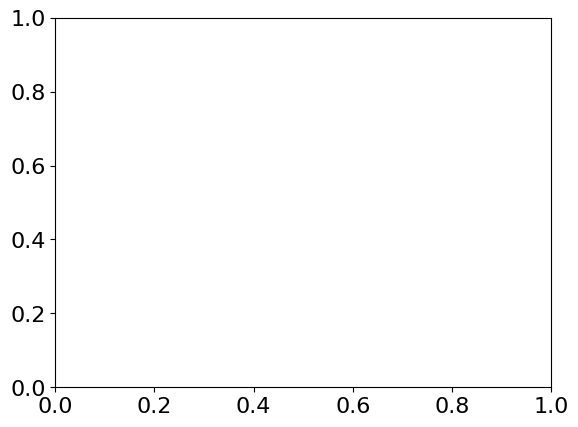

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :127.35839598997497

[0. 0. 1.]


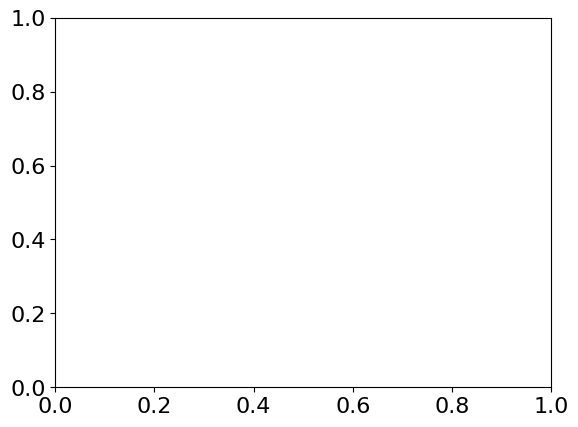

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :126.91228070175438

[0. 0. 1.]


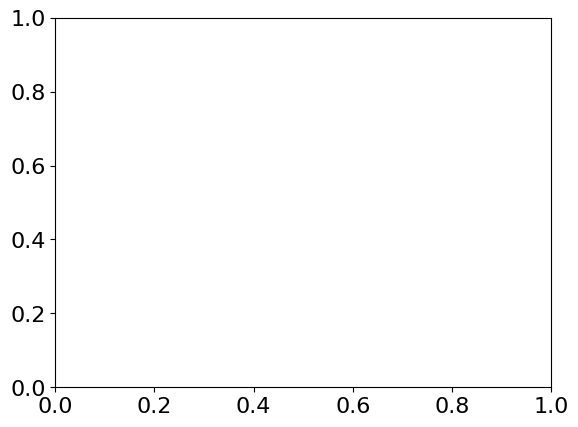

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :126.46616541353383

[0. 0. 1.]


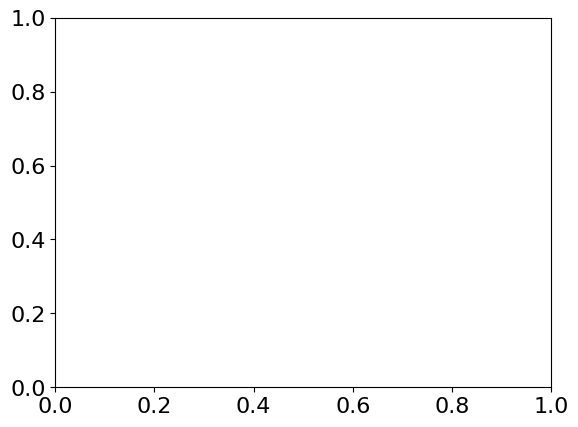

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :126.02005012531329

[0. 0. 1.]


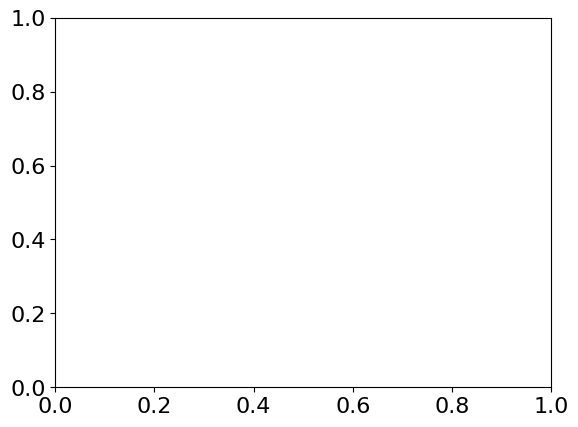

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :125.57393483709274

[0. 0. 1.]


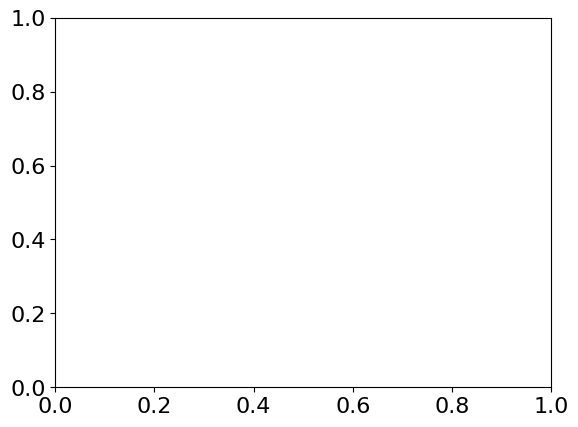

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :125.1278195488722

[0. 0. 1.]


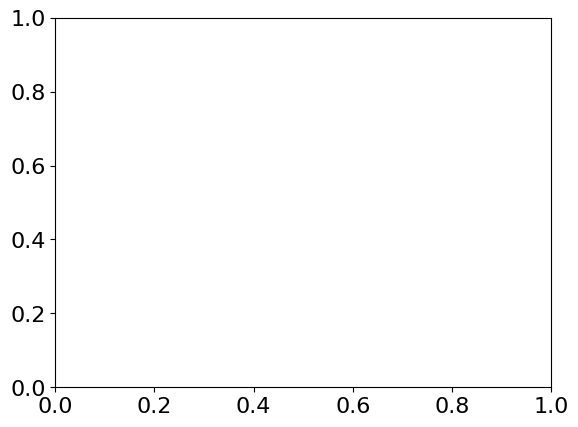

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :124.68170426065161

[0. 0. 1.]


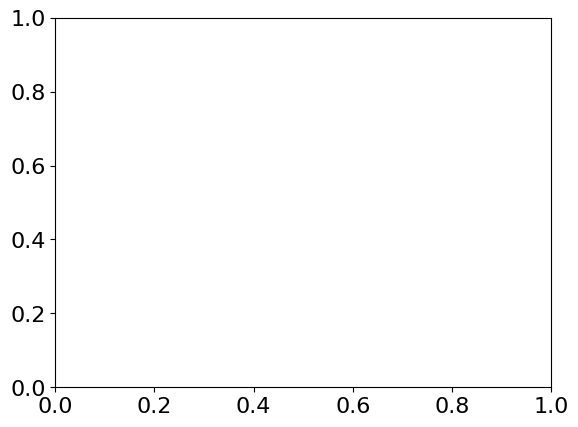

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :124.23558897243107

[0. 0. 1.]


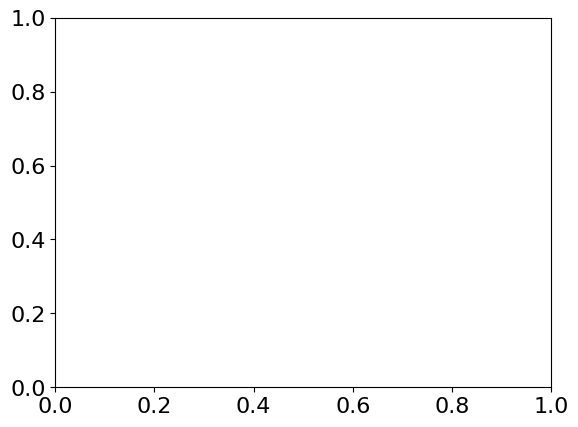

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :123.78947368421052

[0. 0. 1.]


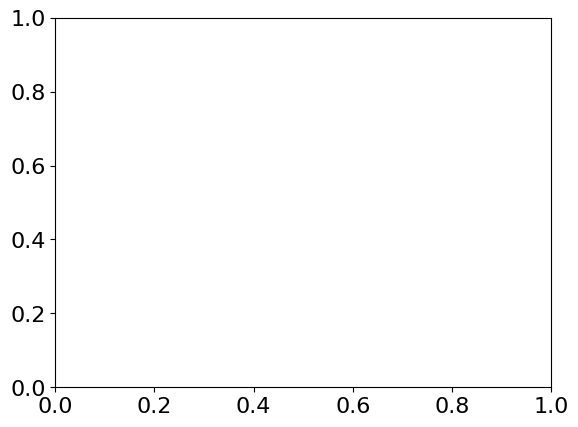

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :123.34335839598998

[0. 0. 1.]


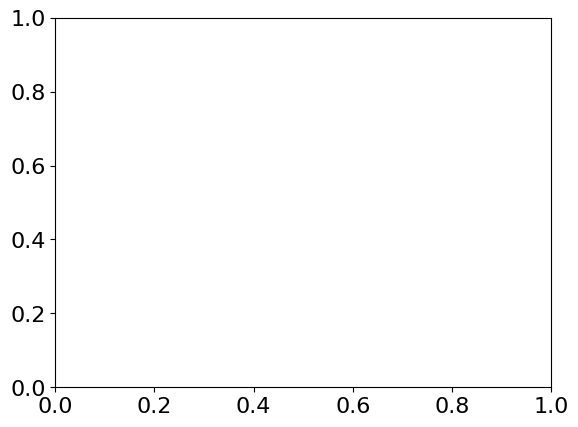

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :122.89724310776943

[0. 0. 1.]


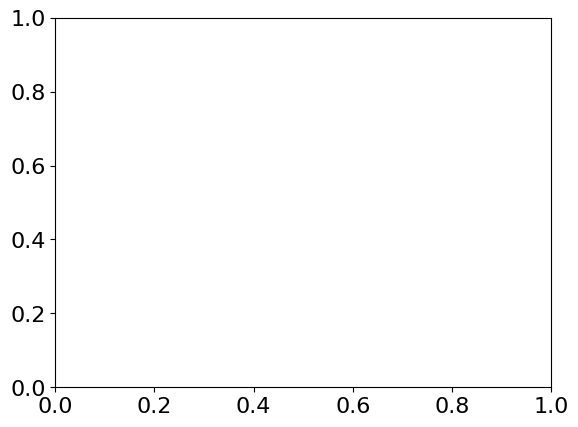

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :122.45112781954889

[0. 0. 1.]


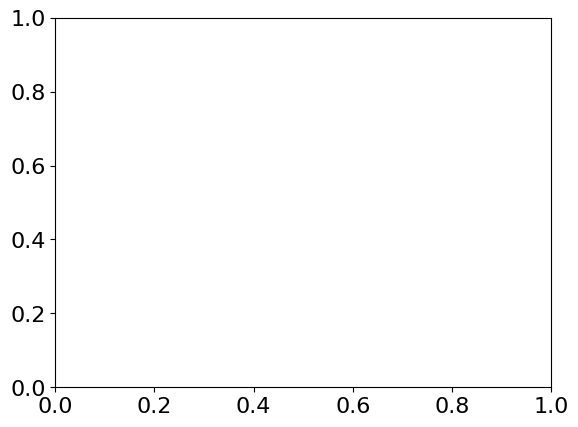

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :122.00501253132832

[0. 0. 1.]


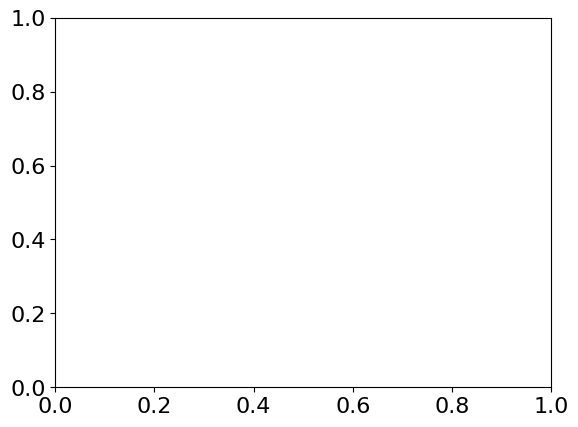

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :121.55889724310778

[0. 0. 1.]


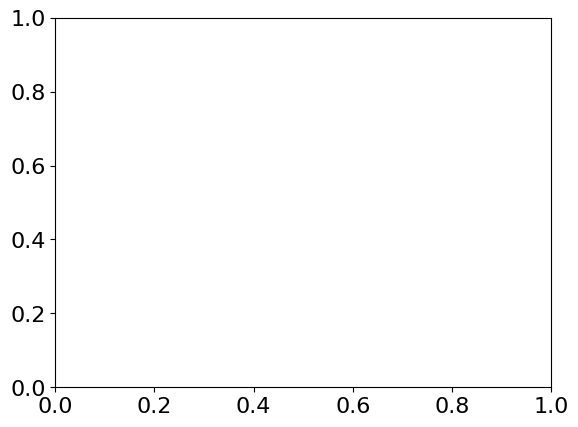

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :121.11278195488723

[0. 0. 1.]


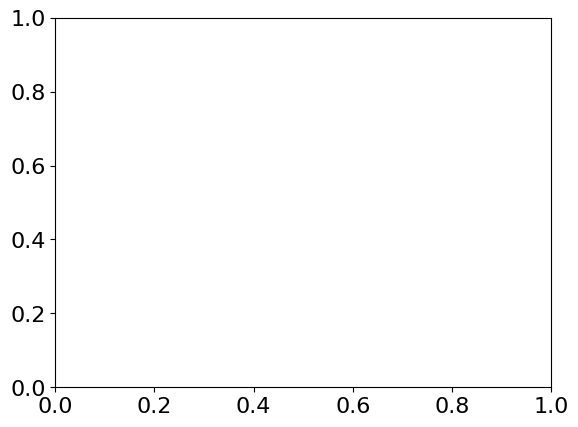

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :120.66666666666669

[0. 0. 1.]


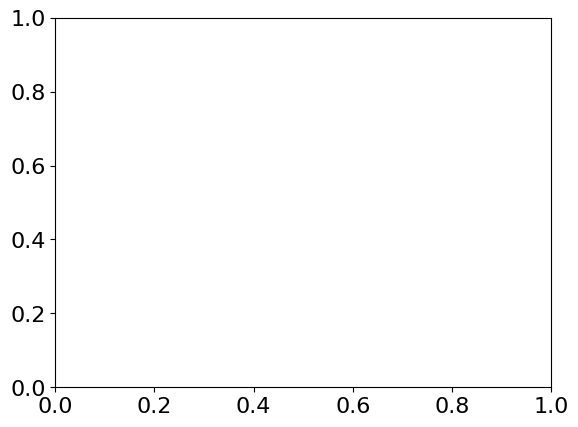

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :120.22055137844612

[0. 0. 1.]


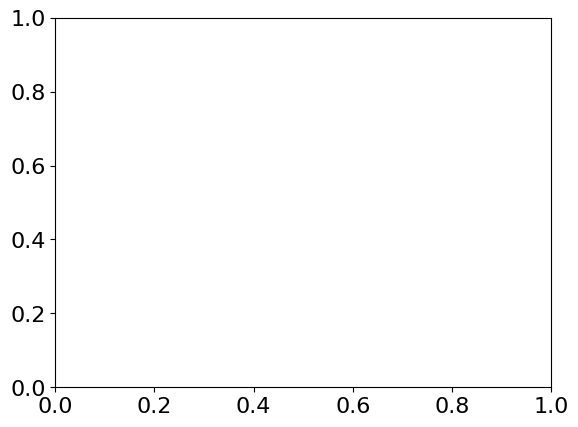

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :119.77443609022556

[0. 0. 1.]


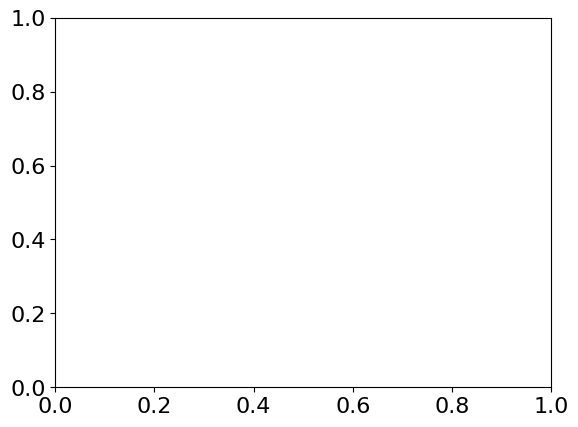

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :119.32832080200501

[0. 0. 1.]


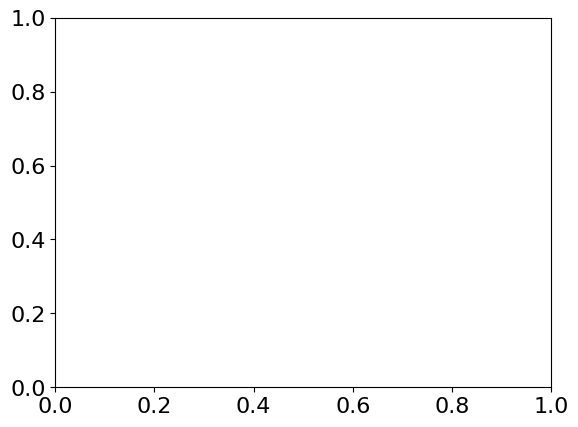

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :118.88220551378447

[0. 0. 1.]


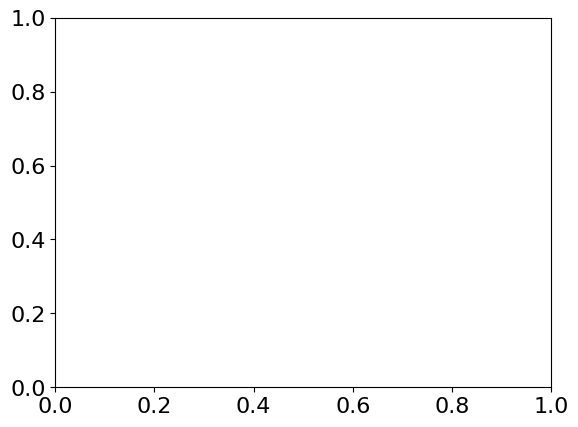

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :118.43609022556392

[0. 0. 1.]


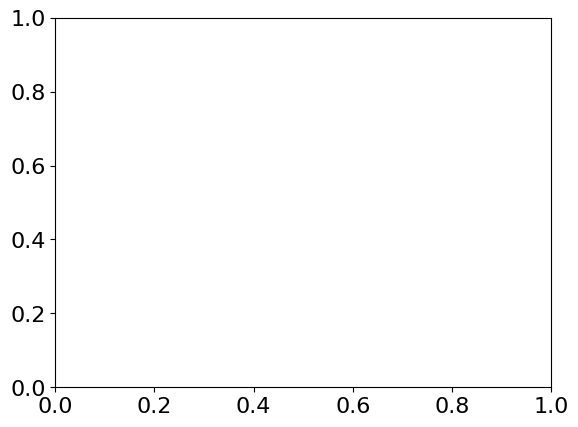

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :117.98997493734338

[0. 0. 1.]


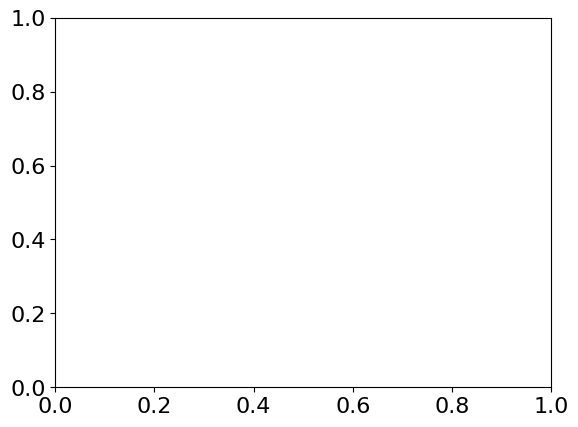

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :117.54385964912282

[0. 0. 1.]


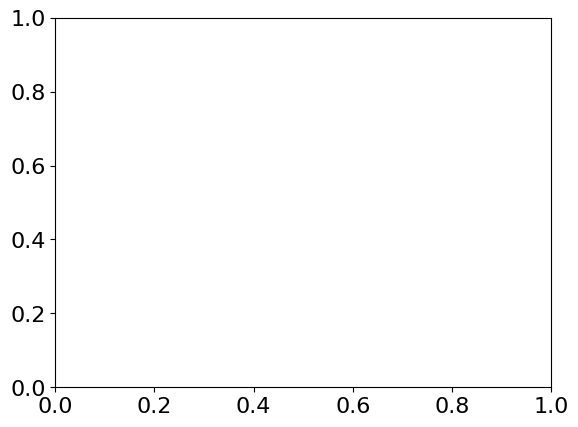

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :117.09774436090225

[0. 0. 1.]


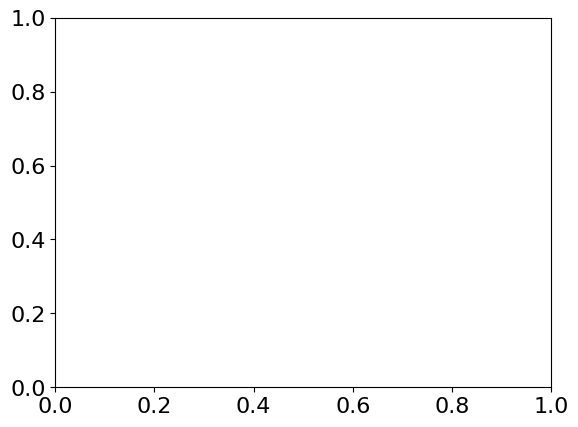

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :116.6516290726817

[0. 0. 1.]


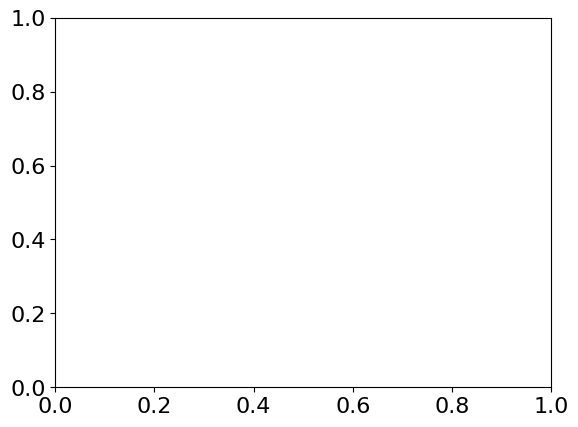

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :116.20551378446116

[0. 0. 1.]


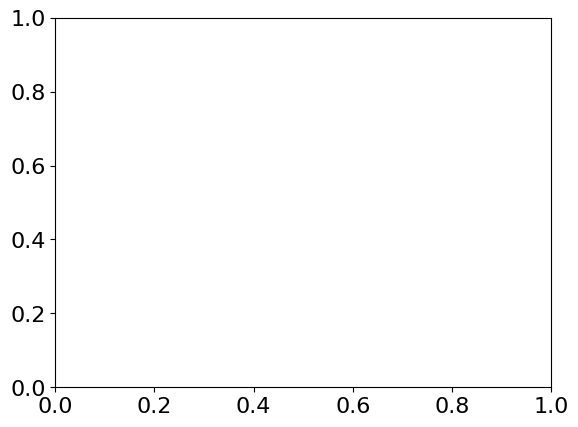

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :115.7593984962406

[0. 0. 1.]


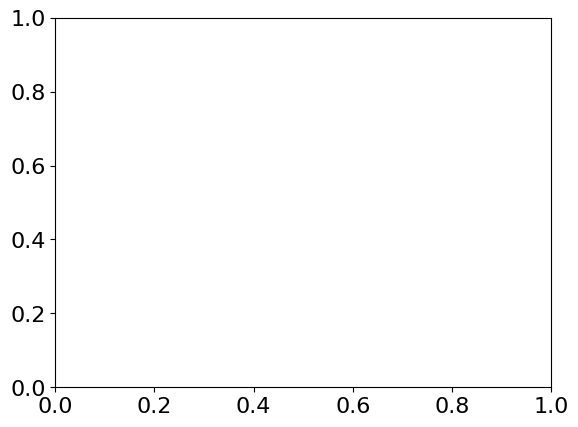

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :115.31328320802004

[0. 0. 1.]


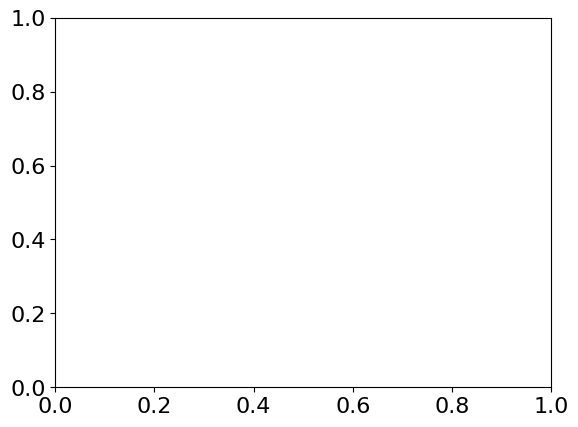

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :114.8671679197995

[0. 0. 1.]


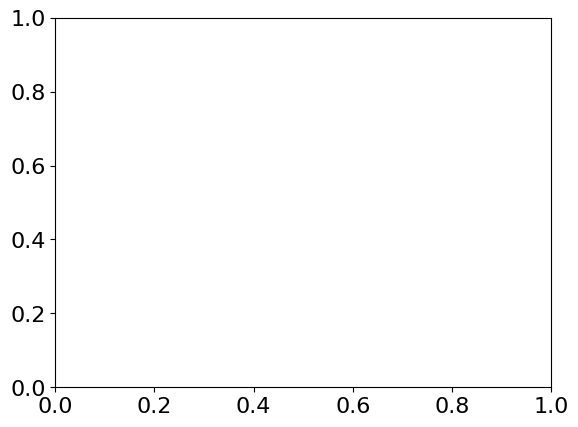

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :114.42105263157896

[0. 0. 1.]


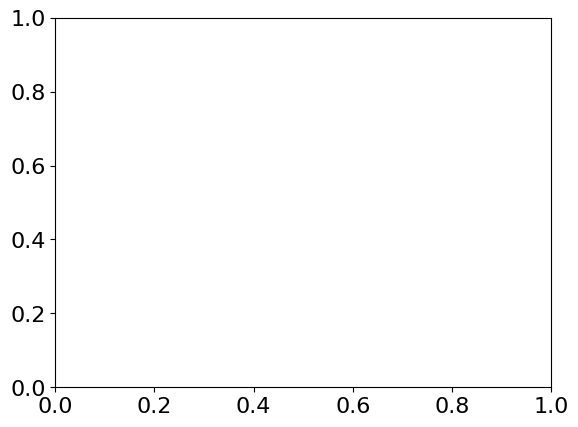

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :113.9749373433584

[0. 0. 1.]


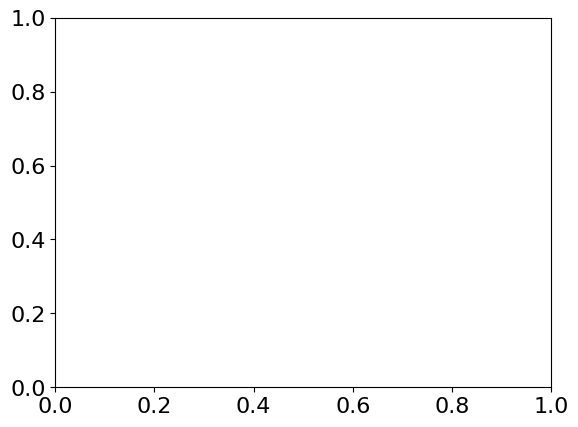

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :113.52882205513787

[0. 0. 1.]


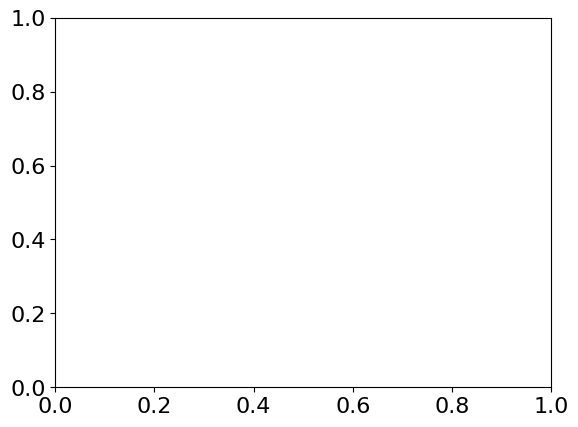

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :113.08270676691728

[0. 0. 1.]


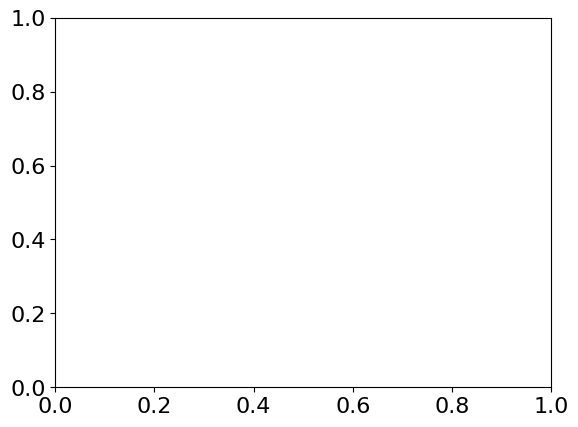

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :112.63659147869674

[0. 0. 1.]


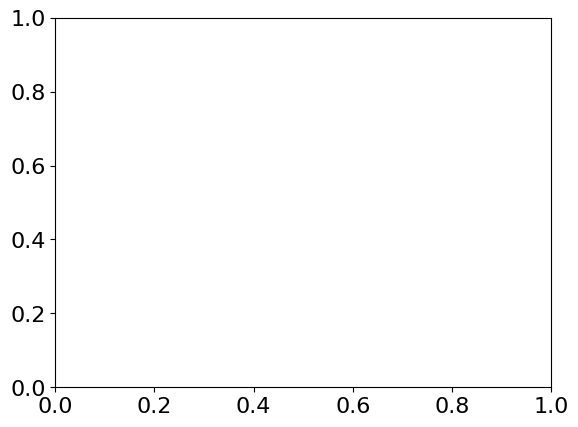

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :112.1904761904762

[0. 0. 1.]


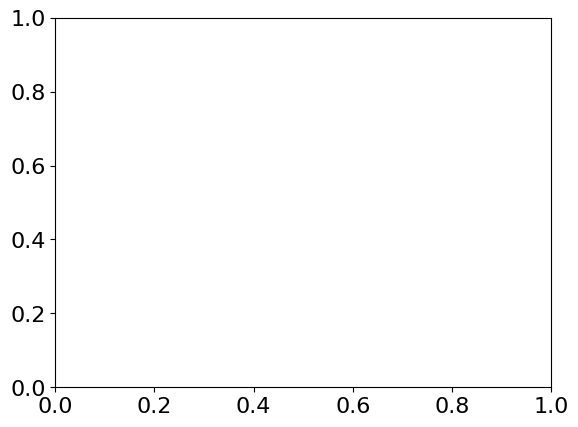

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :111.74436090225564

[0. 0. 1.]


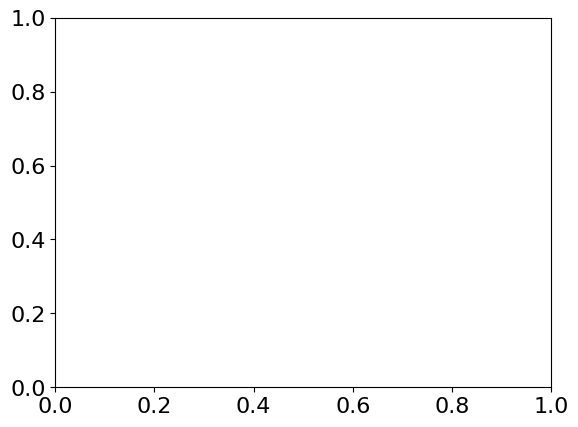

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :111.2982456140351

[0. 0. 1.]


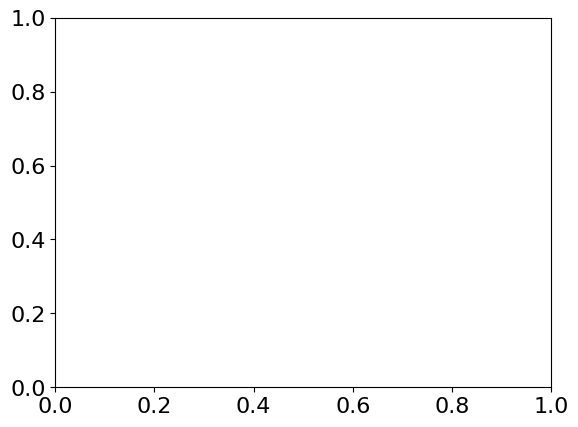

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :110.85213032581456

[0. 0. 1.]


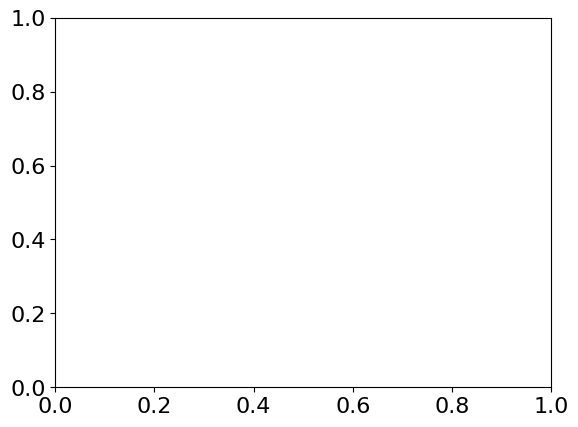

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :110.40601503759397

[0. 0. 1.]


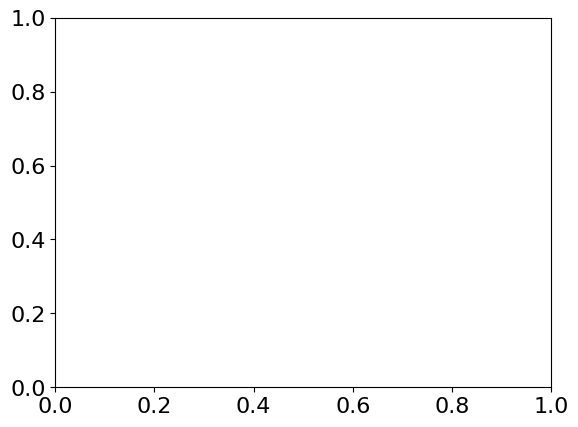

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :109.95989974937343

[0. 0. 1.]


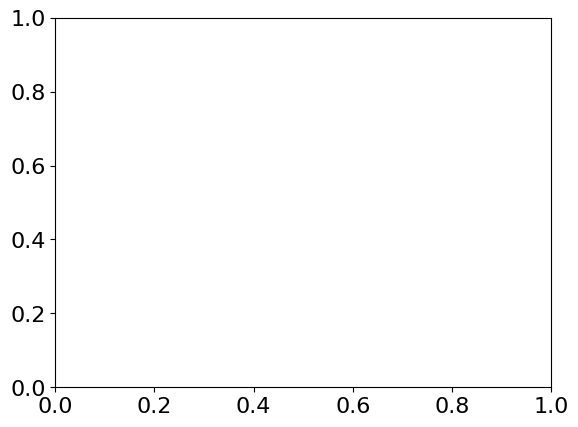

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :109.51378446115288

[0. 0. 1.]


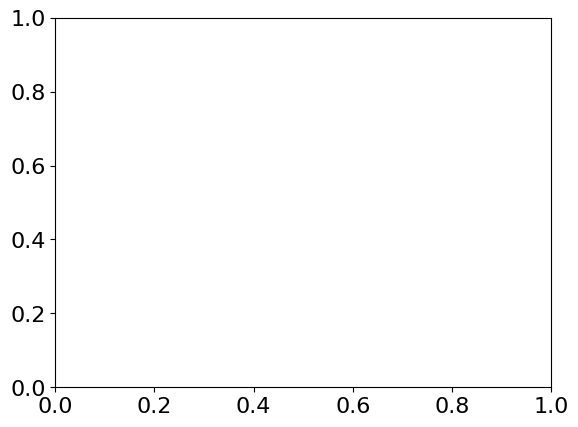

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :109.06766917293233

[0. 0. 1.]


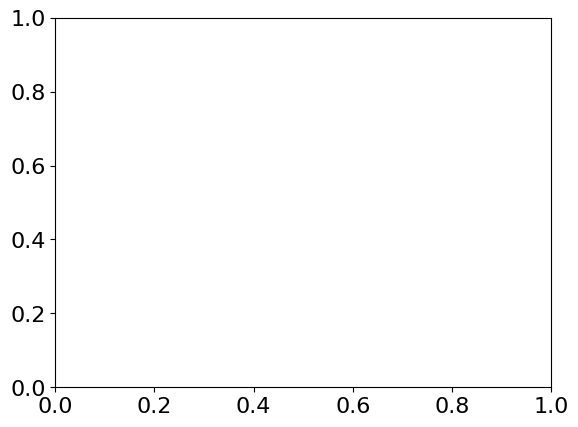

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :108.62155388471179

[0. 0. 1.]


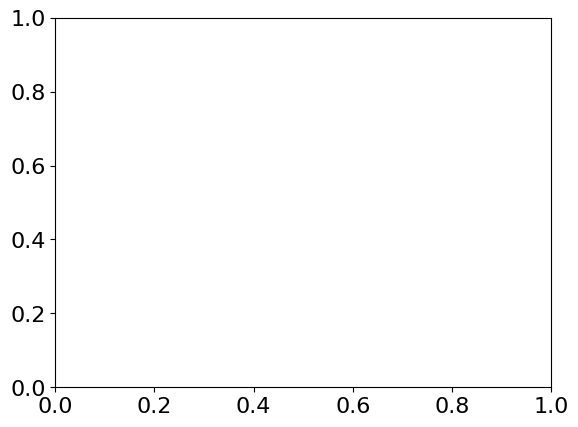

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :108.17543859649123

[0. 0. 1.]


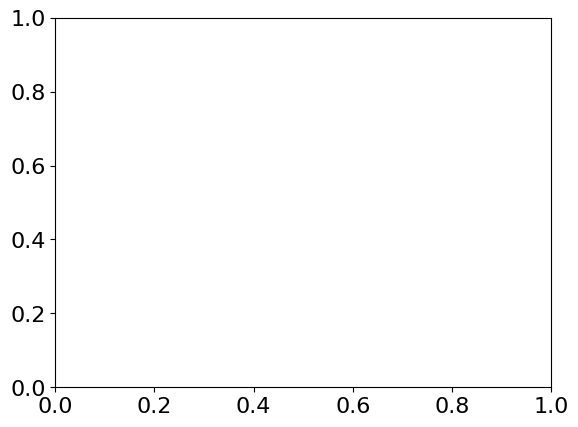

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :107.72932330827068

[0. 0. 1.]


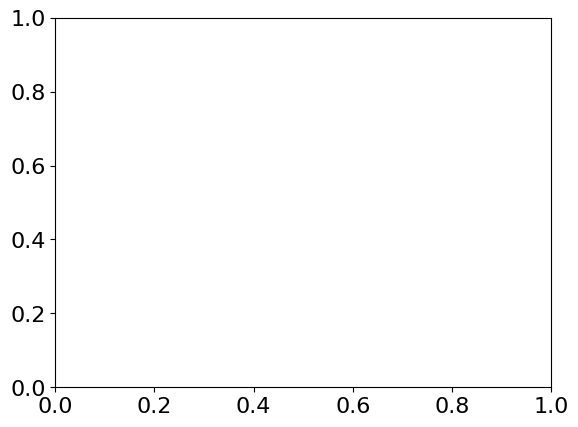

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :107.28320802005014

[0. 0. 1.]


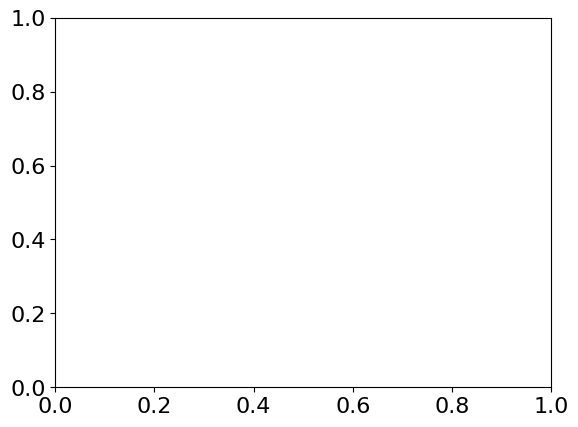

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :106.83709273182959

[0. 0. 1.]


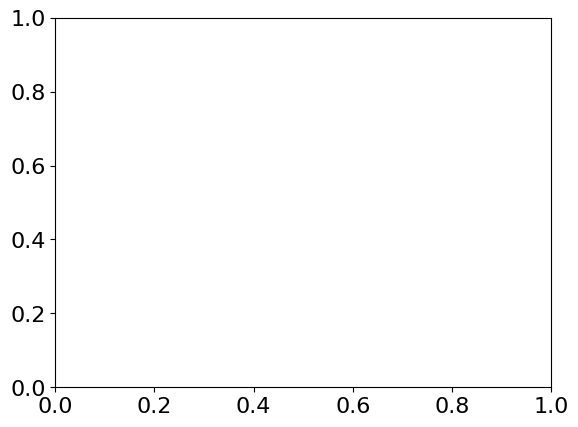

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :106.39097744360902

[0. 0. 1.]


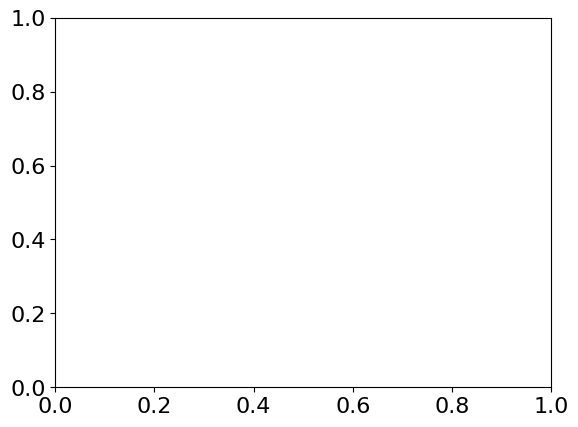

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :105.94486215538848

[0. 0. 1.]


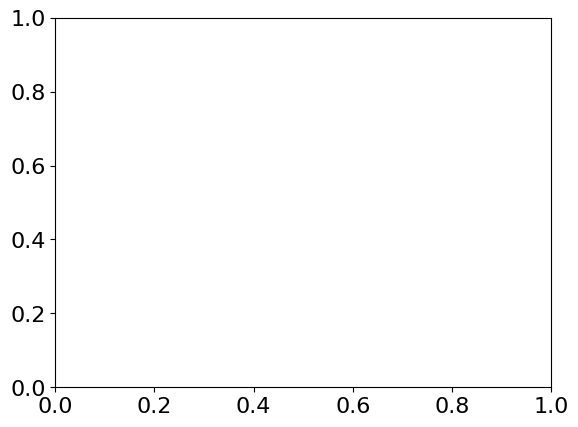

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :105.49874686716792

[0. 0. 1.]


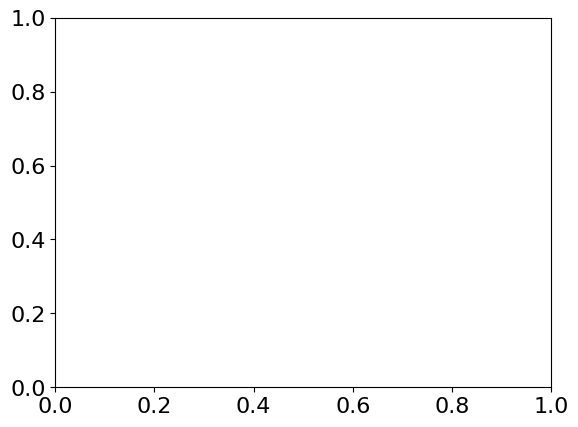

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :105.05263157894737

[0. 0. 1.]


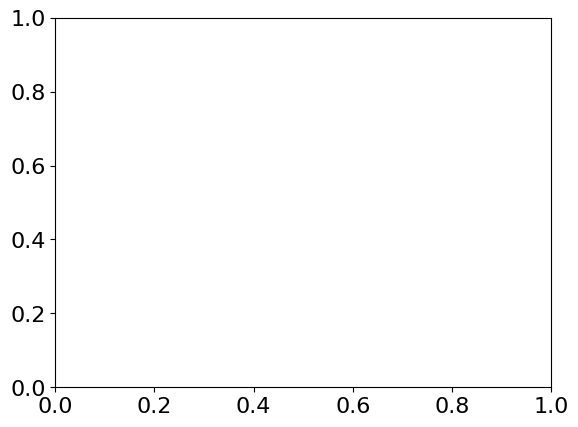

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :104.60651629072682

[0. 0. 1.]


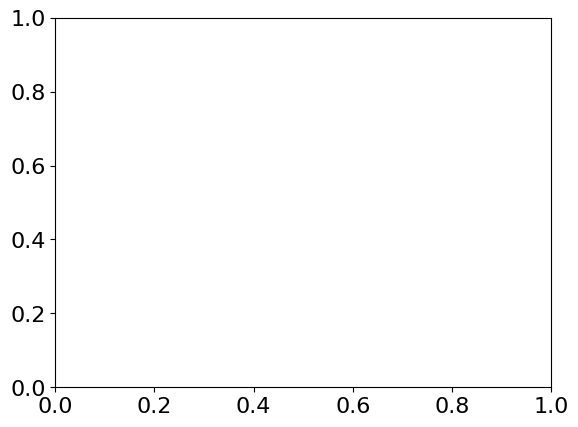

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :104.16040100250628

[0. 0. 1.]


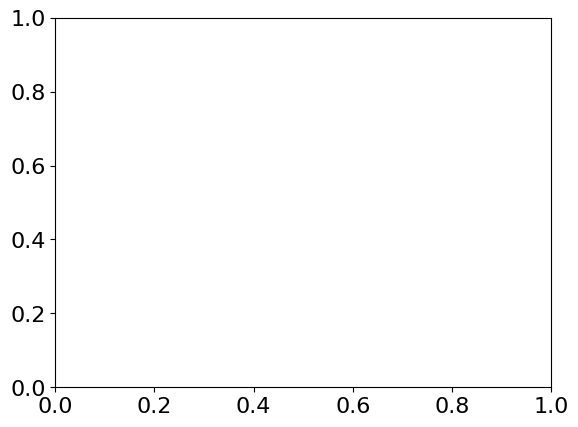

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :103.71428571428572

[0. 0. 1.]


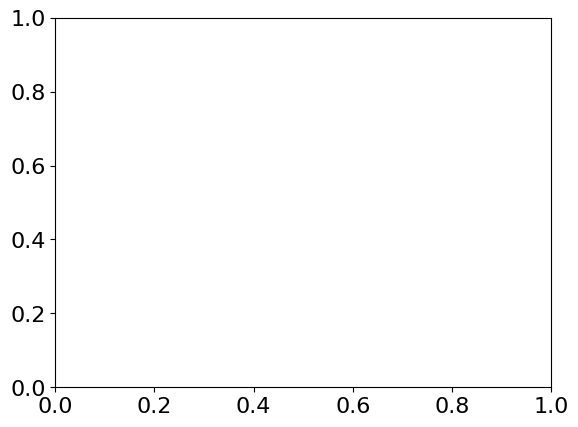

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :103.26817042606515

[0. 0. 1.]


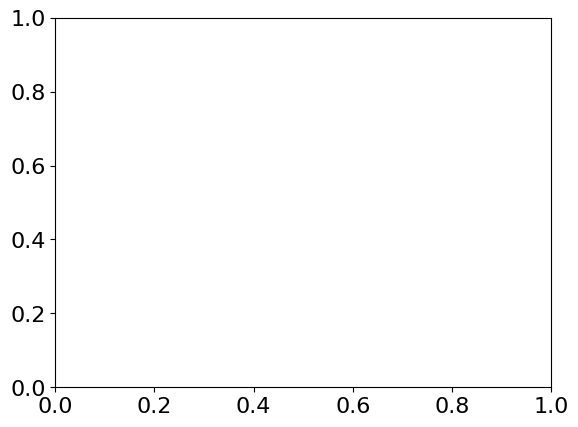

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :102.82205513784461

[0. 0. 1.]


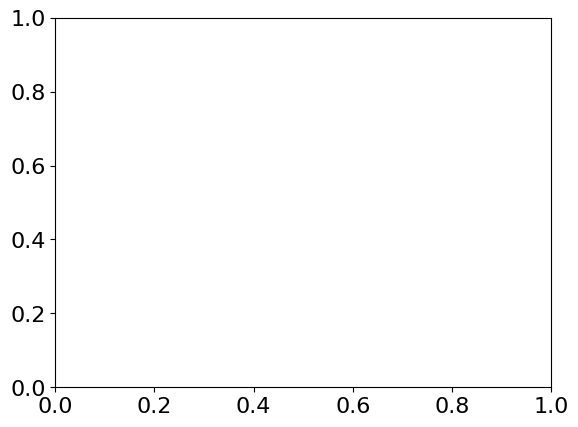

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :102.37593984962406

[0. 0. 1.]


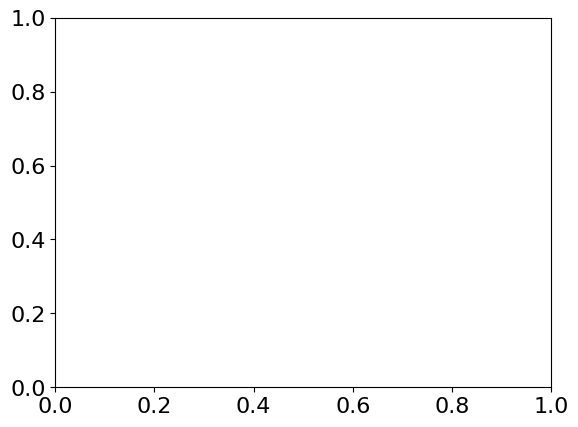

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :101.9298245614035

[0. 0. 1.]


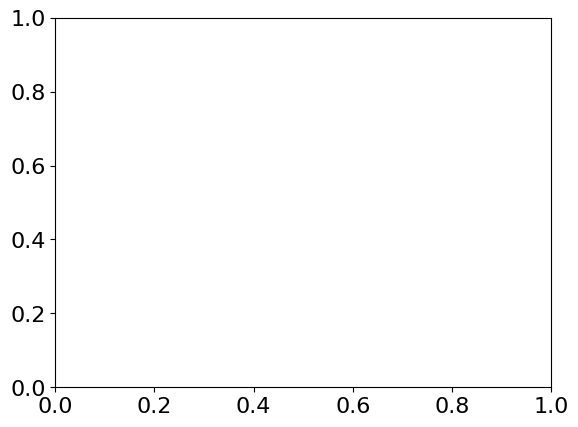

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :101.48370927318297

[0. 0. 1.]


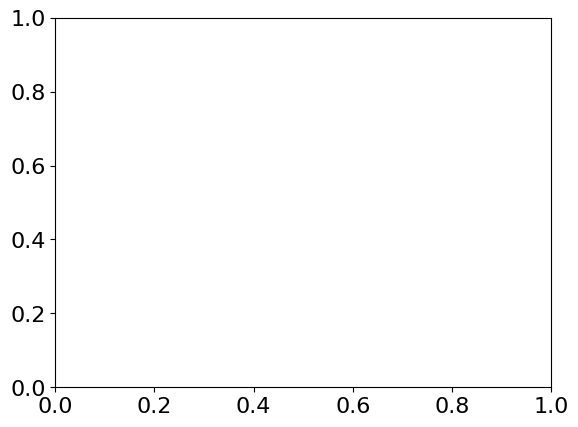

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :101.03759398496241

[0. 0. 1.]


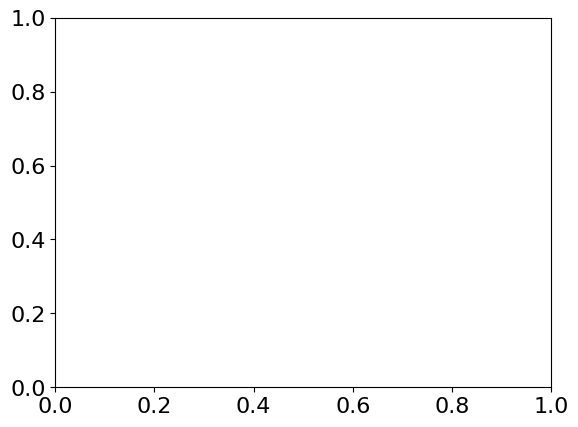

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :100.59147869674186

[0. 0. 1.]


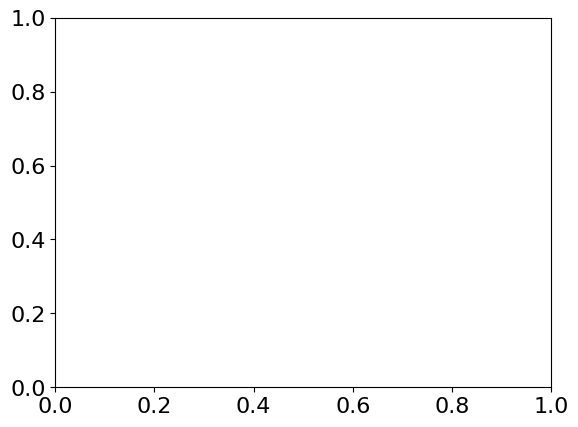

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :100.14536340852132

[0. 0. 1.]


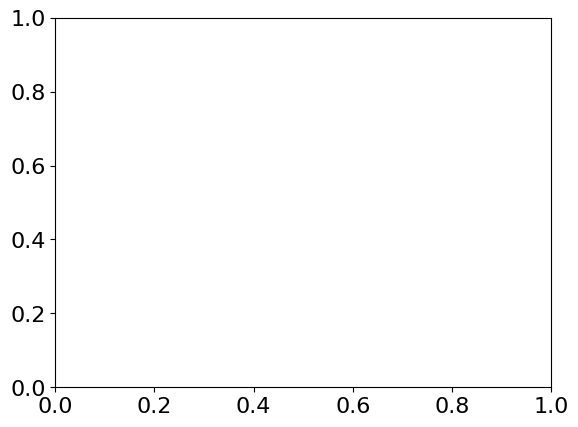

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :99.69924812030077

[0. 0. 1.]


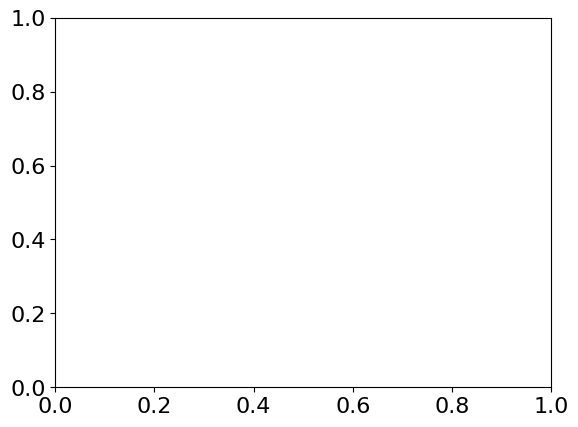

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :99.2531328320802

[0. 0. 1.]


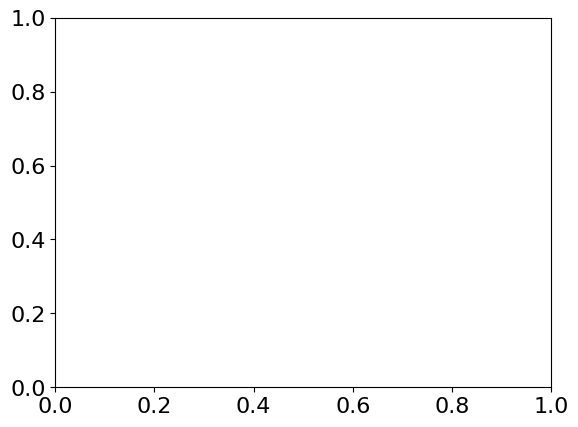

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :98.80701754385966

[0. 0. 1.]


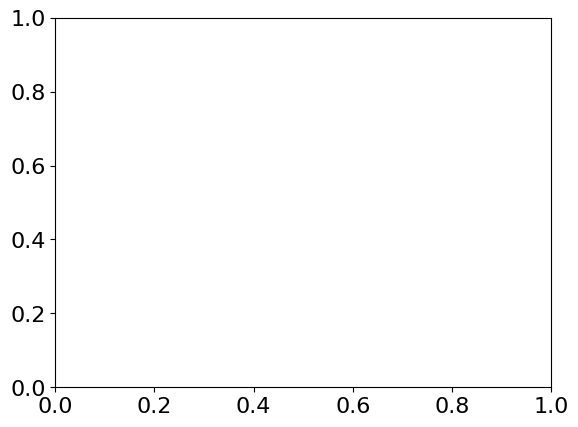

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :98.3609022556391

[0. 0. 1.]


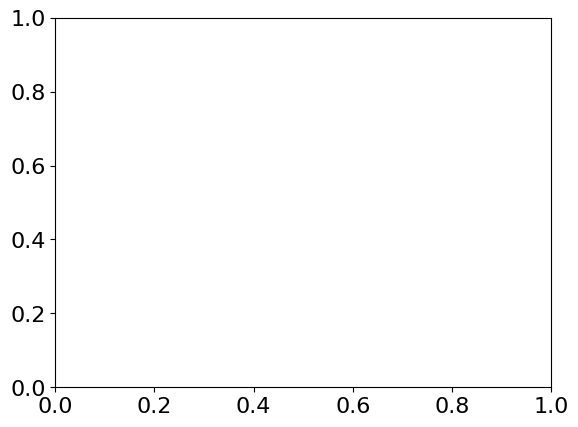

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :97.91478696741855

[0. 0. 1.]


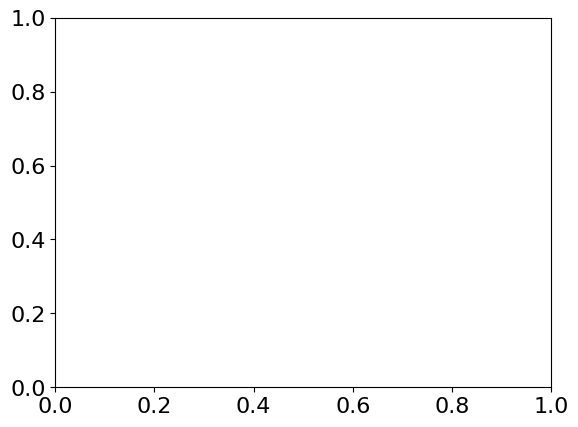

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :97.46867167919801

[0. 0. 1.]


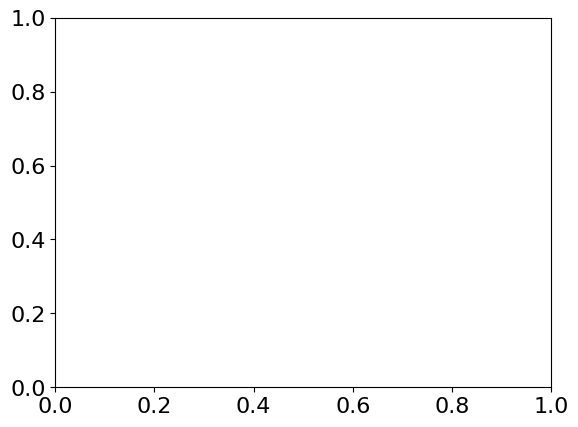

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :97.02255639097746

[0. 0. 1.]


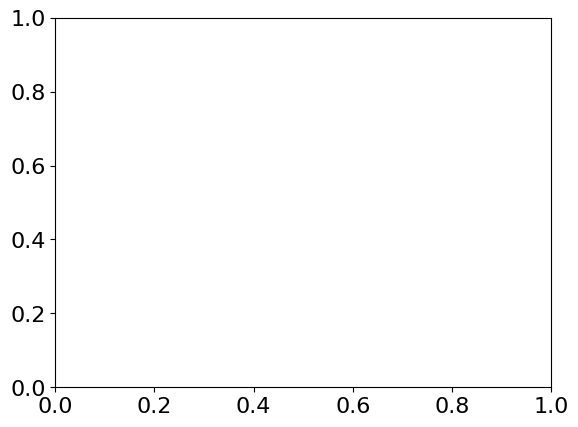

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :96.5764411027569

[0. 0. 1.]


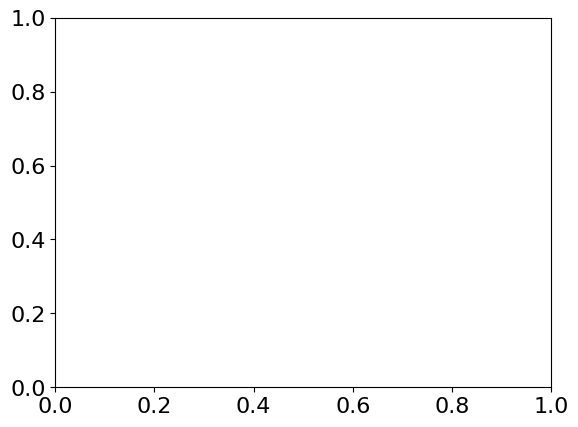

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :96.13032581453633

[0. 0. 1.]


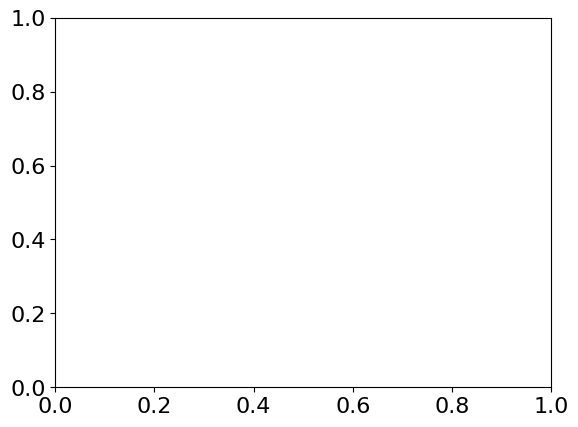

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :95.6842105263158

[0. 0. 1.]


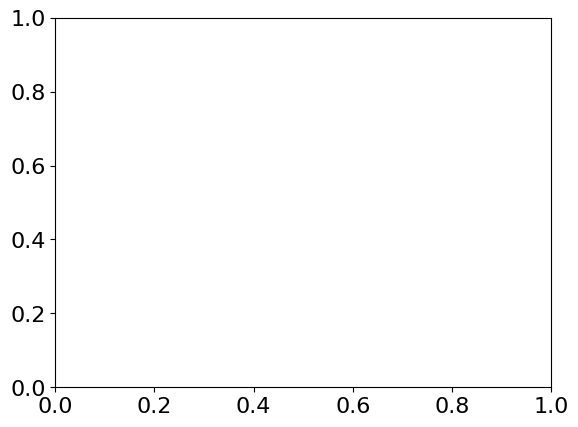

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :95.23809523809524

[0. 0. 1.]


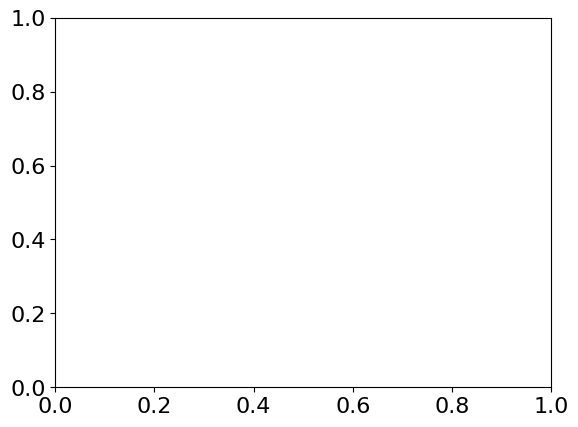

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :94.79197994987469

[0. 0. 1.]


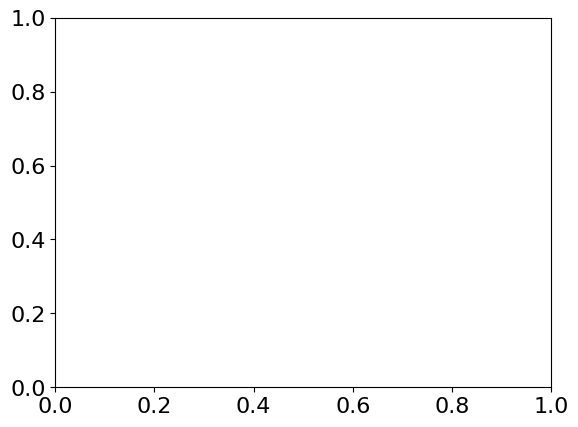

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :94.34586466165415

[0. 0. 1.]


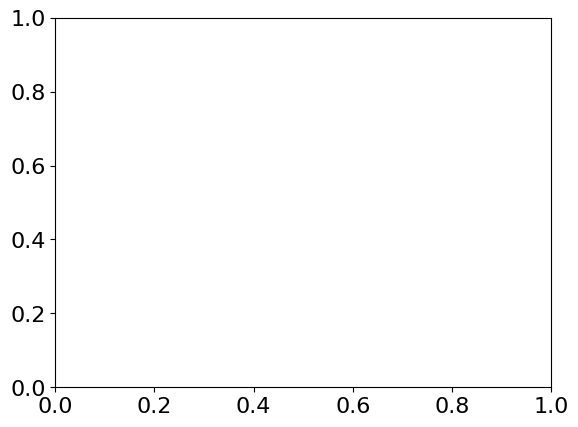

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :93.8997493734336

[0. 0. 1.]


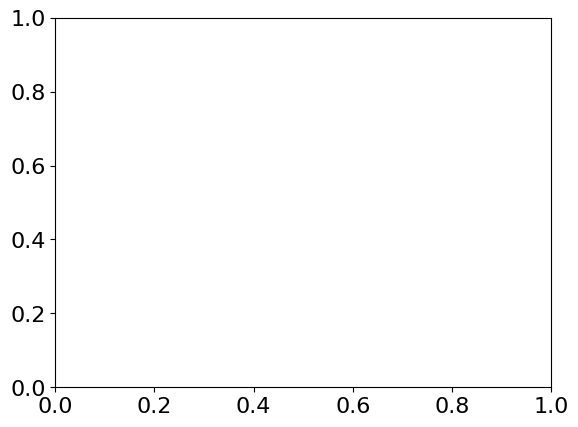

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :93.45363408521304

[0. 0. 1.]


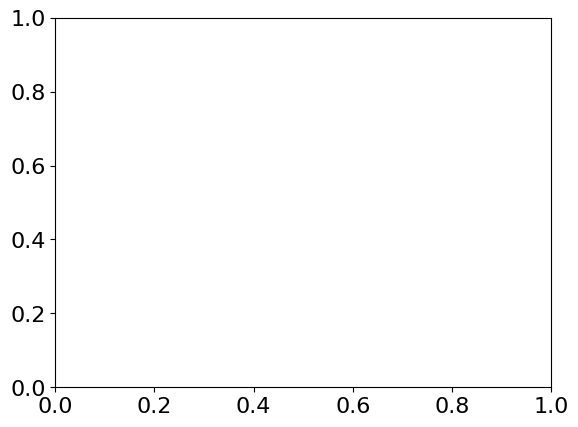

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :93.0075187969925

[0. 0. 1.]


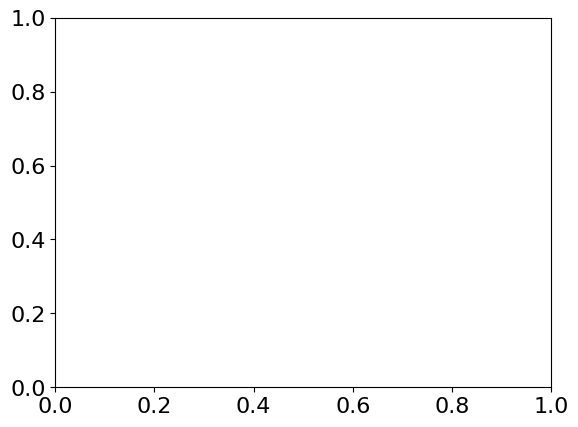

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :92.56140350877195

[0. 0. 1.]


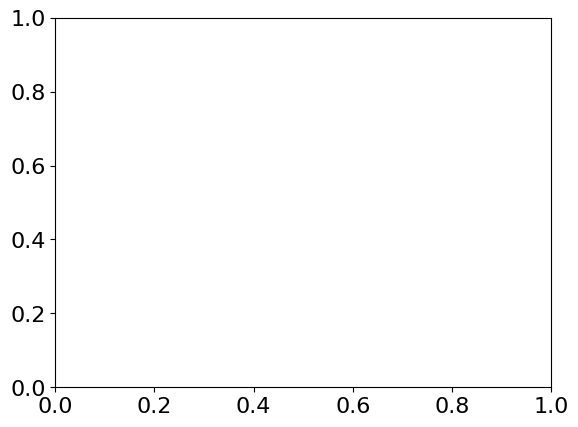

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :92.11528822055138

[0. 0. 1.]


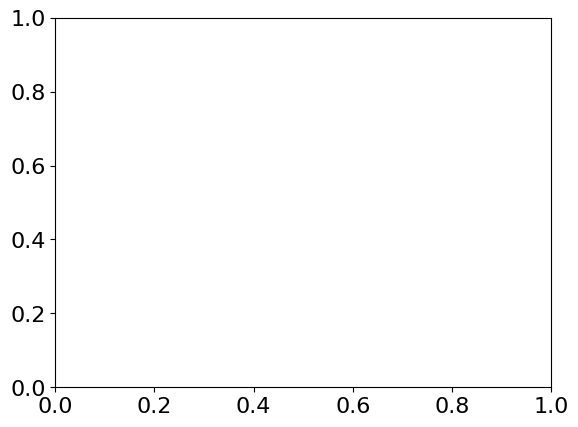

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :91.66917293233082

[0. 0. 1.]


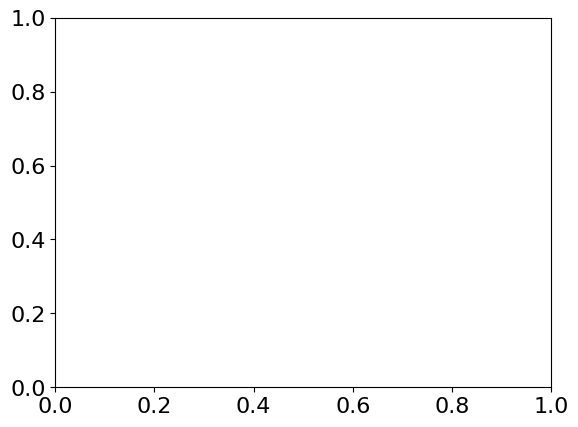

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :91.22305764411027

[0. 0. 1.]


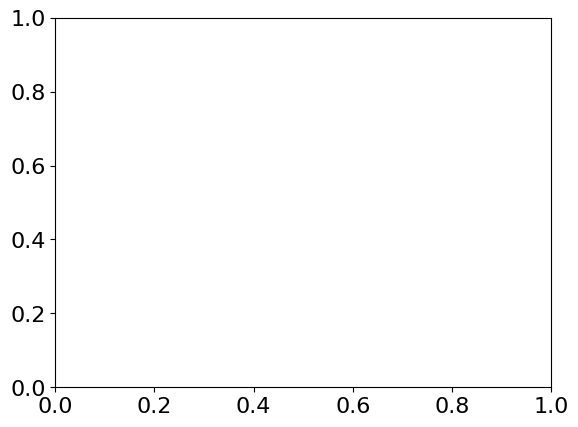

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :90.77694235588973

[0. 0. 1.]


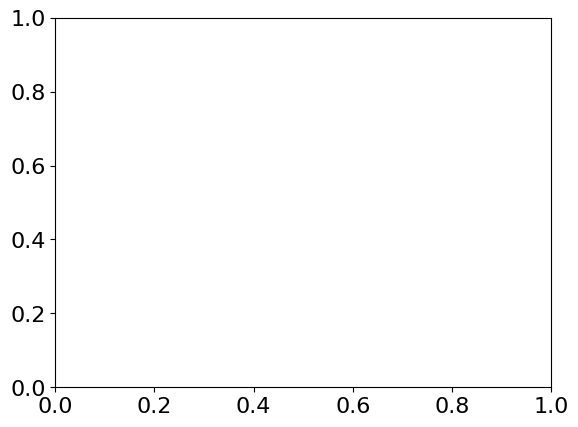

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :90.33082706766918

[0. 0. 1.]


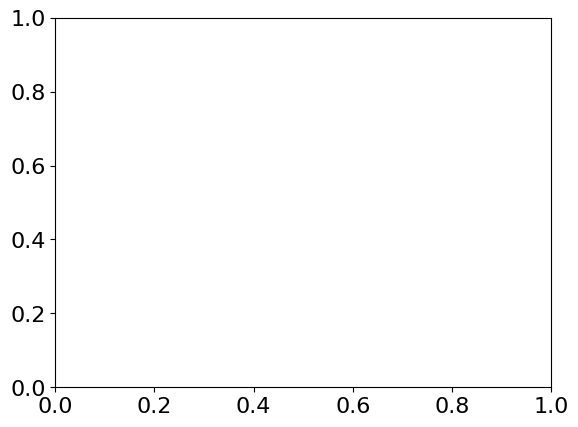

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :89.88471177944862

[0. 0. 1.]


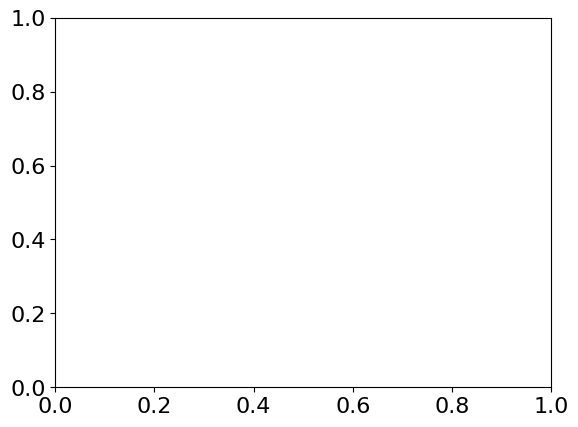

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :89.43859649122808

[0. 0. 1.]


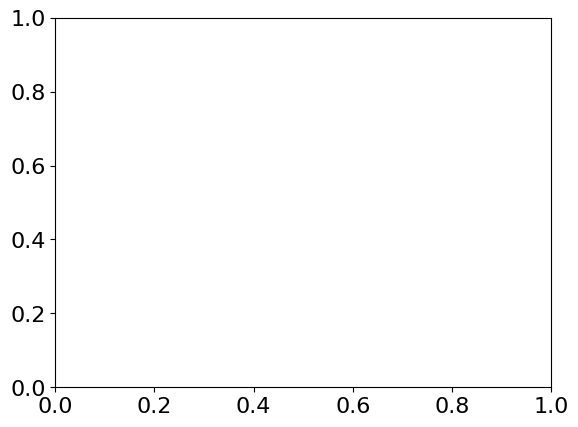

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :88.99248120300751

[0. 0. 1.]


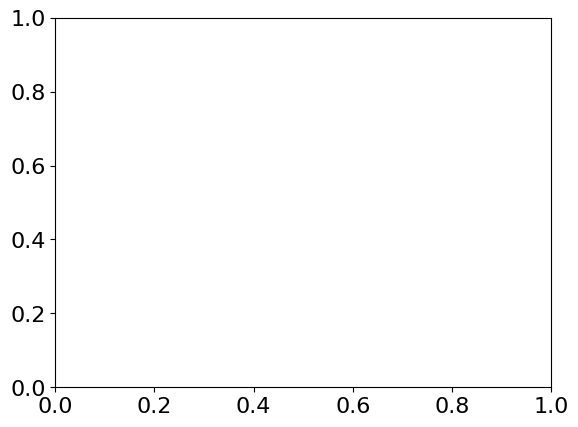

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :88.54636591478696

[0. 0. 1.]


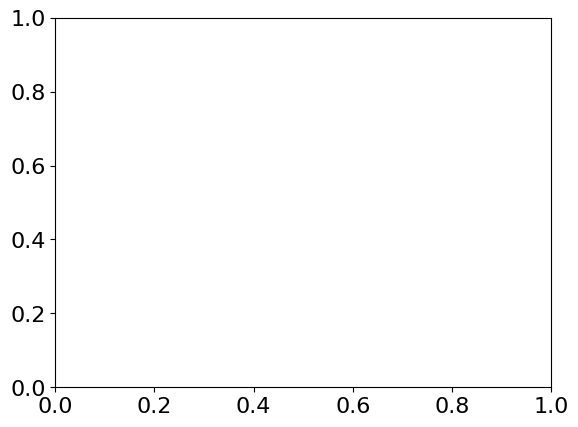

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :88.10025062656642

[0. 0. 1.]


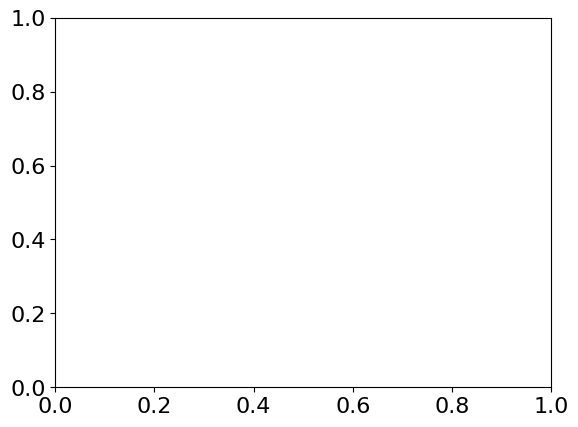

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :87.65413533834587

[0. 0. 1.]


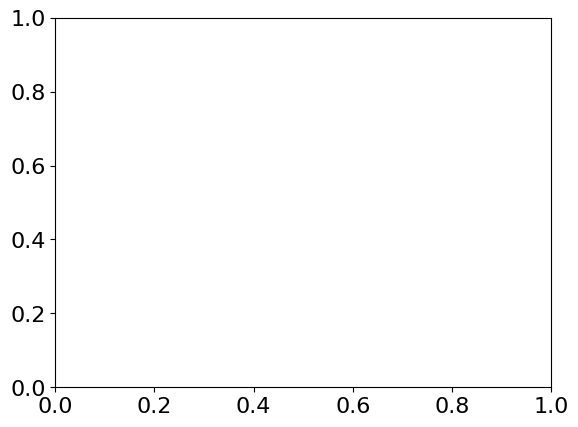

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :87.20802005012531

[0. 0. 1.]


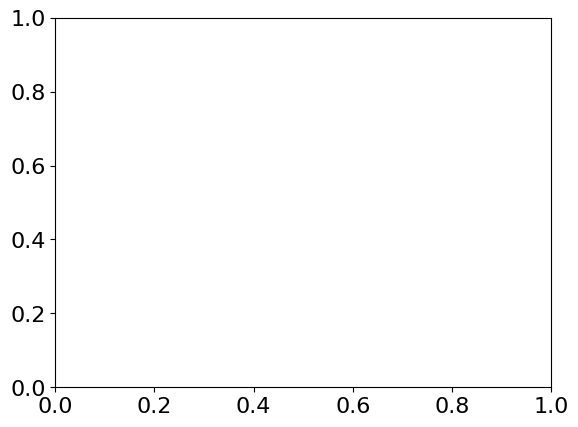

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :86.76190476190477

[0. 0. 1.]


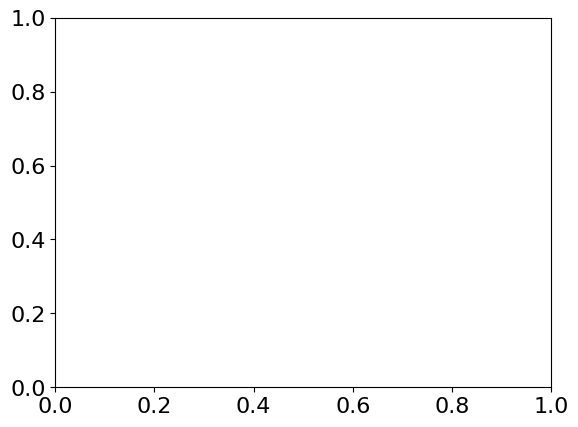

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :86.31578947368422

[0. 0. 1.]


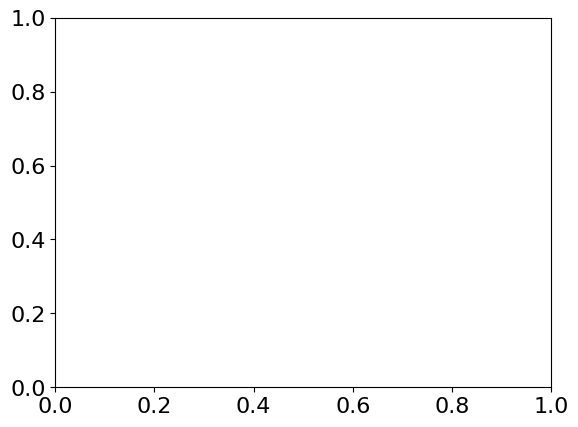

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :85.86967418546365

[0. 0. 1.]


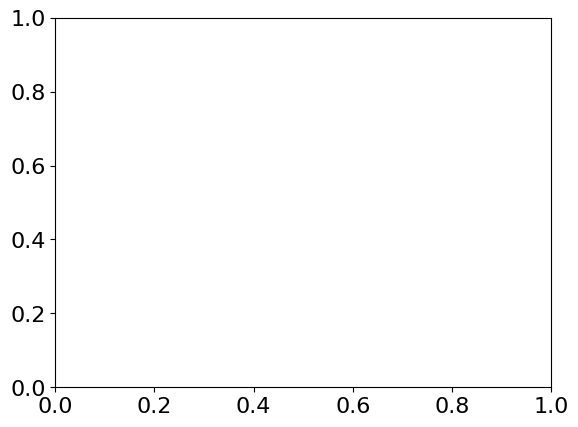

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :85.42355889724313

[0. 0. 1.]


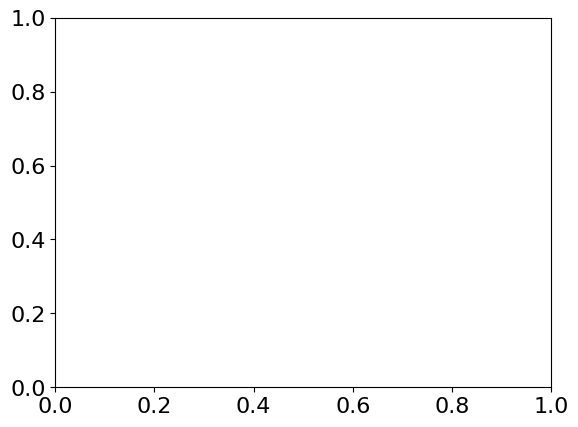

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :84.97744360902256

[0. 0. 1.]


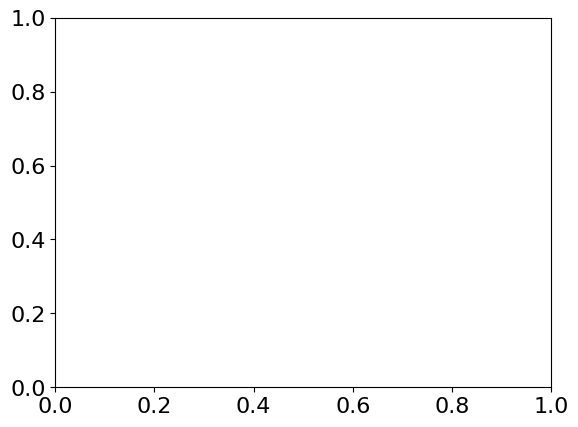

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :84.531328320802

[0. 0. 1.]


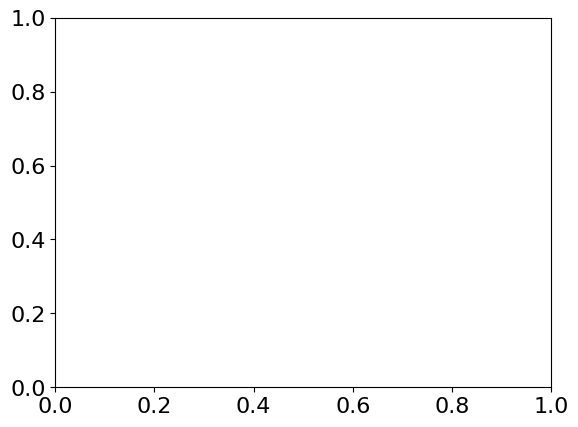

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :84.08521303258146

[0. 0. 1.]


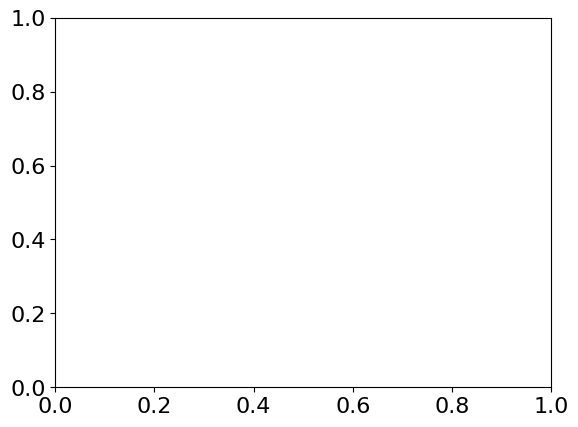

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :83.63909774436091

[0. 0. 1.]


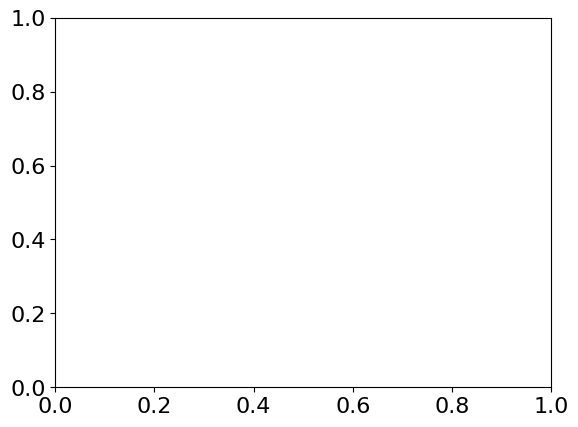

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :83.19298245614036

[0. 0. 1.]


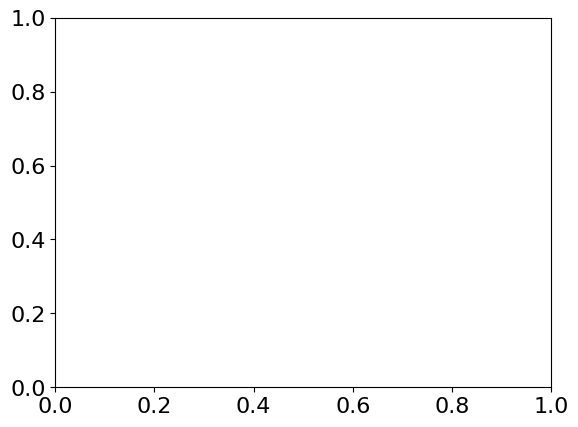

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :82.7468671679198

[0. 0. 1.]


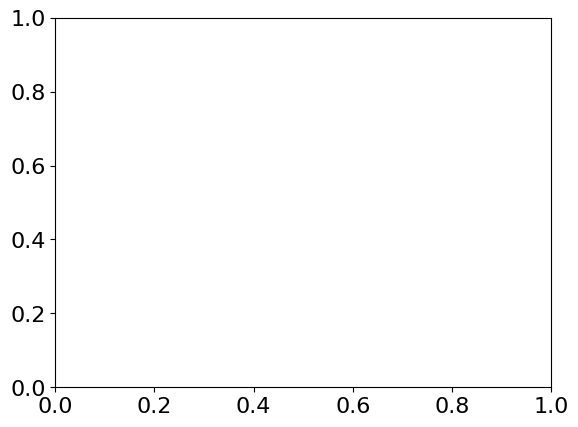

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :82.30075187969926

[0. 0. 1.]


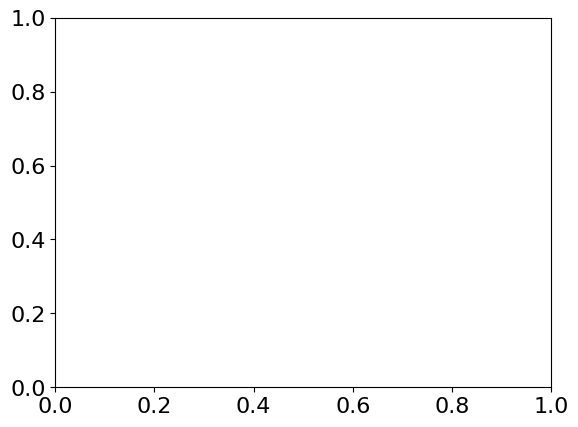

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :81.8546365914787

[0. 0. 1.]


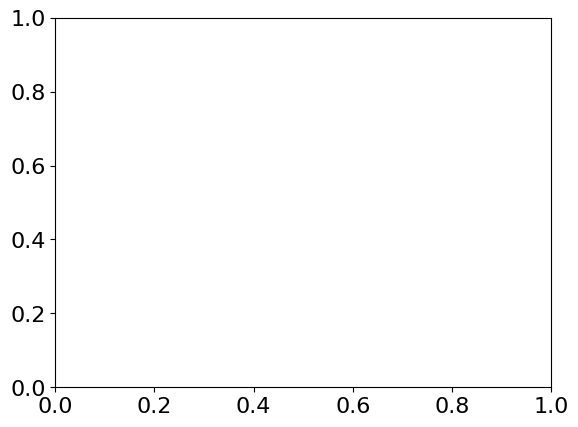

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :81.40852130325814

[0. 0. 1.]


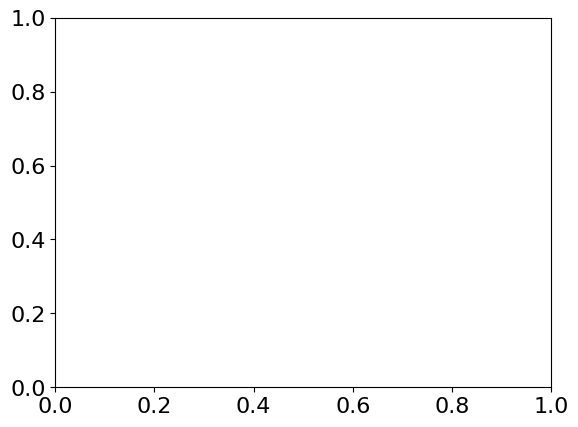

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :80.9624060150376

[0. 0. 1.]


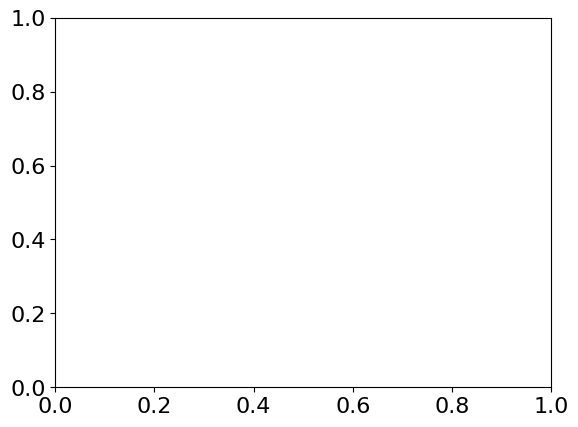

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :80.51629072681705

[0. 0. 1.]


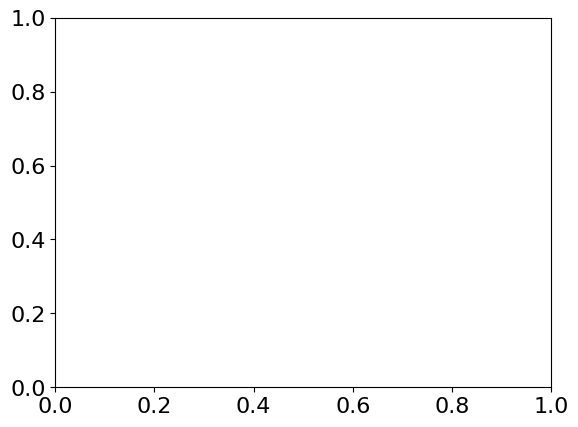

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :80.0701754385965

[0. 0. 1.]


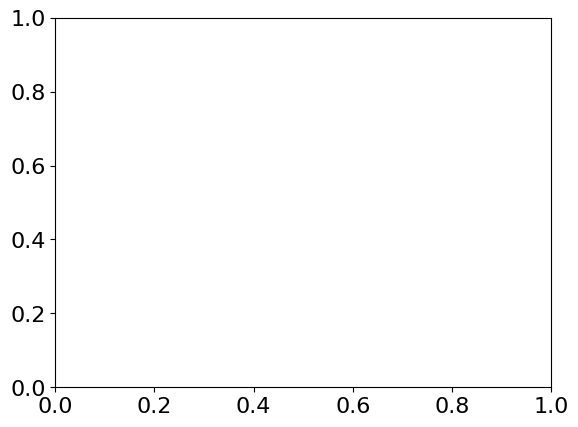

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :79.62406015037594

[0. 0. 1.]


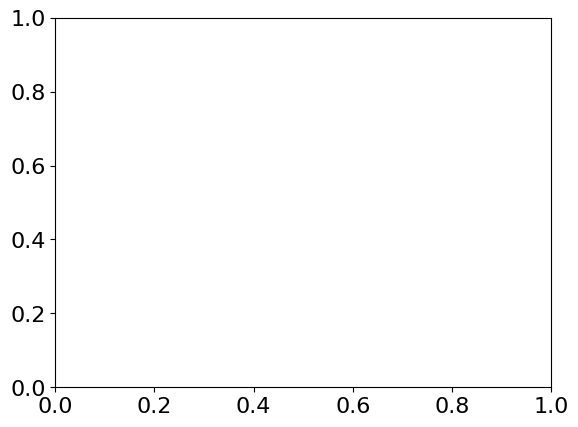

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :79.1779448621554

[0. 0. 1.]


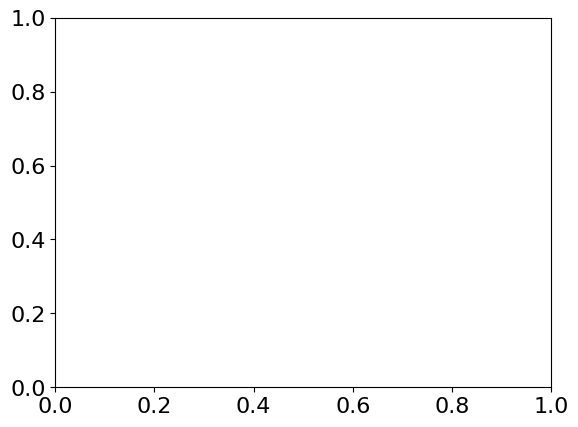

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :78.73182957393483

[0. 0. 1.]


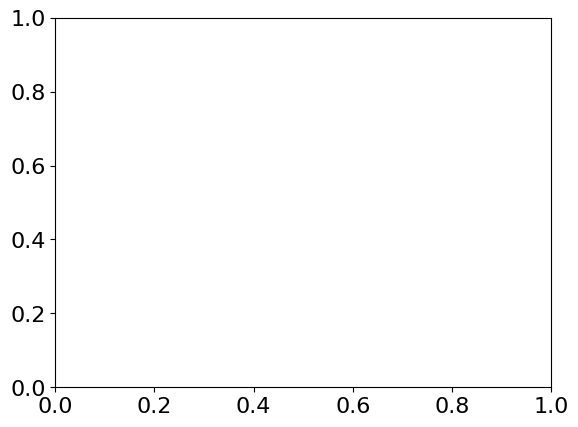

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :78.28571428571429

[0. 0. 1.]


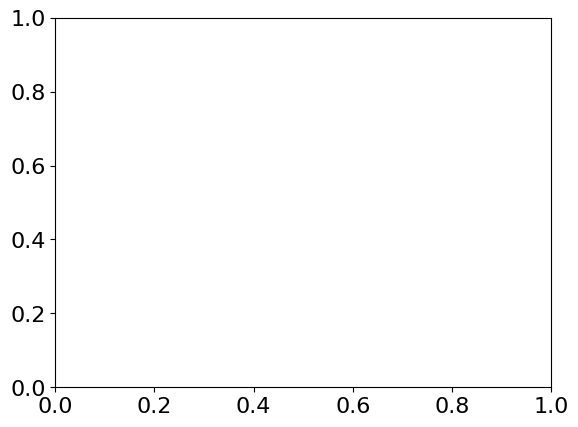

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :77.83959899749374

[0. 0. 1.]


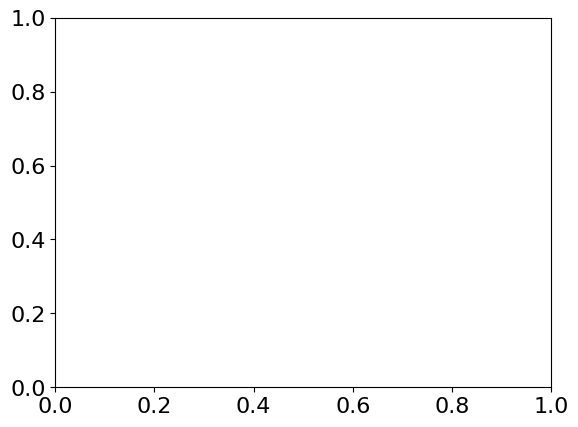

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :77.39348370927318

[0. 0. 1.]


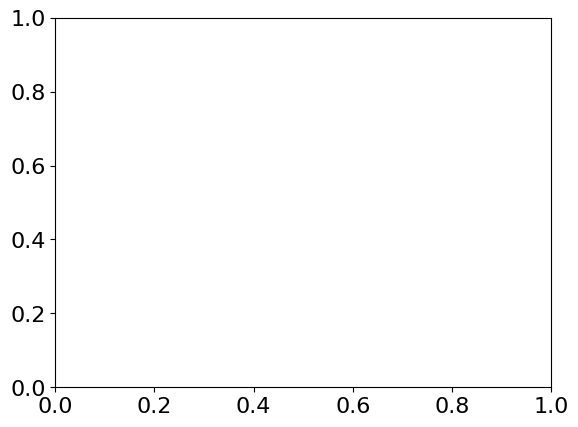

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :76.94736842105264

[0. 0. 1.]


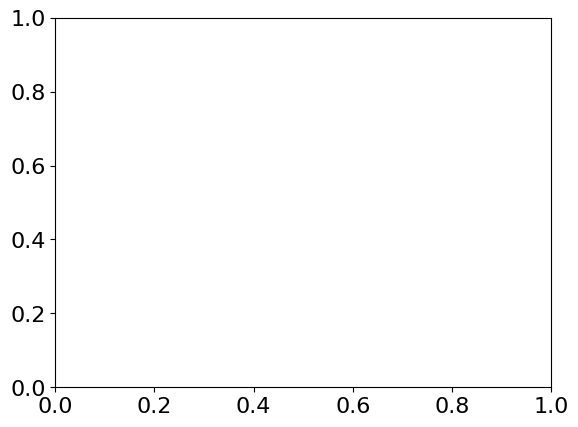

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :76.50125313283208

[0. 0. 1.]


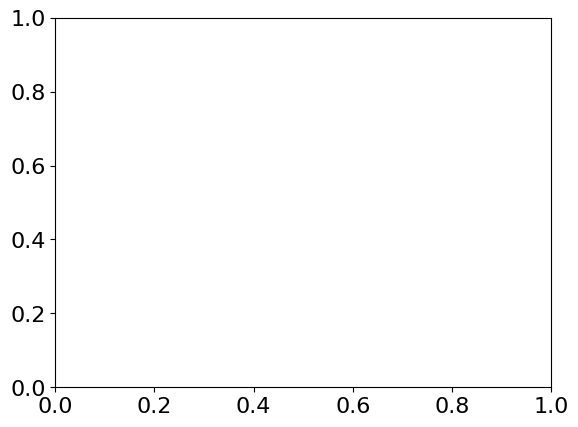

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :76.05513784461154

[0. 0. 1.]


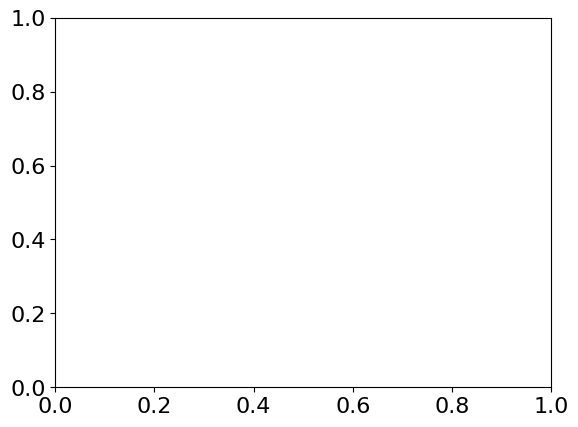

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :75.60902255639098

[0. 0. 1.]


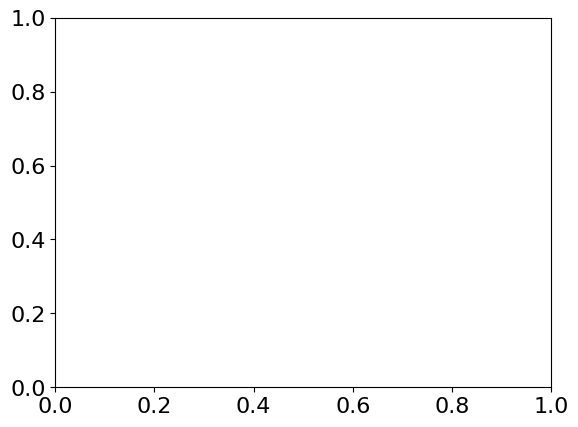

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :75.16290726817043

[0. 0. 1.]


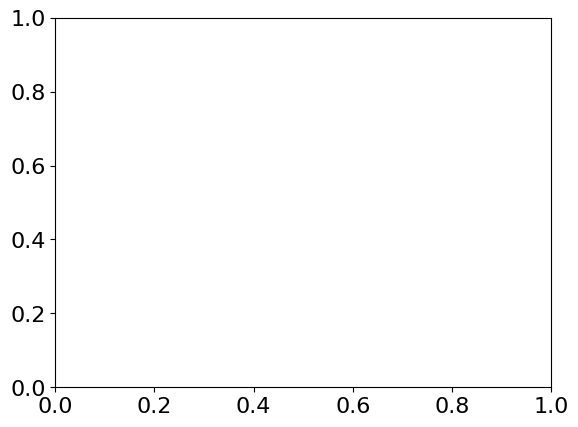

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :74.71679197994987

[0. 0. 1.]


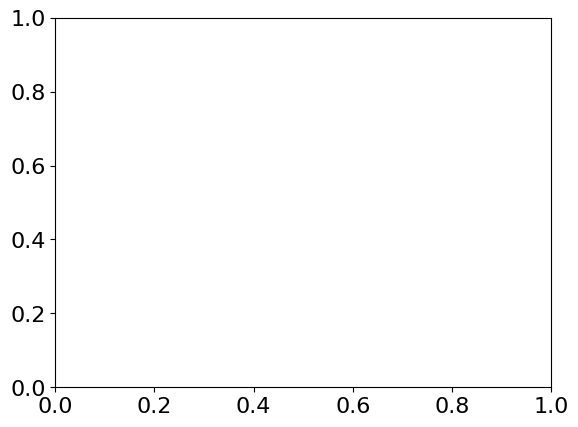

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :74.27067669172932

[0. 0. 1.]


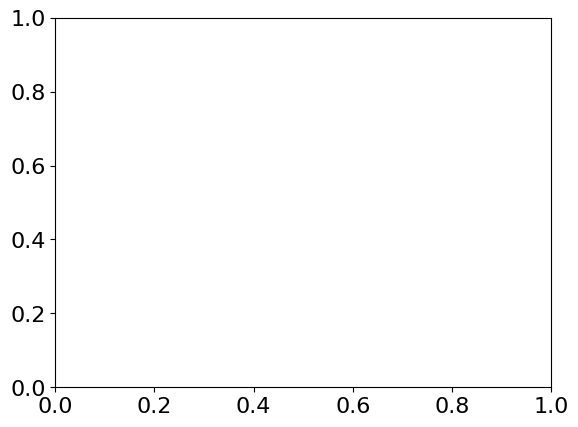

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :73.82456140350878

[0. 0. 1.]


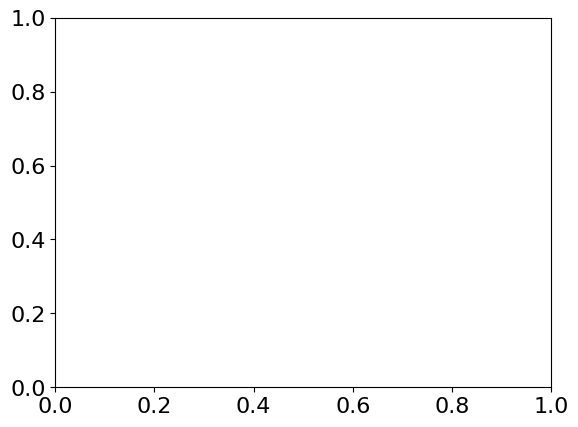

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :73.37844611528823

[0. 0. 1.]


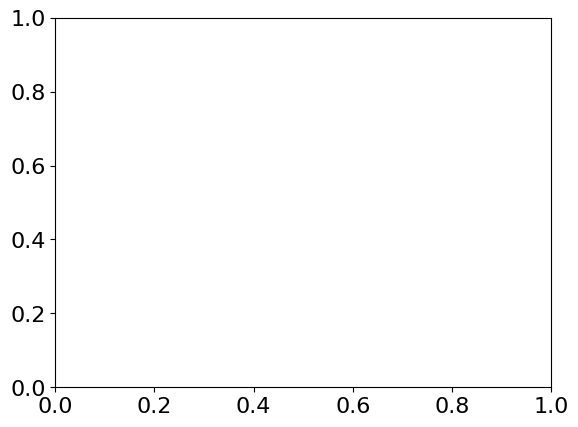

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :72.93233082706767

[0. 0. 1.]


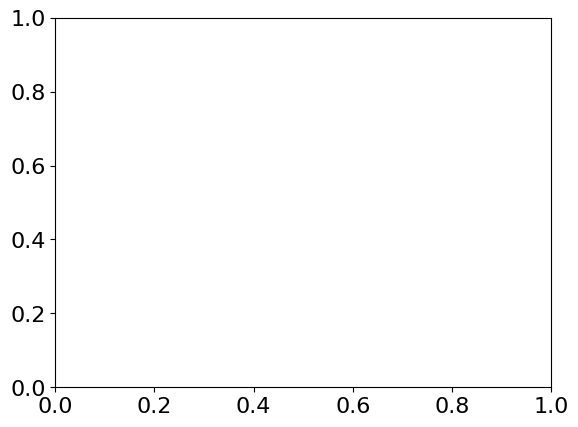

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :72.48621553884712

[0. 0. 1.]


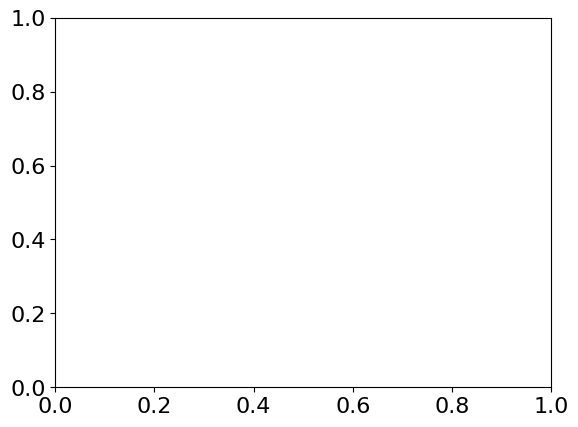

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :72.04010025062658

[0. 0. 1.]


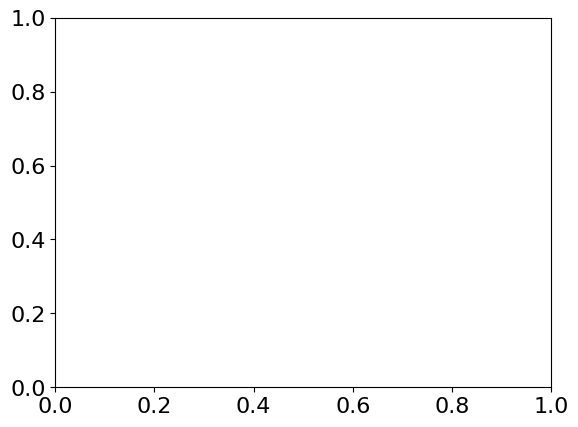

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :71.59398496240601

[0. 0. 1.]


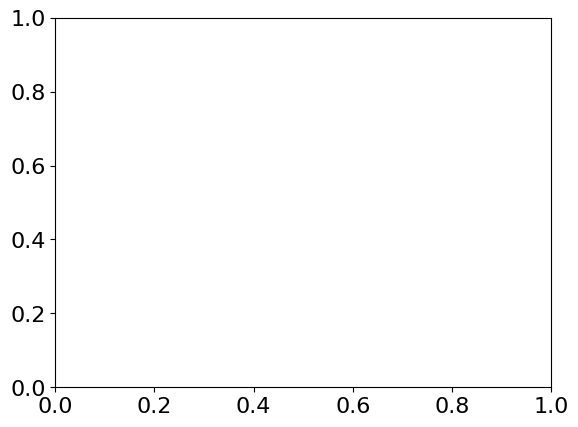

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :71.14786967418547

[0. 0. 1.]


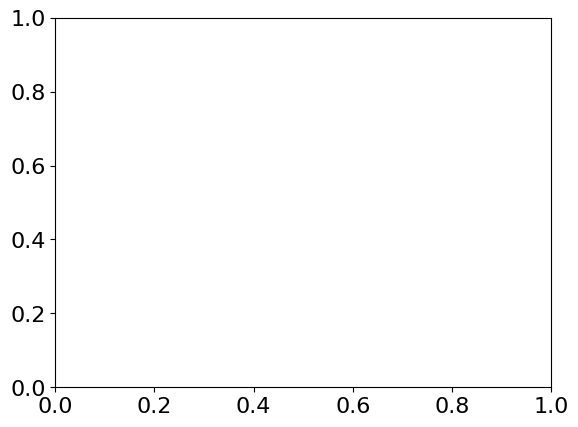

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :70.70175438596492

[0. 0. 1.]


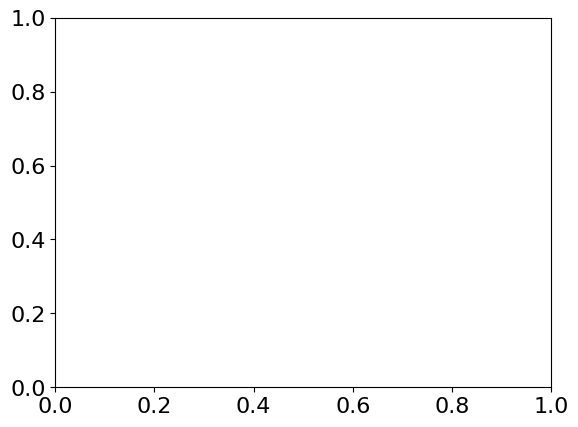

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :70.25563909774436

[0. 0. 1.]


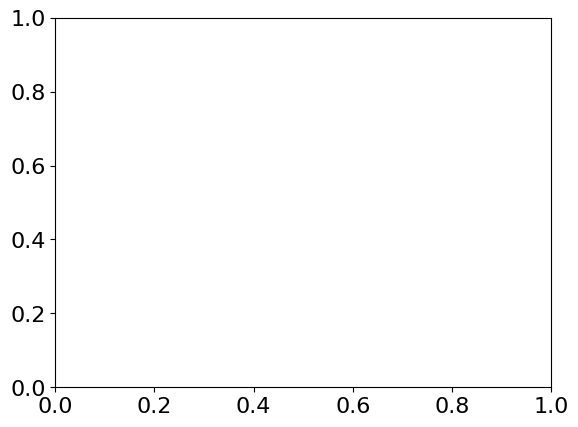

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :69.80952380952382

[0. 0. 1.]


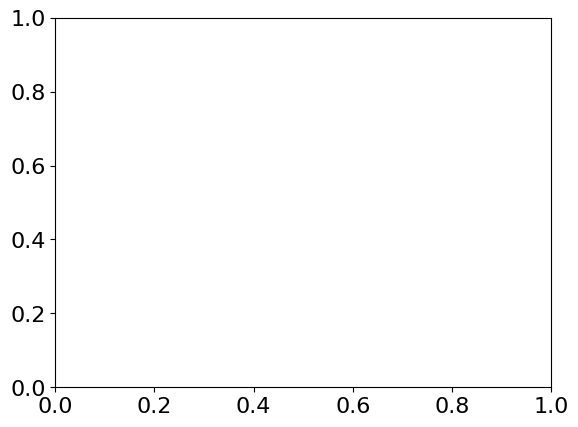

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :69.36340852130326

[0. 0. 1.]


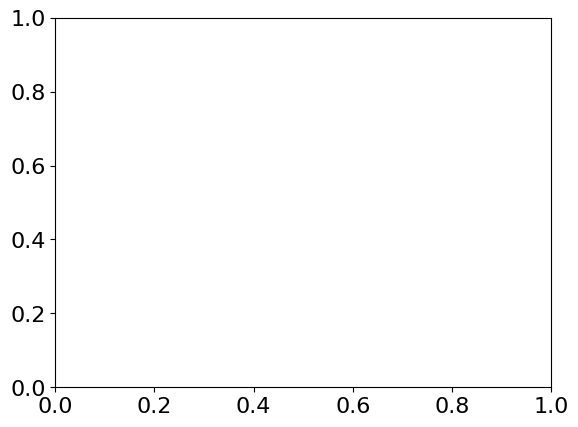

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :68.91729323308272

[0. 0. 1.]


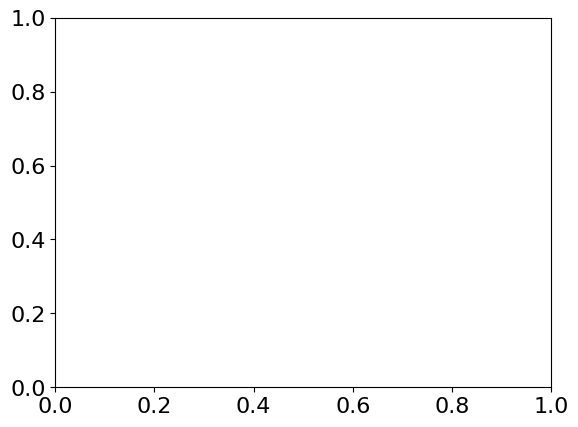

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :68.47117794486216

[0. 0. 1.]


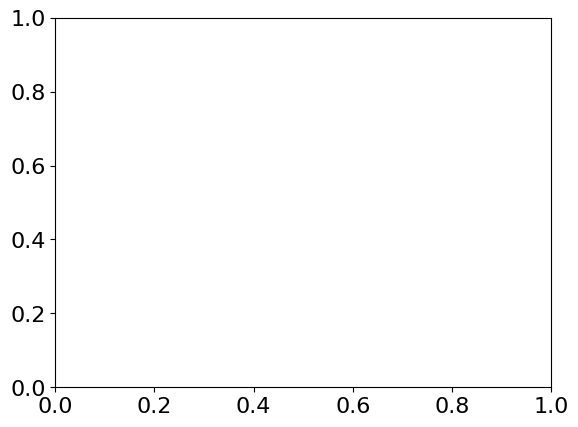

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :68.0250626566416

[0. 0. 1.]


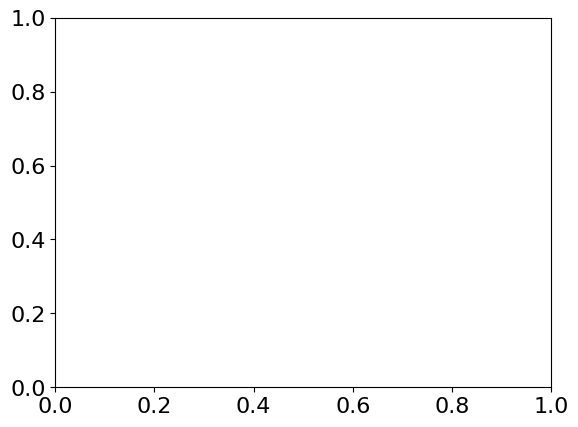

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :67.57894736842105

[0. 0. 1.]


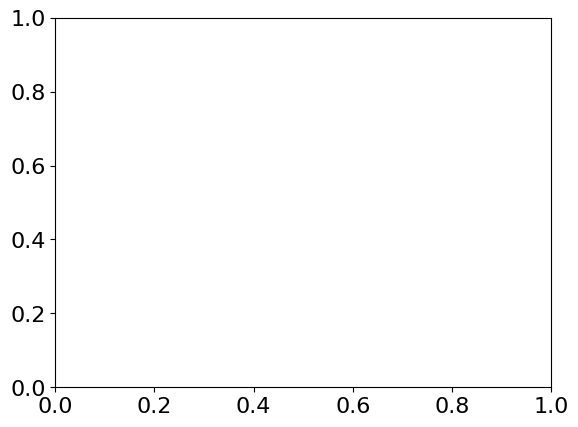

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :67.13283208020052

[0. 0. 1.]


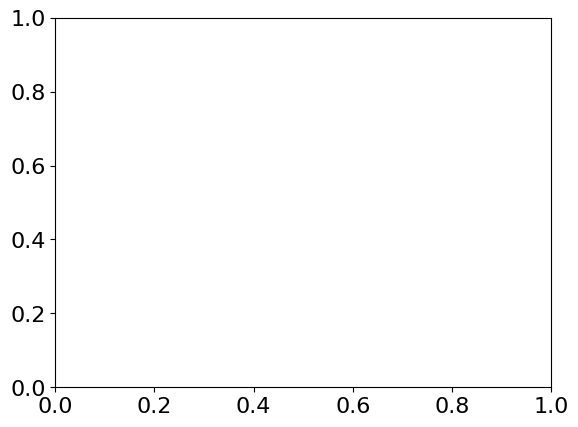

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :66.68671679197995

[0. 0. 1.]


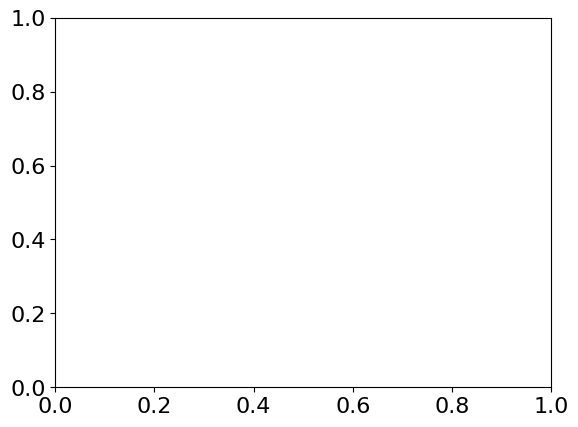

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :66.24060150375941

[0. 0. 1.]


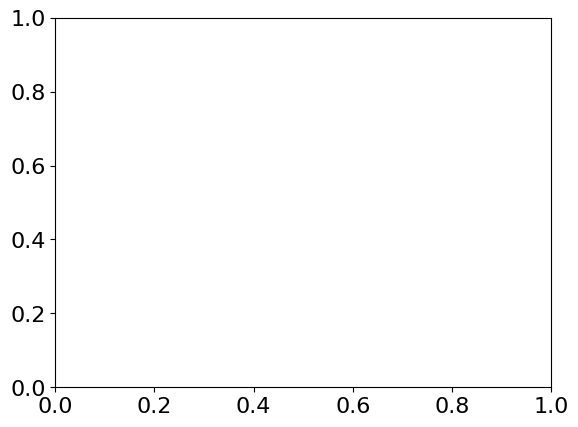

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :65.79448621553885

[0. 0. 1.]


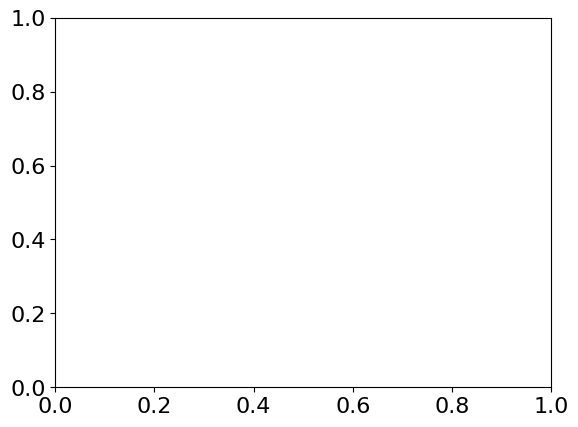

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :65.3483709273183

[0. 0. 1.]


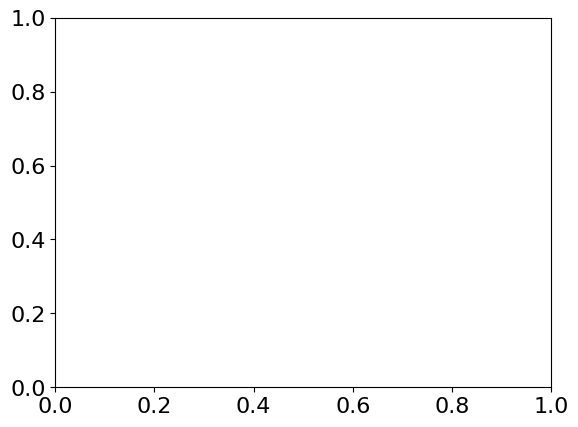

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :64.90225563909776

[0. 0. 1.]


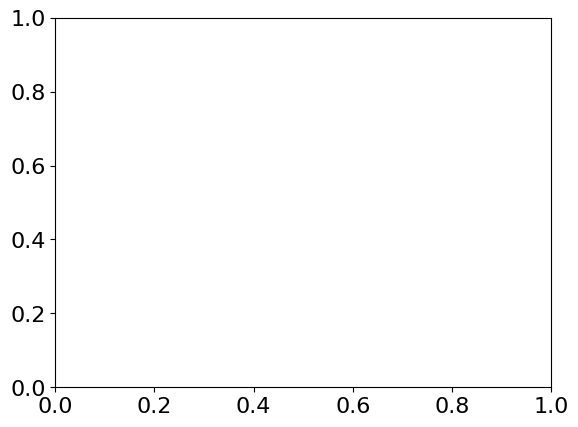

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :64.45614035087719

[0. 0. 1.]


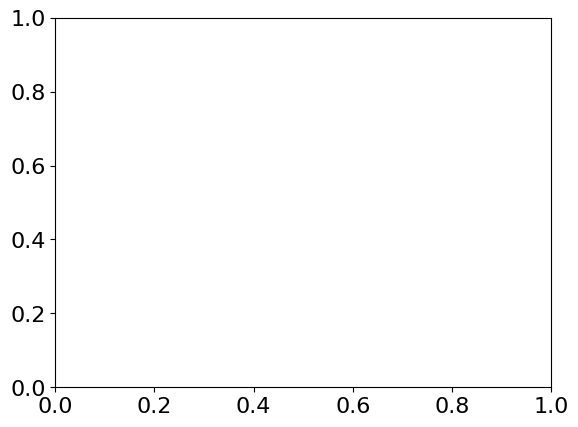

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :64.01002506265664

[0. 0. 1.]


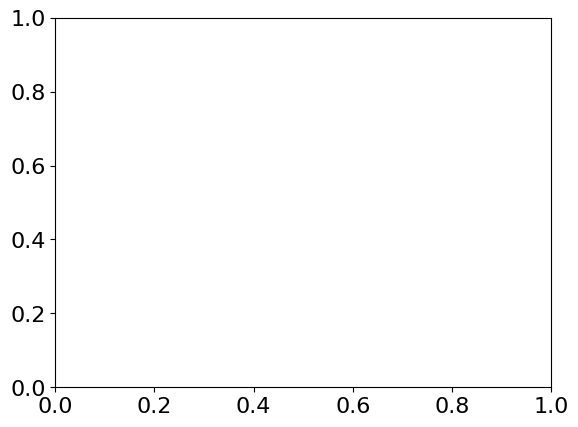

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :63.563909774436105

[0. 0. 1.]


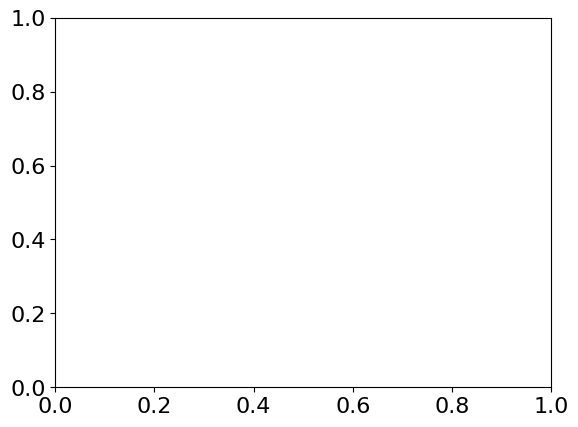

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :63.11779448621554

[0. 0. 1.]


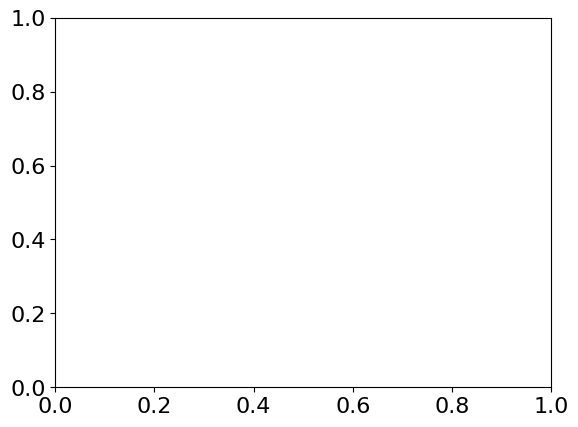

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :62.67167919799499

[0. 0. 1.]


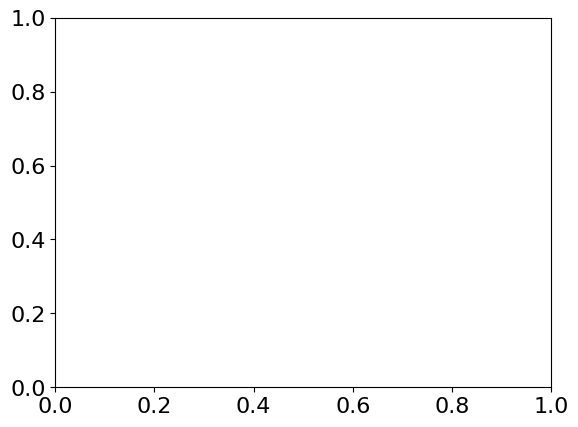

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :62.22556390977445

[0. 0. 1.]


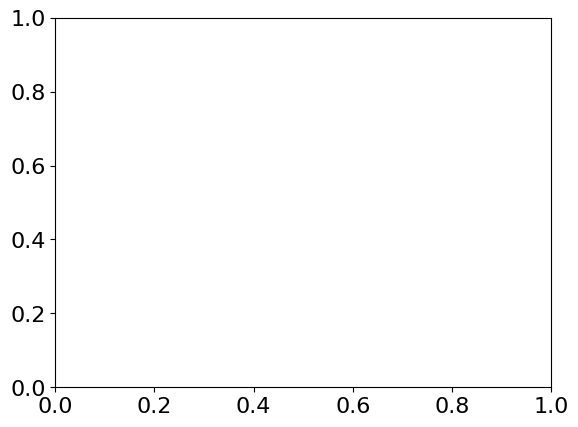

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :61.77944862155388

[0. 0. 1.]


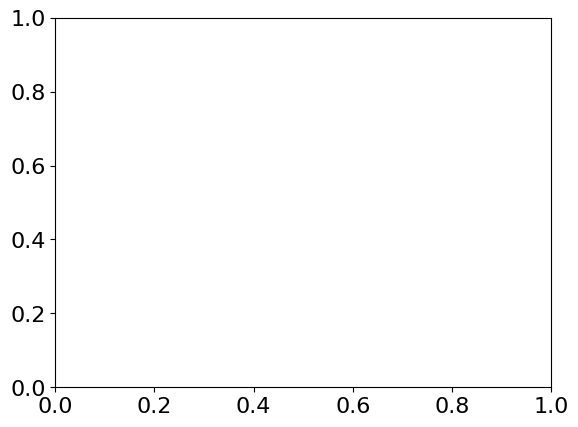

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :61.333333333333336

[0. 0. 1.]


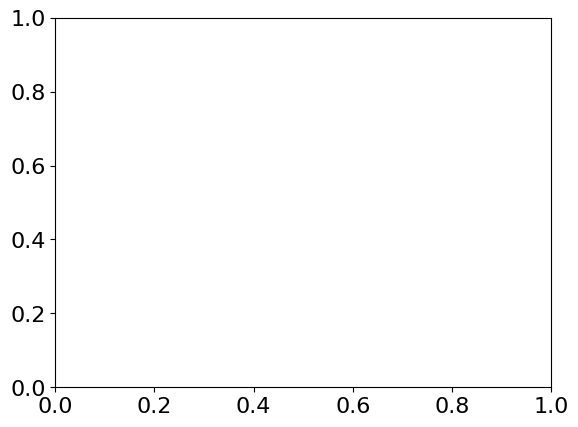

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :60.88721804511278

[0. 0. 1.]


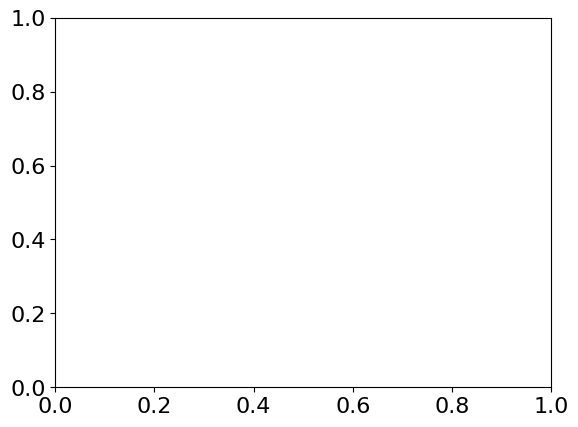

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :60.441102756892235

[0. 0. 1.]


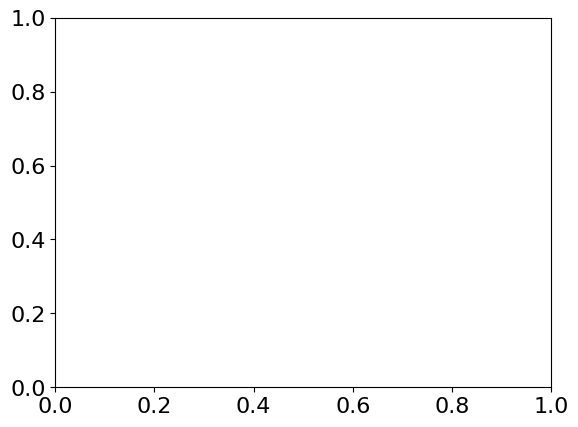

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :59.99498746867168

[0. 0. 1.]


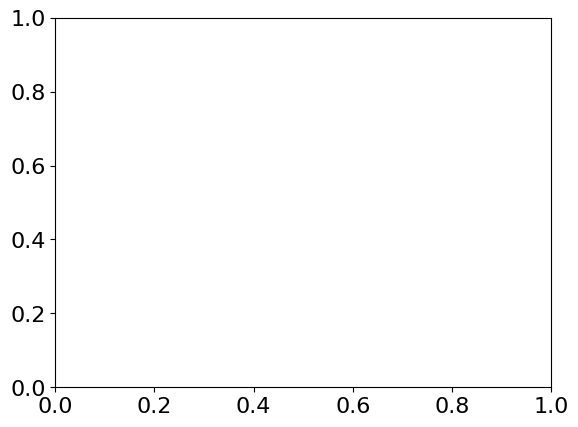

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :59.54887218045113

[0. 0. 1.]


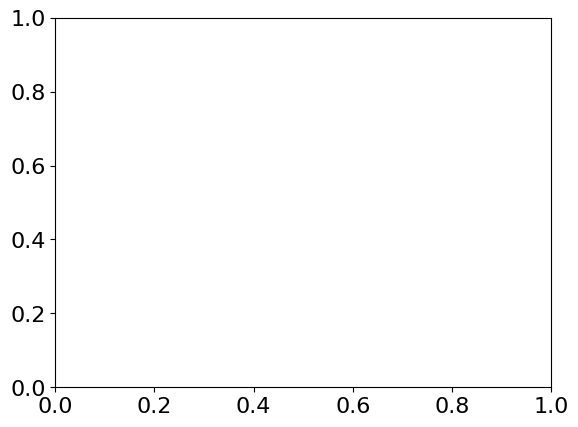

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :59.10275689223058

[0. 0. 1.]


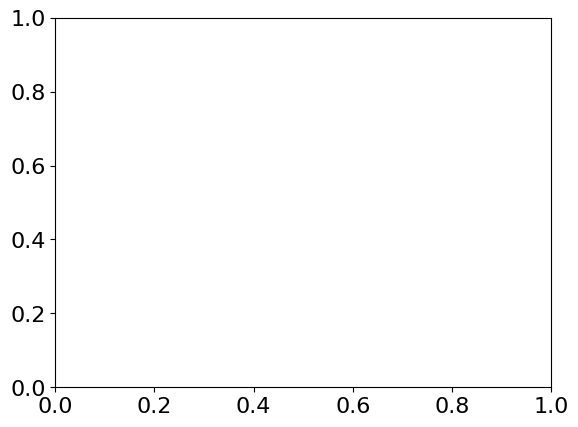

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :58.65664160401002

[0. 0. 1.]


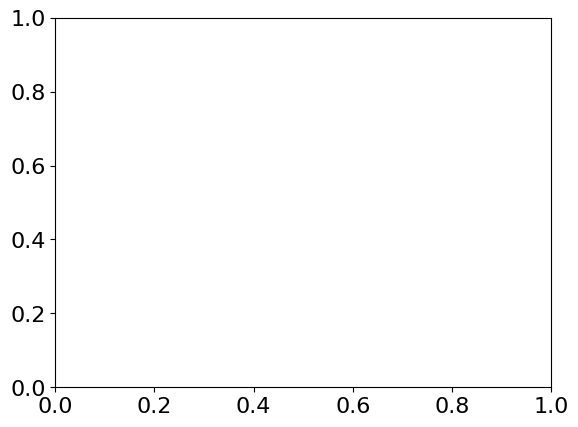

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :58.21052631578947

[0. 0. 1.]


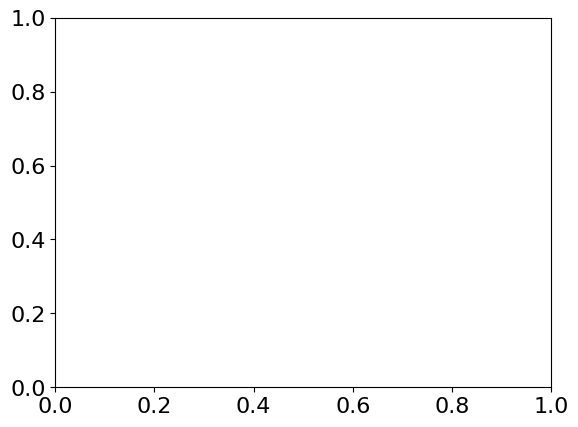

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :57.764411027568926

[0. 0. 1.]


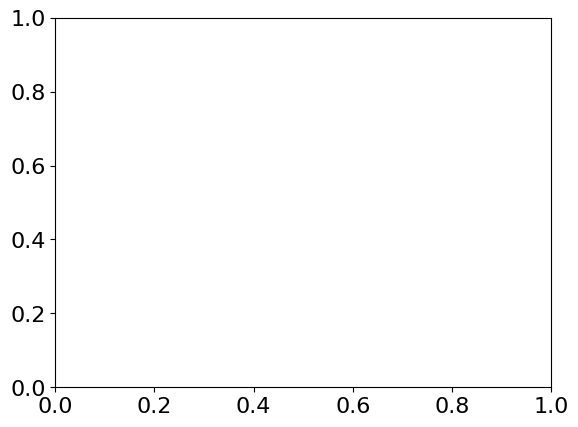

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :57.31829573934837

[0. 0. 1.]


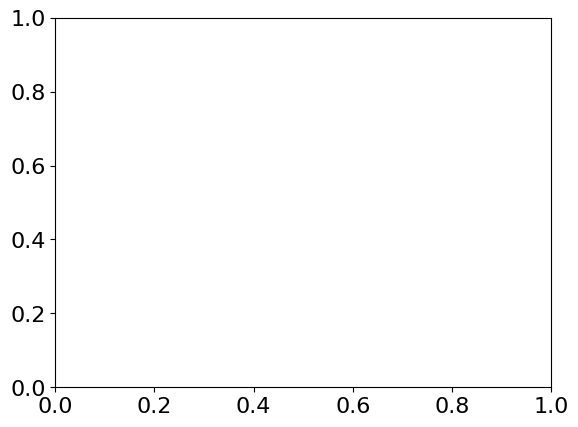

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :56.872180451127825

[0. 0. 1.]


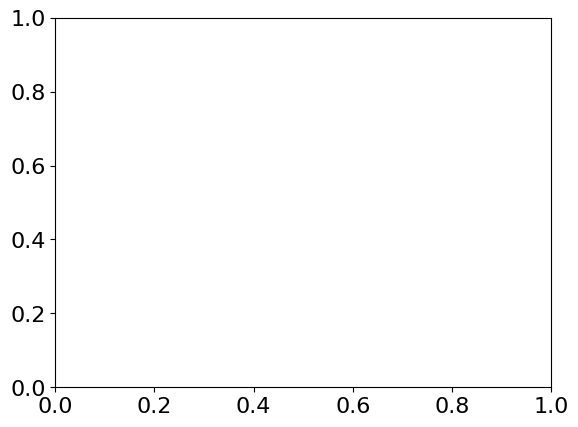

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :56.42606516290727

[0. 0. 1.]


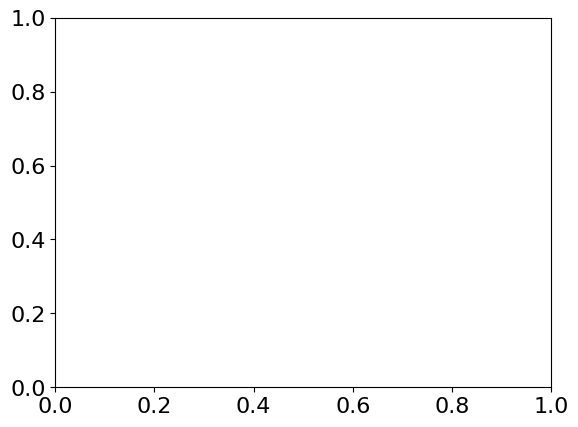

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :55.979949874686724

[0. 0. 1.]


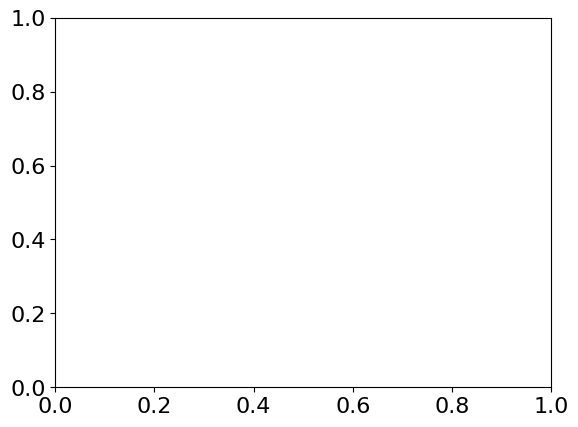

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :55.53383458646617

[0. 0. 1.]


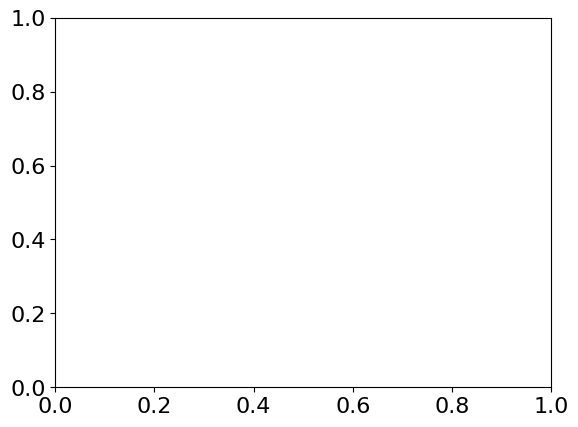

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :55.08771929824561

[0. 0. 1.]


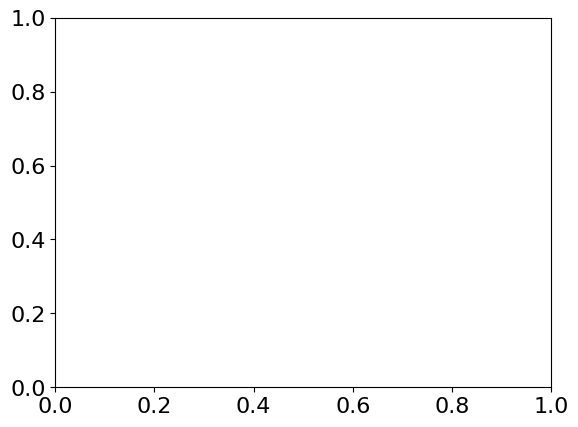

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :54.64160401002506

[0. 0. 1.]


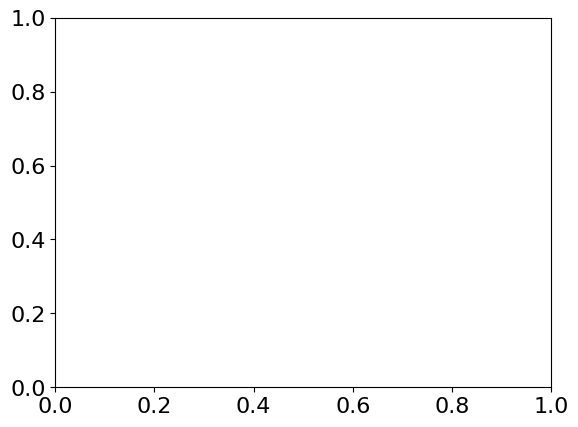

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :54.195488721804516

[0. 0. 1.]


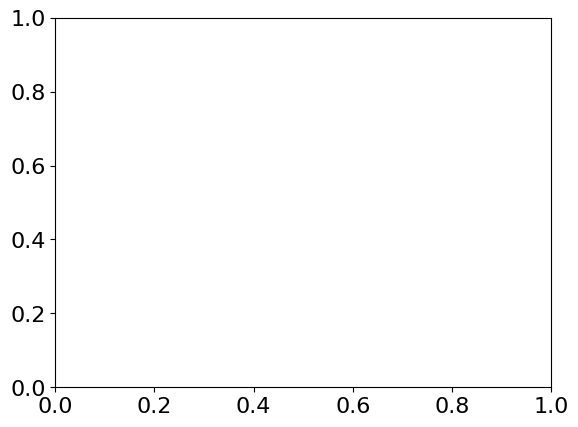

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :53.74937343358396

[0. 0. 1.]


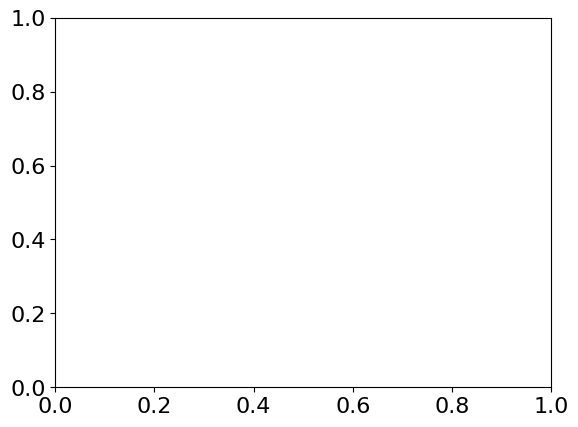

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :53.303258145363415

[0. 0. 1.]


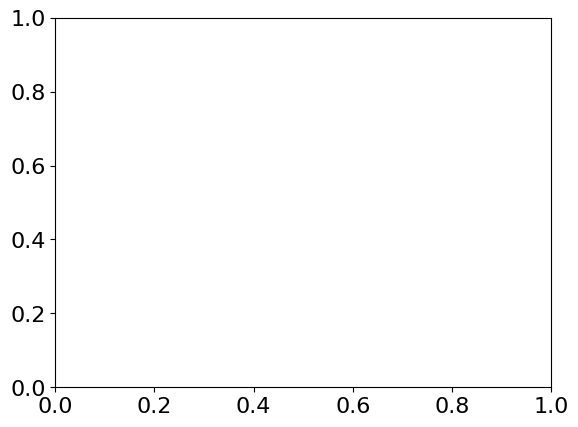

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :52.85714285714286

[0. 0. 1.]


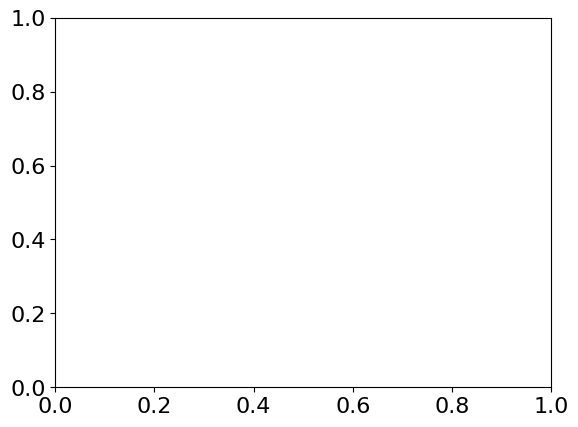

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :52.41102756892231

[0. 0. 1.]


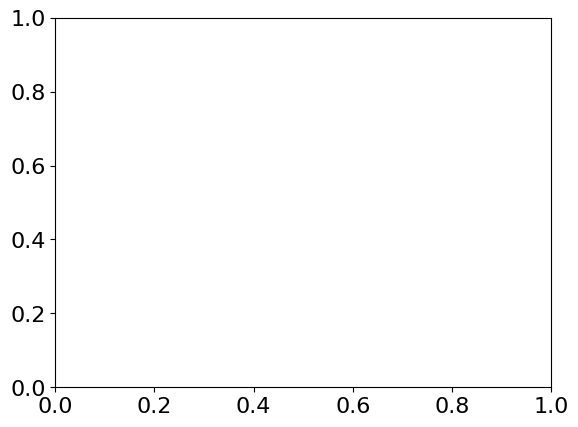

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :51.96491228070176

[0. 0. 1.]


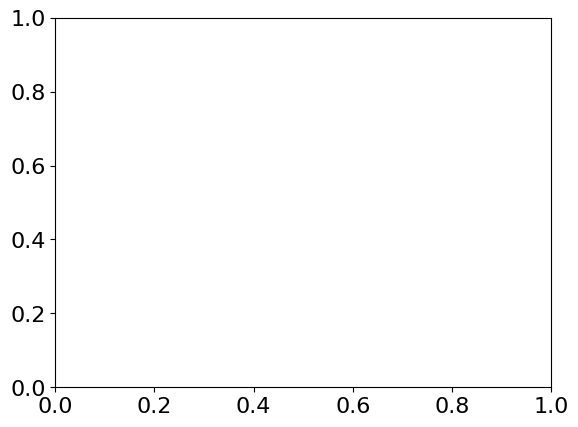

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :51.518796992481214

[0. 0. 1.]


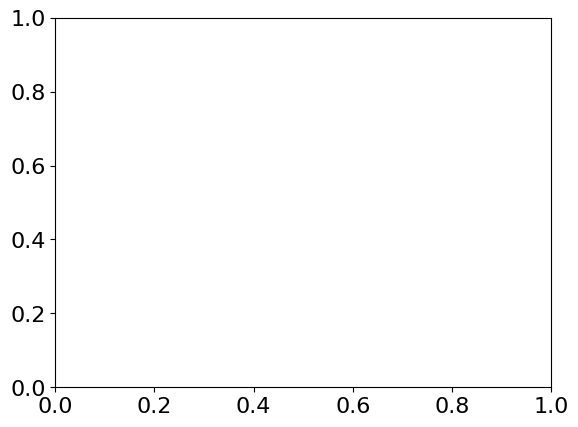

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :51.07268170426065

[0. 0. 1.]


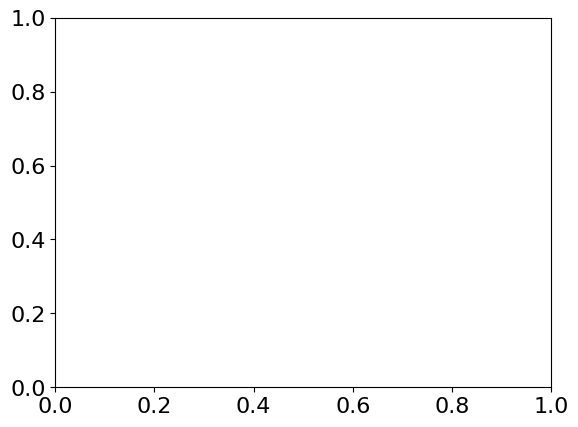

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :50.626566416040106

[0. 0. 1.]


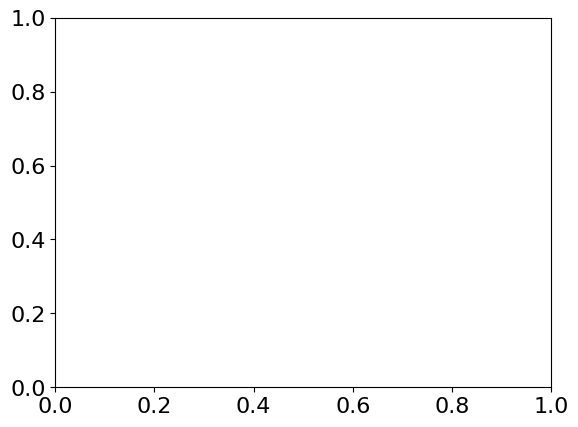

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :50.18045112781955

[0. 0. 1.]


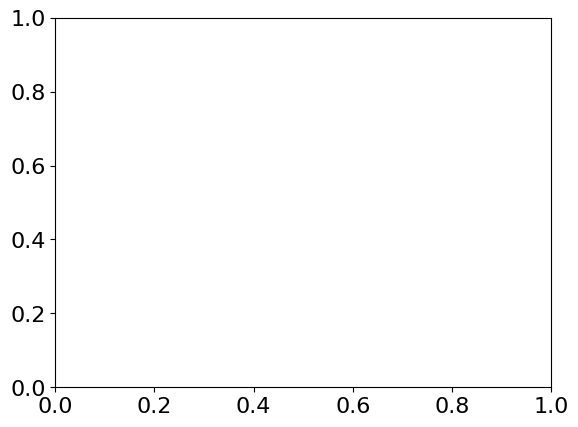

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :49.734335839599005

[0. 0. 1.]


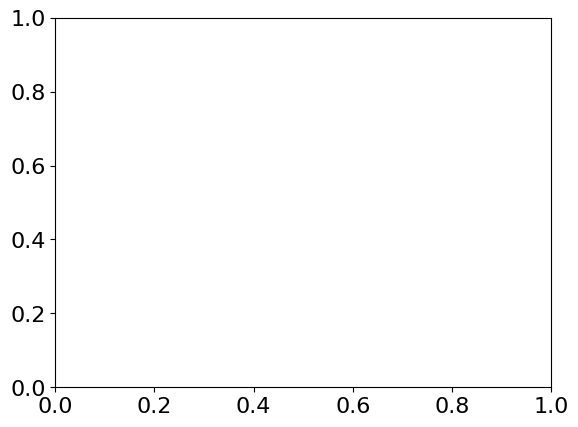

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :49.28822055137845

[0. 0. 1.]


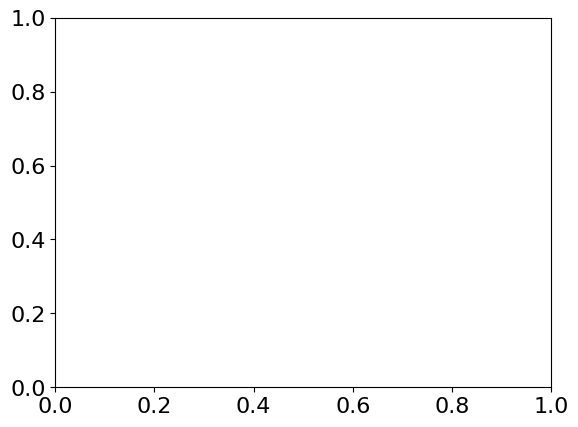

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :48.8421052631579

[0. 0. 1.]


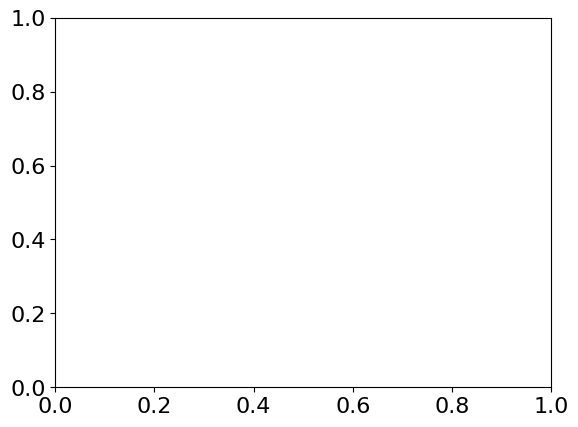

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :48.39598997493735

[0. 0. 1.]


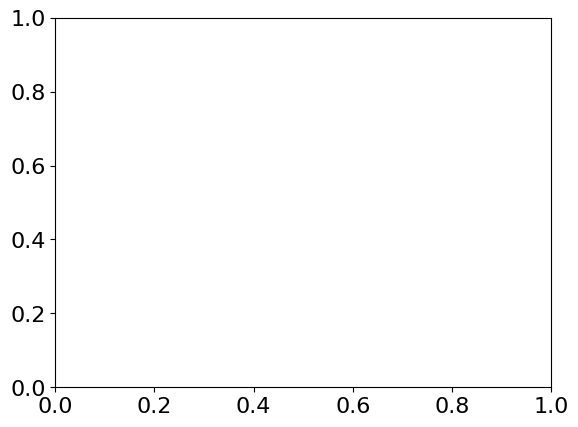

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :47.949874686716804

[0. 0. 1.]


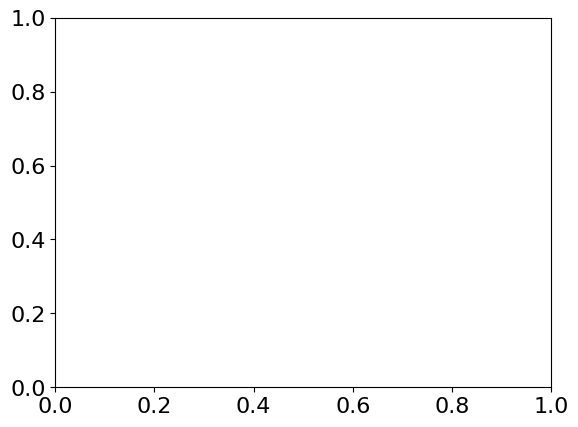

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :47.50375939849624

[0. 0. 1.]


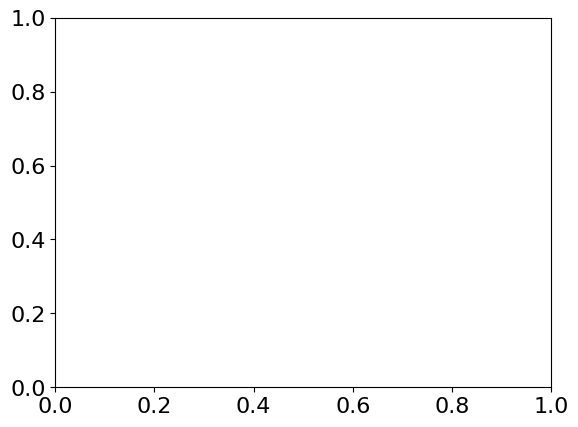

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :47.05764411027569

[0. 0. 1.]


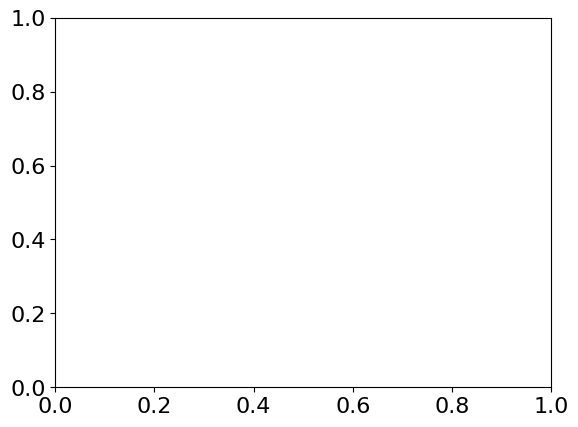

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :46.61152882205514

[0. 0. 1.]


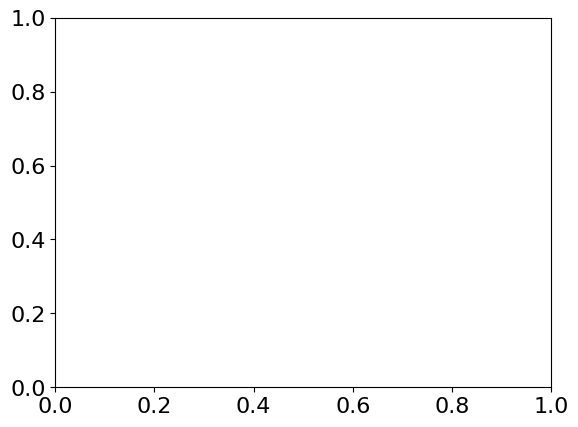

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :46.165413533834595

[0. 0. 1.]


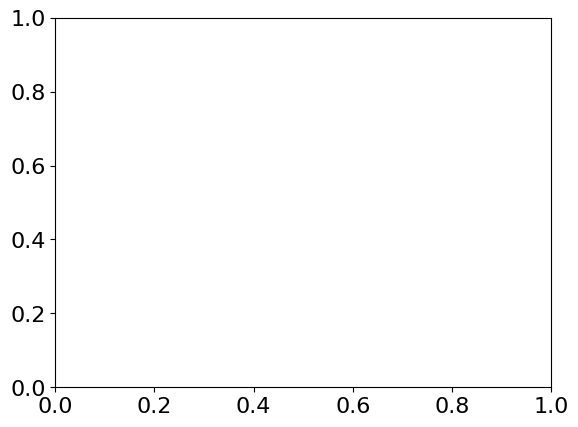

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :45.719298245614034

[0. 0. 1.]


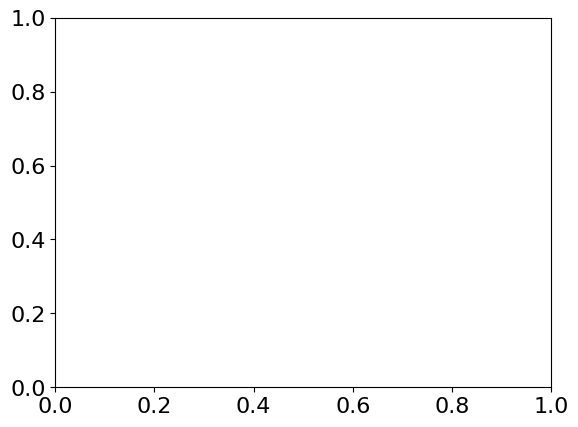

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :45.27318295739349

[0. 0. 1.]


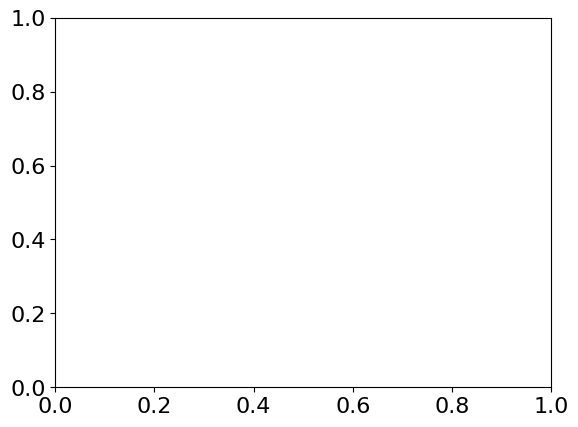

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :44.82706766917293

[0. 0. 1.]


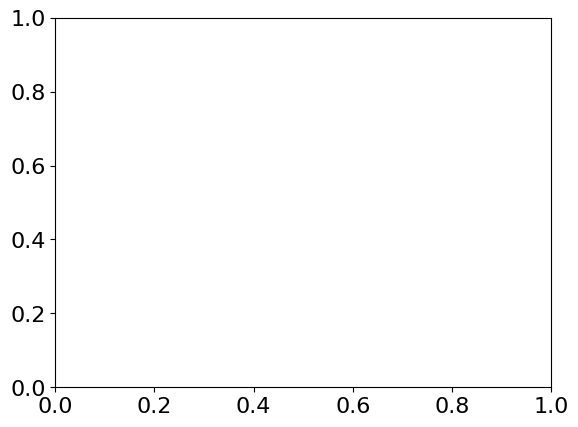

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :44.38095238095238

[0. 0. 1.]


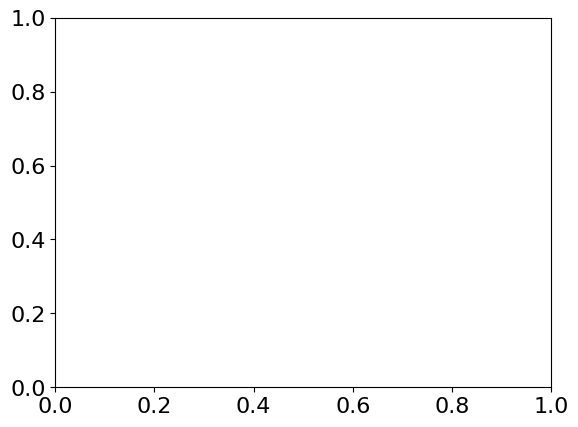

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :43.93483709273183

[0. 0. 1.]


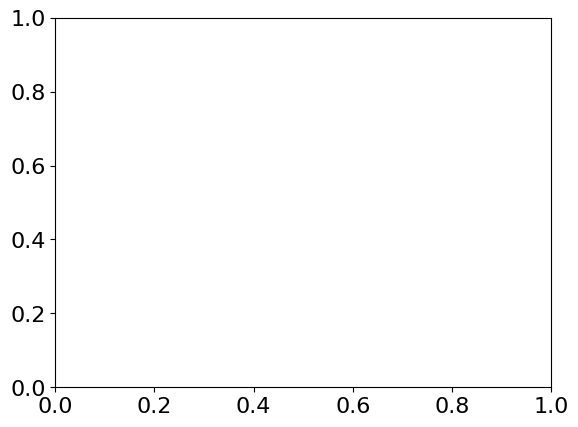

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :43.48872180451128

[0. 0. 1.]


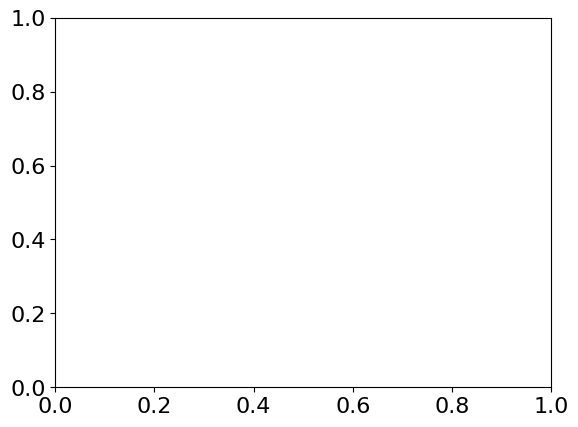

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :43.04260651629073

[0. 0. 1.]


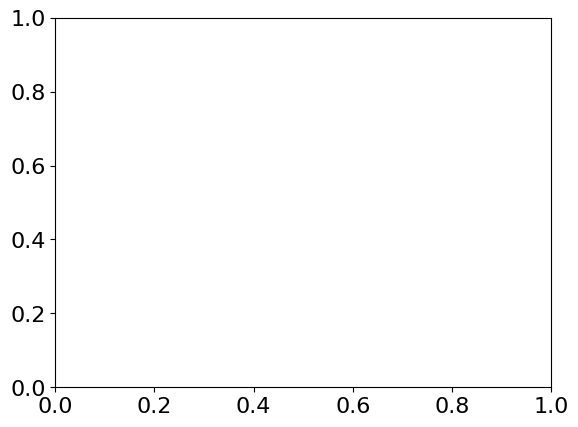

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :42.596491228070185

[0. 0. 1.]


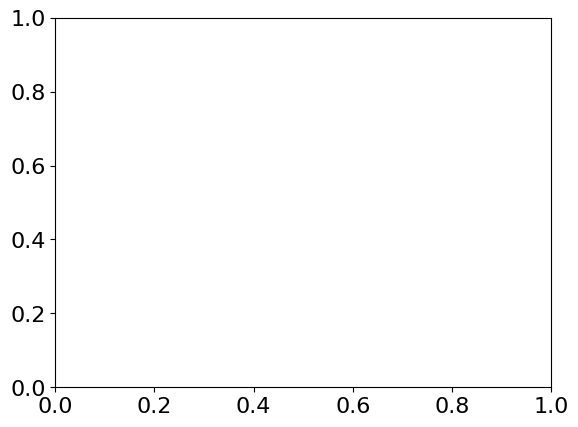

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :42.150375939849624

[0. 0. 1.]


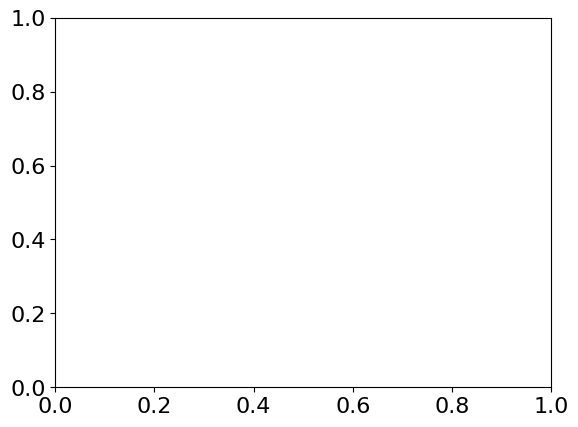

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :41.70426065162908

[0. 0. 1.]


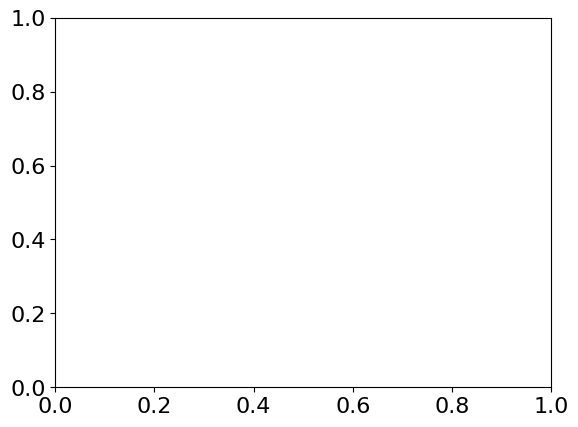

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :41.25814536340853

[0. 0. 1.]


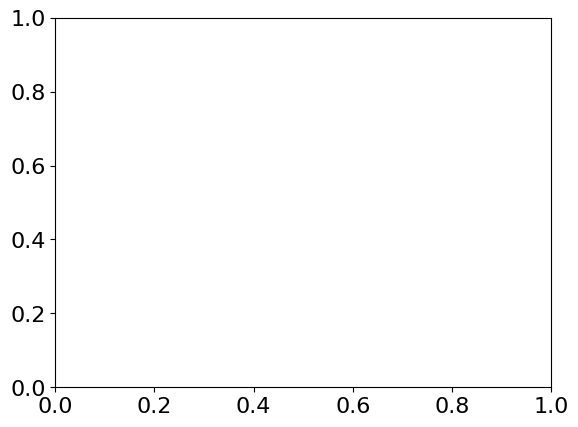

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :40.81203007518797

[0. 0. 1.]


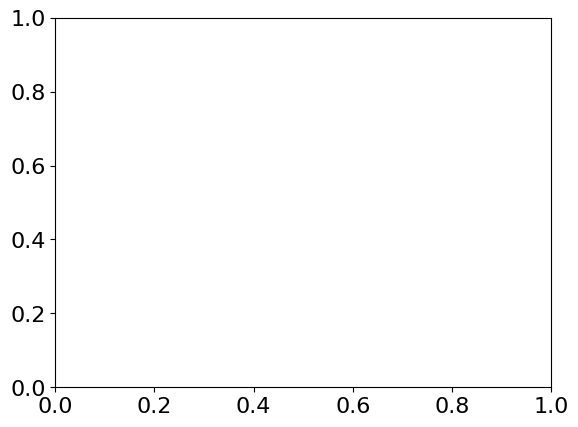

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :40.36591478696742

[0. 0. 1.]


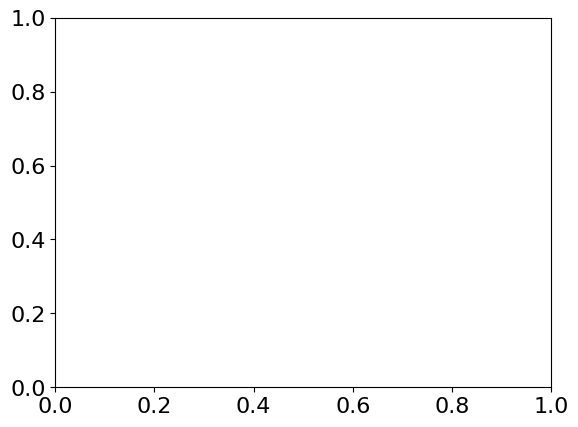

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :39.91979949874687

[0. 0. 1.]


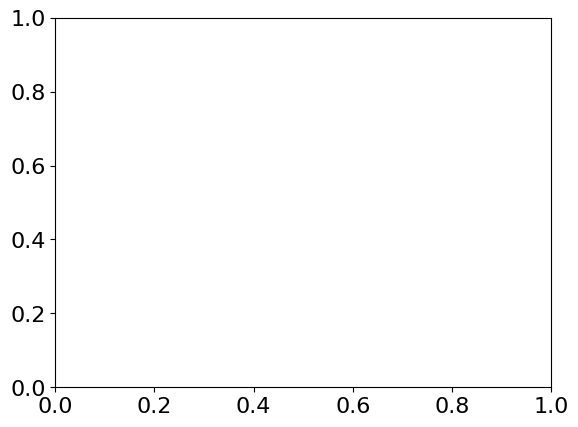

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :39.47368421052632

[0. 0. 1.]


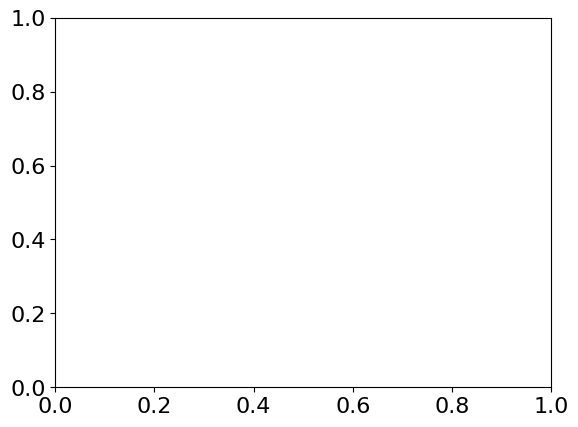

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :39.02756892230577

[0. 0. 1.]


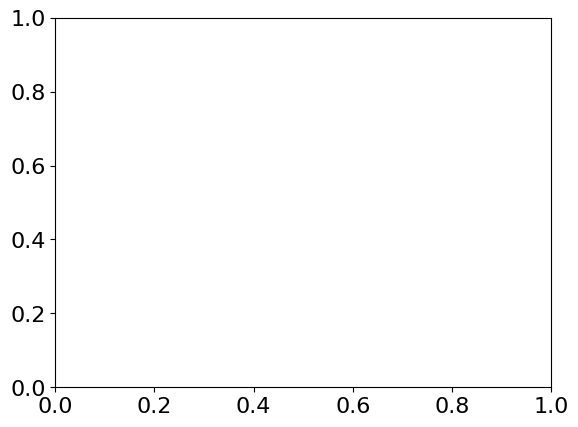

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :38.581453634085214

[0. 0. 1.]


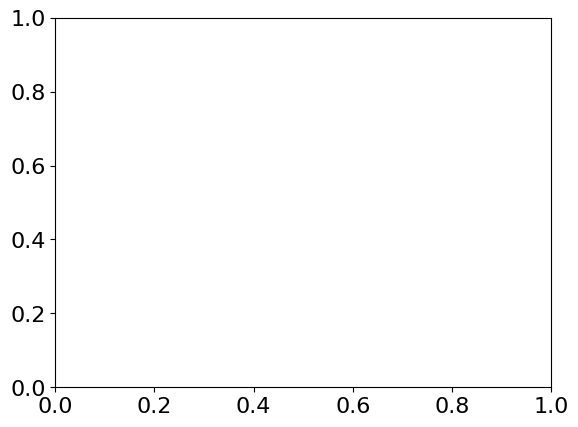

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :38.13533834586466

[0. 0. 1.]


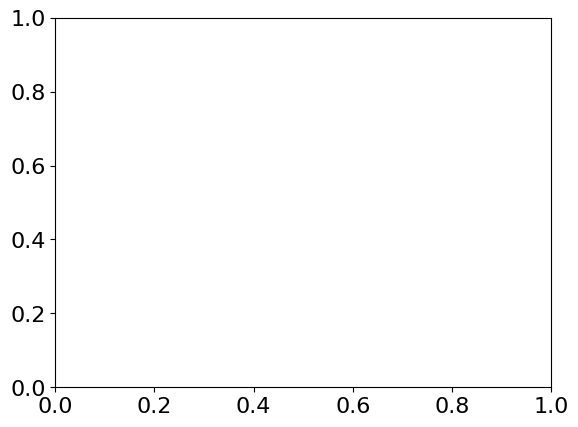

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :37.689223057644114

[0. 0. 1.]


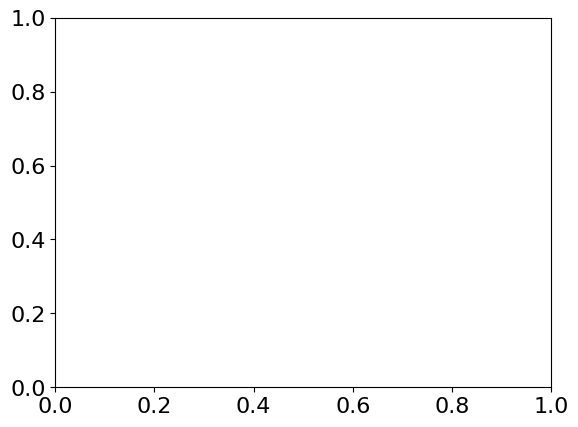

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :37.24310776942356

[0. 0. 1.]


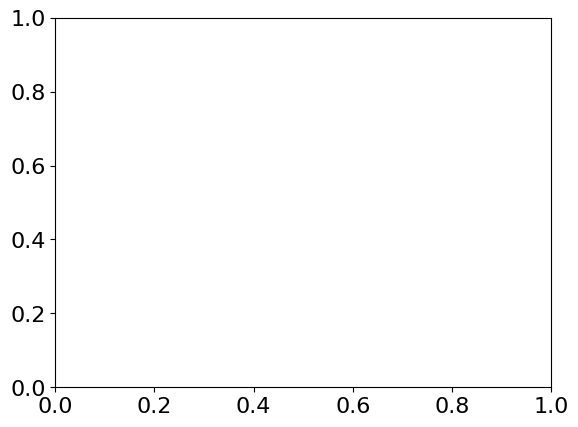

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :36.79699248120301

[0. 0. 1.]


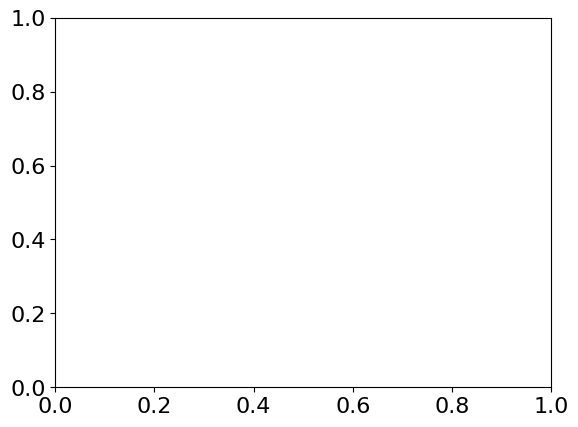

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :36.35087719298246

[0. 0. 1.]


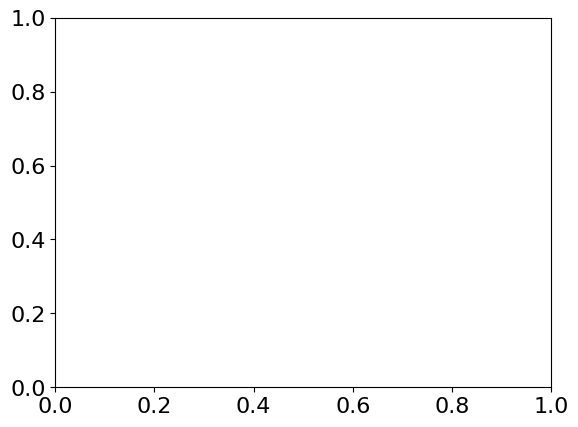

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :35.90476190476191

[0. 0. 1.]


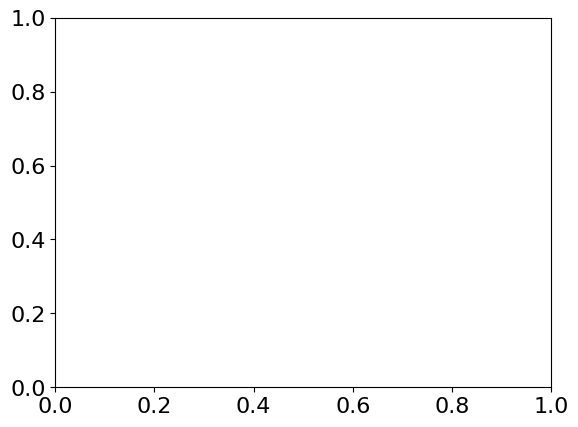

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :35.45864661654136

[0. 0. 1.]


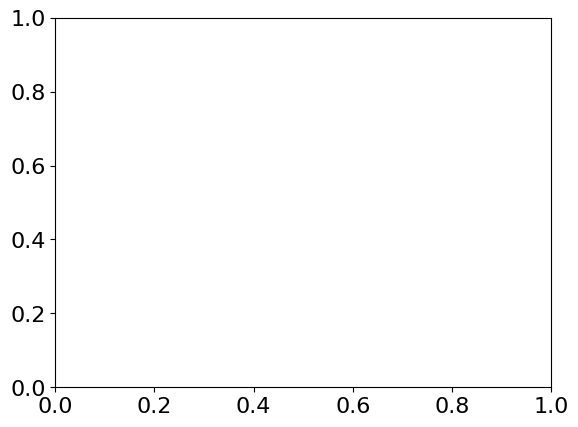

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :35.012531328320804

[0. 0. 1.]


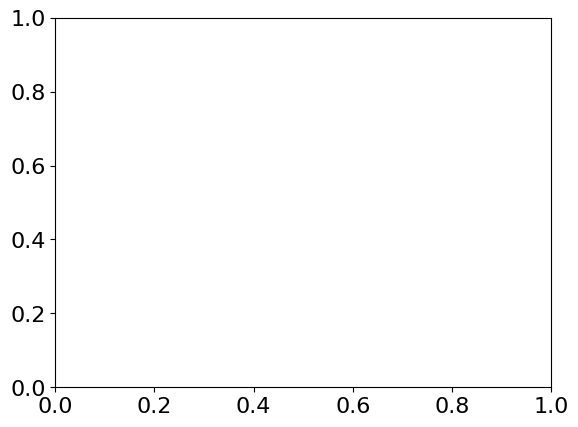

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :34.56641604010026

[0. 0. 1.]


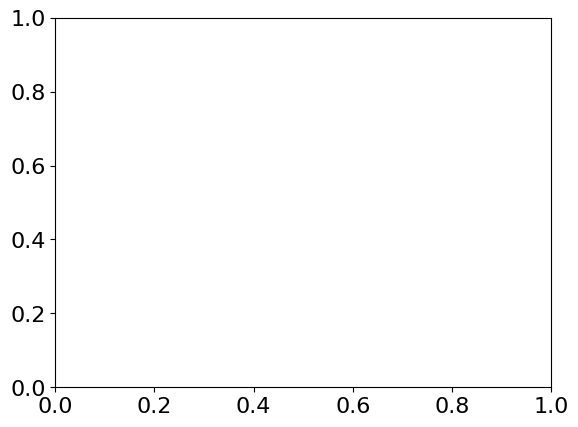

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :34.120300751879704

[0. 0. 1.]


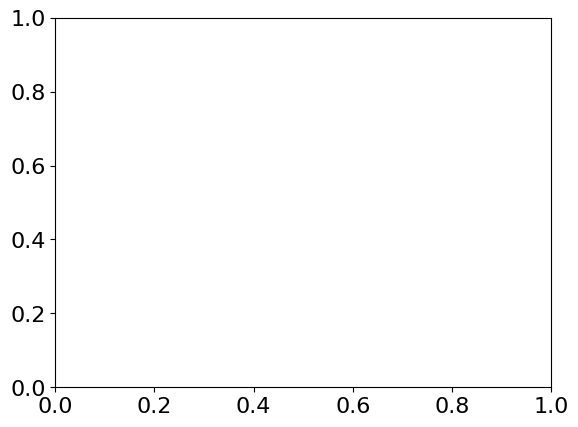

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :33.67418546365915

[0. 0. 1.]


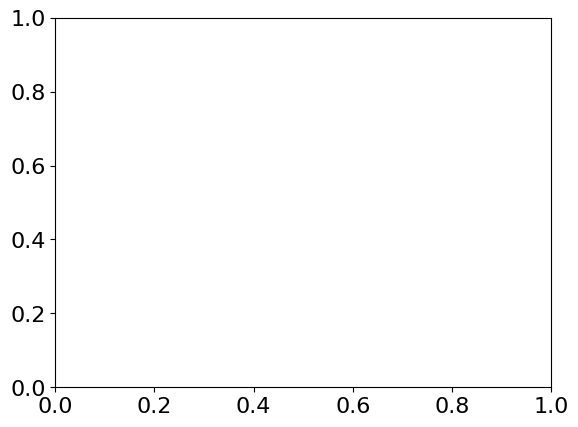

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :33.228070175438596

[0. 0. 1.]


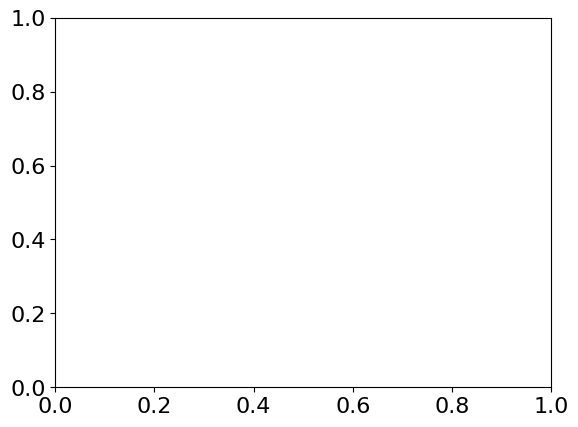

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :32.78195488721805

[0. 0. 1.]


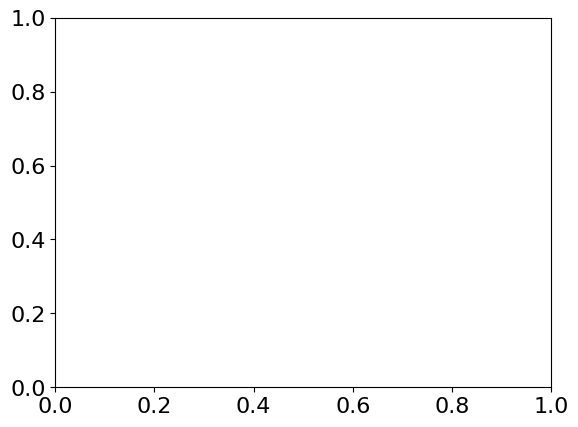

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :32.335839598997495

[0. 0. 1.]


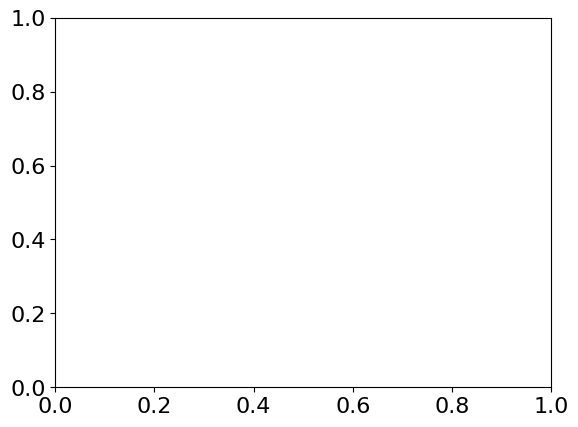

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :31.889724310776945

[0. 0. 1.]


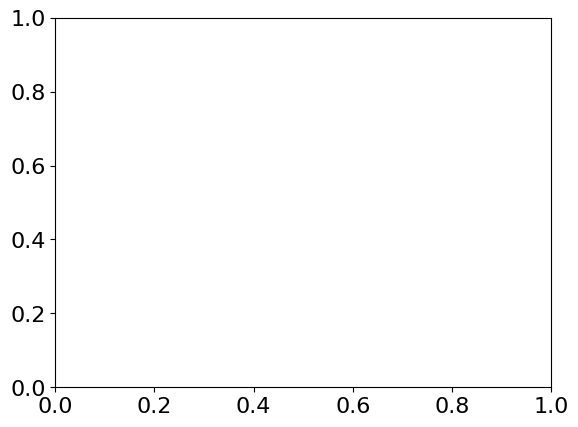

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :31.44360902255639

[0. 0. 1.]


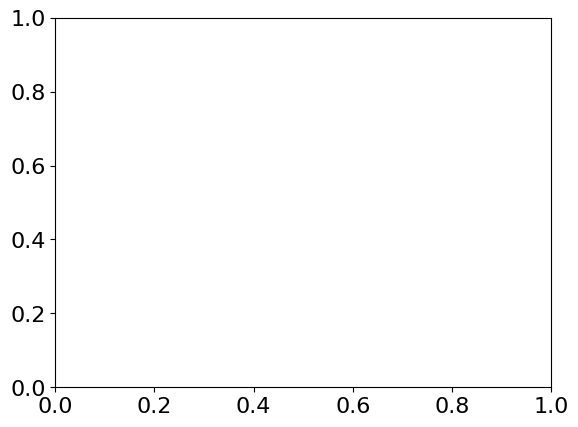

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :30.997493734335844

[0. 0. 1.]


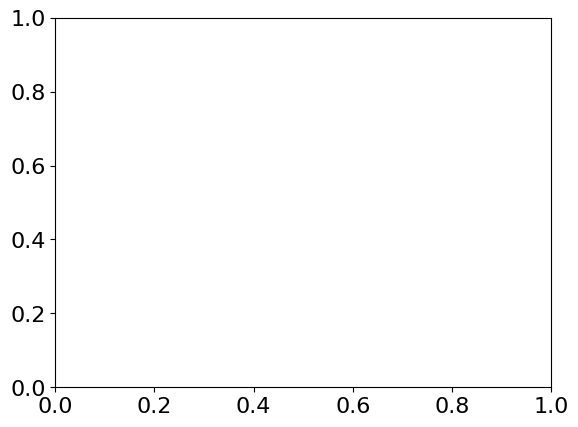

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :30.55137844611529

[0. 0. 1.]


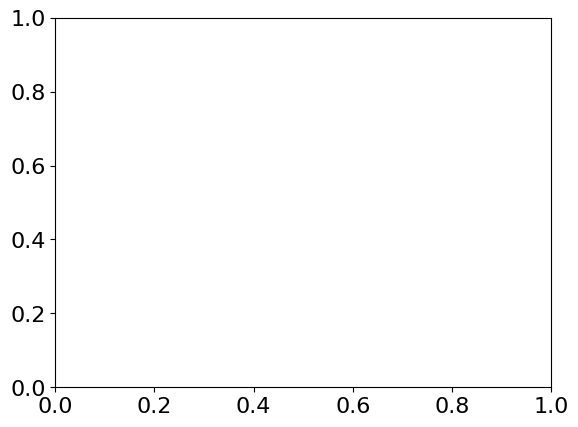

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :30.10526315789474

[0. 0. 1.]


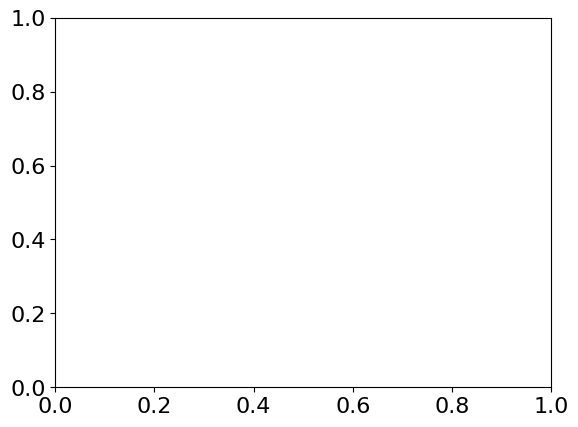

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :29.659147869674186

[0. 0. 1.]


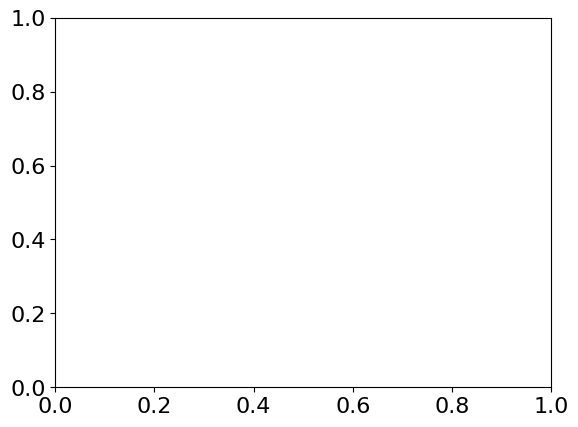

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :29.21303258145364

[0. 0. 1.]


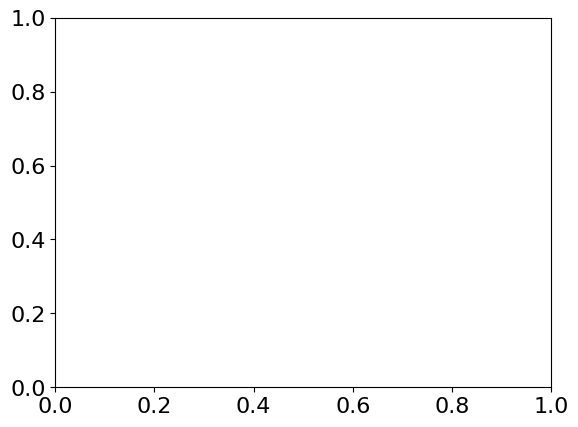

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :28.766917293233085

[0. 0. 1.]


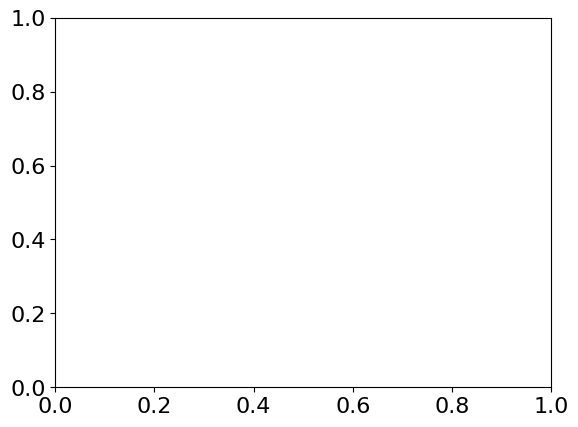

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :28.320802005012535

[0. 0. 1.]


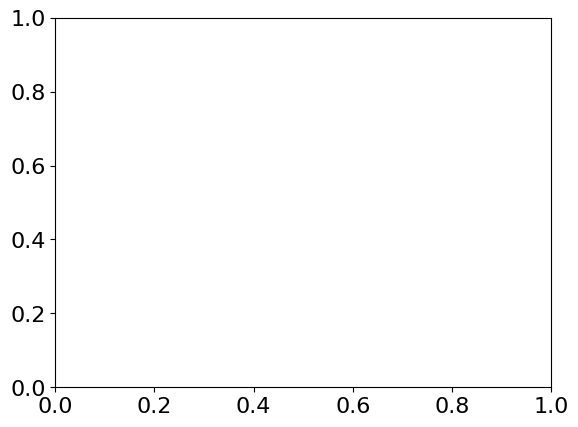

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :27.87468671679198

[0. 0. 1.]


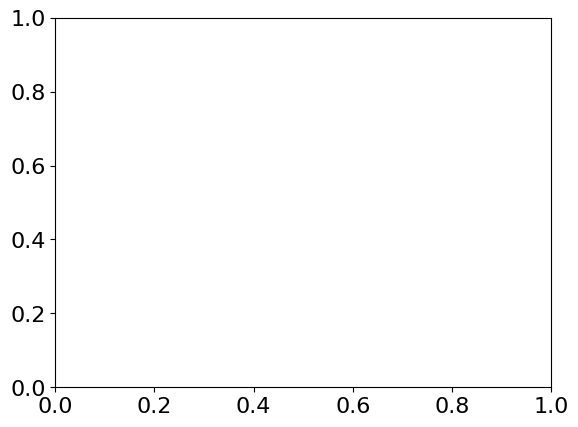

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :27.428571428571427

[0. 0. 1.]


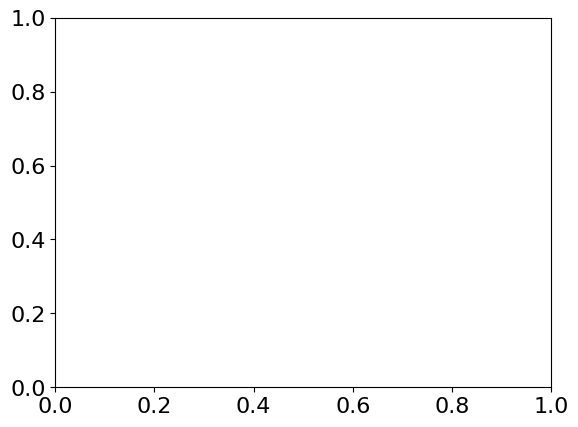

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :26.982456140350877

[0. 0. 1.]


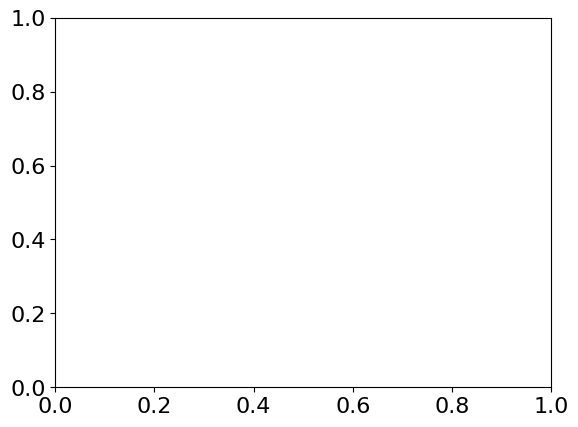

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :26.53634085213033

[0. 0. 1.]


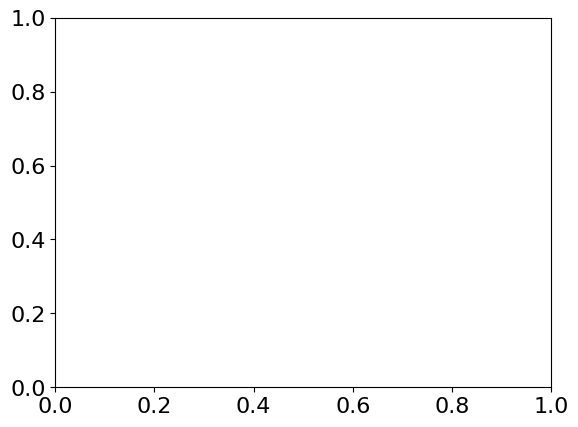

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :26.090225563909772

[0. 0. 1.]


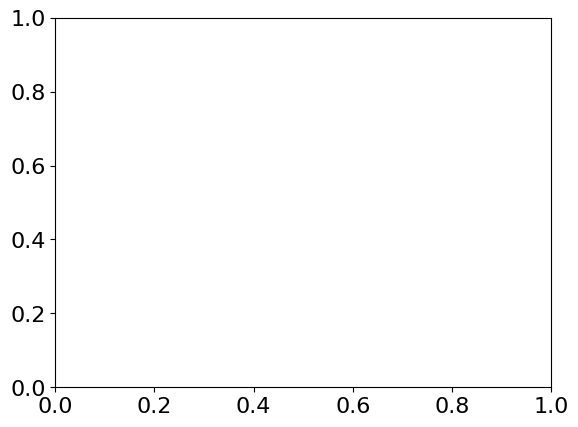

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :25.644110275689222

[0. 0. 1.]


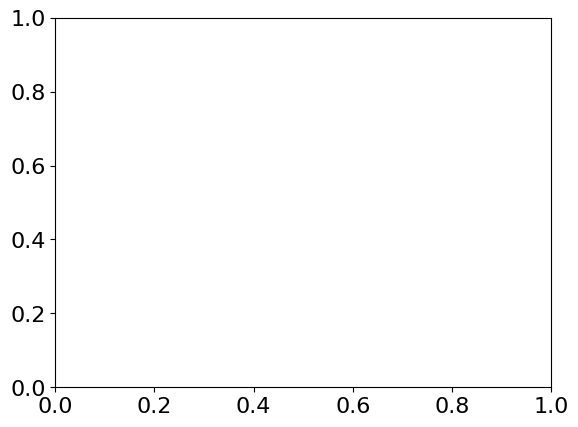

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :25.19799498746867

[0. 0. 1.]


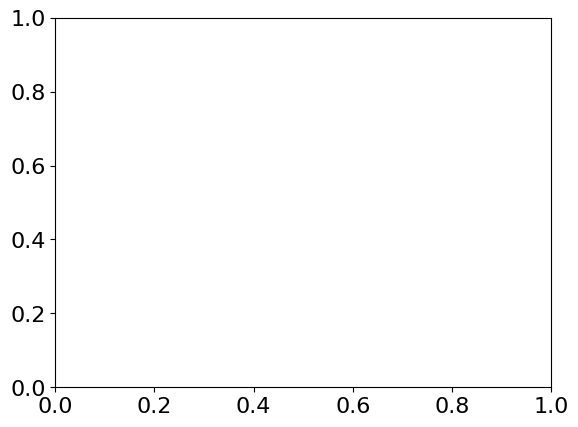

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :24.751879699248118

[0. 0. 1.]


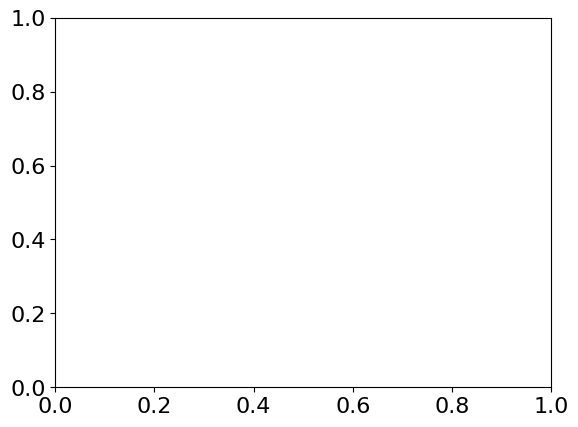

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :24.305764411027567

[0. 0. 1.]


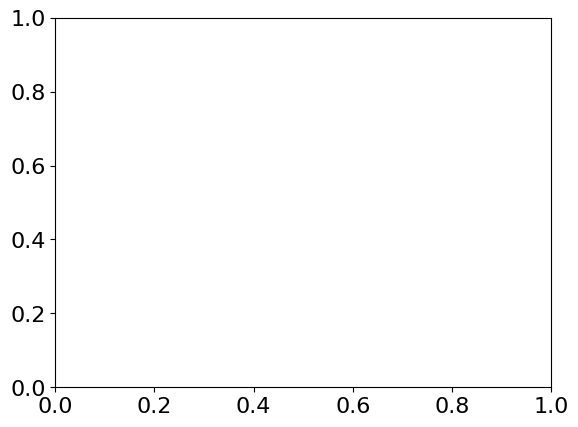

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :23.859649122807017

[0. 0. 1.]


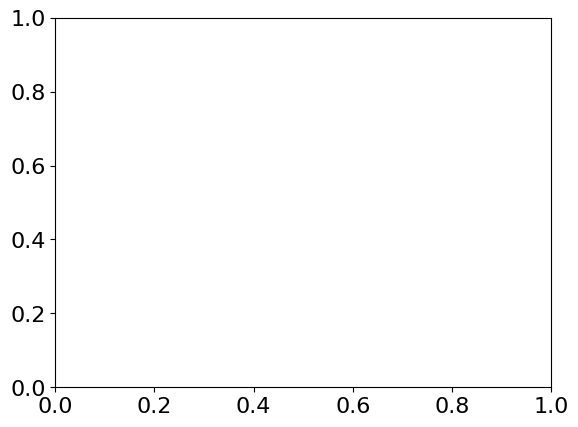

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :23.413533834586467

[0. 0. 1.]


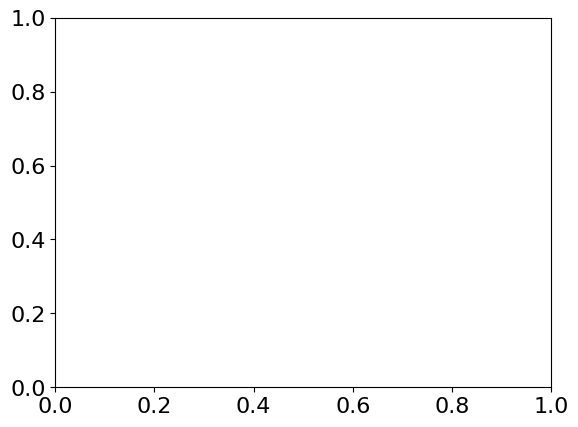

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :22.967418546365913

[0. 0. 1.]


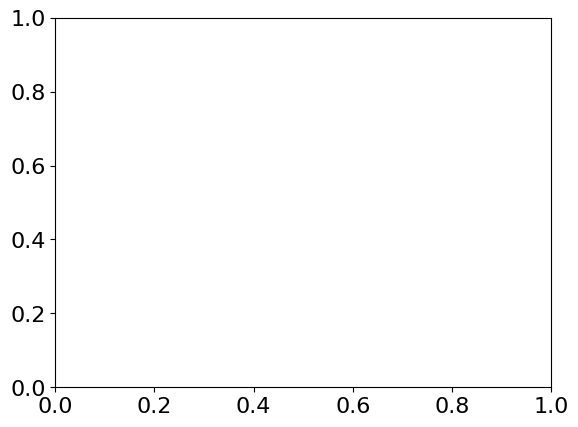

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :22.521303258145366

[0. 0. 1.]


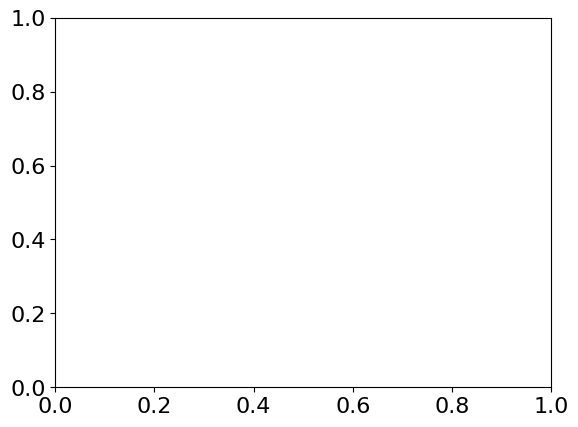

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :22.075187969924812

[0. 0. 1.]


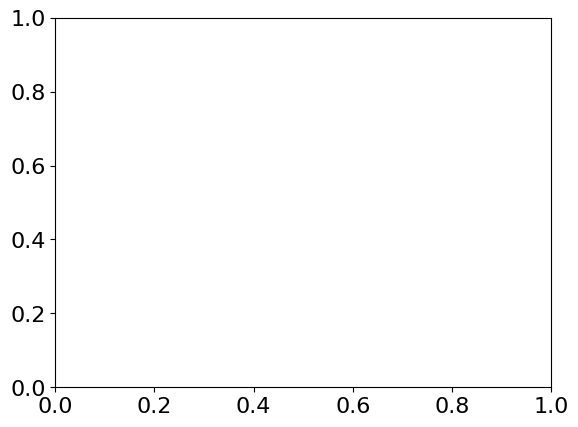

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :21.629072681704262

[0. 0. 1.]


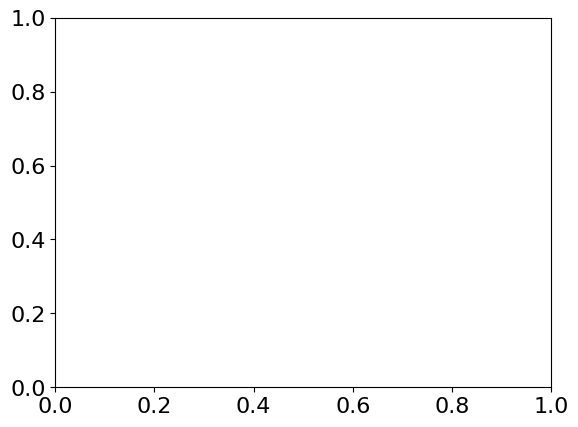

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :21.182957393483708

[0. 0. 1.]


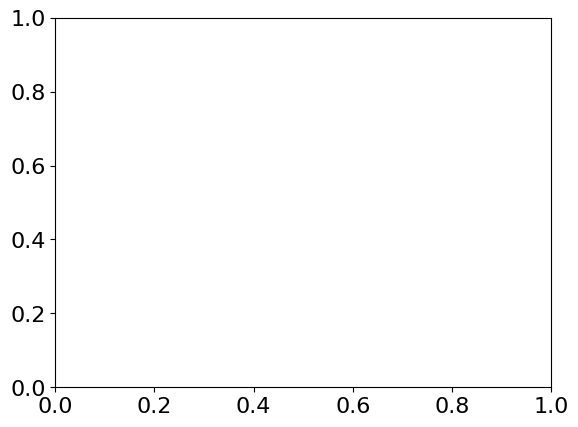

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :20.73684210526316

[0. 0. 1.]


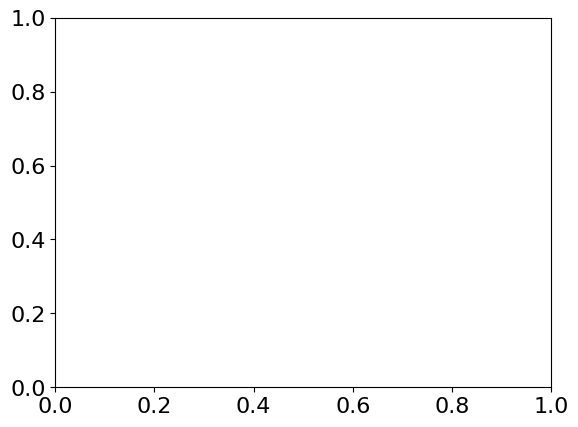

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :20.290726817042607

[0. 0. 1.]


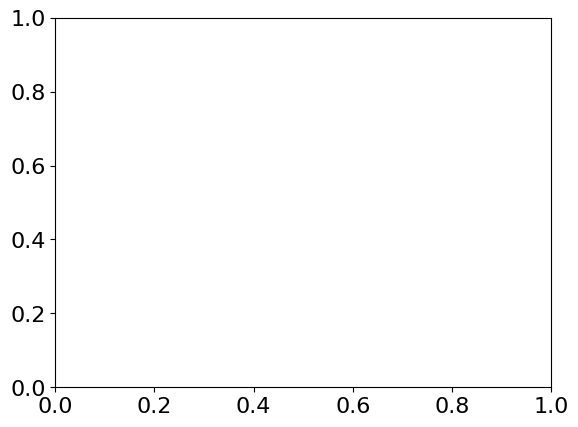

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :19.844611528822057

[0. 0. 1.]


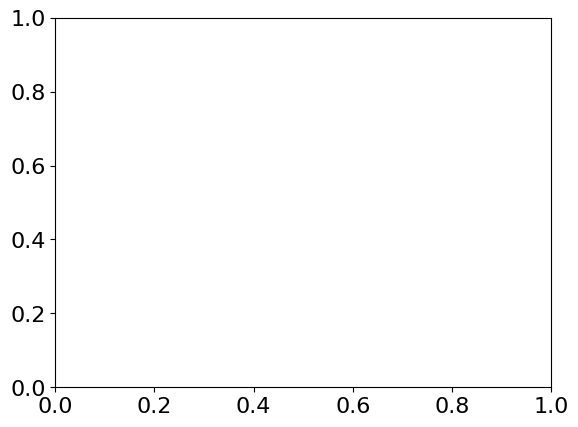

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :19.398496240601503

[0. 0. 1.]


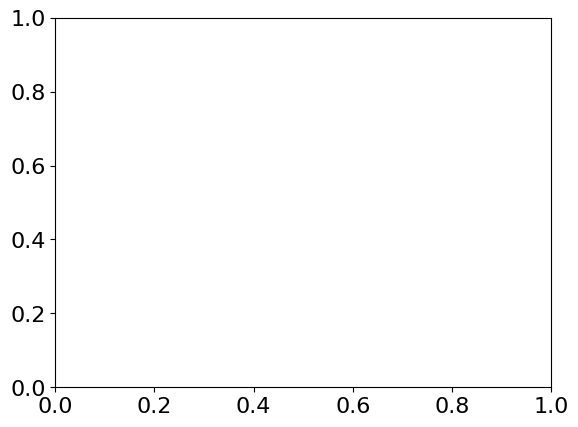

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :18.952380952380953

[0. 0. 1.]


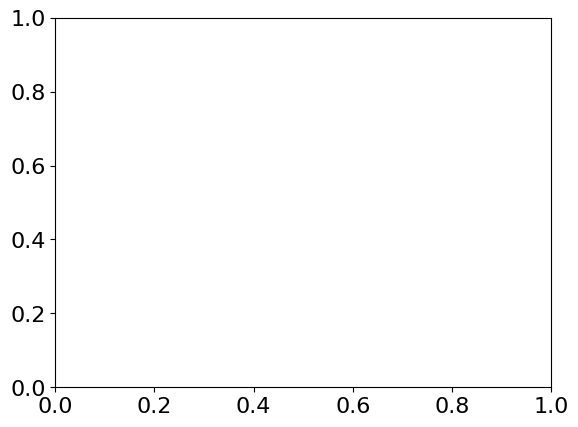

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :18.5062656641604

[0. 0. 1.]


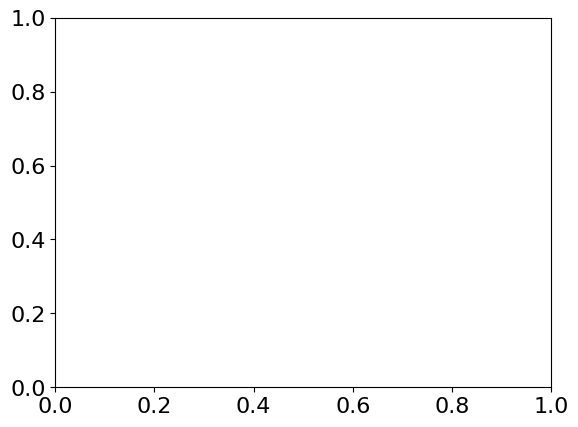

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :18.06015037593985

[0. 0. 1.]


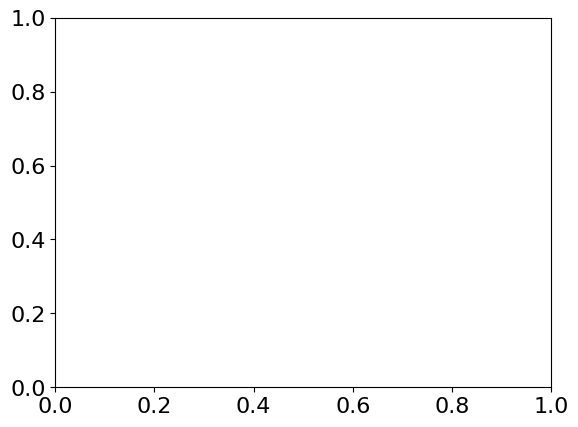

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :17.614035087719298

[0. 0. 1.]


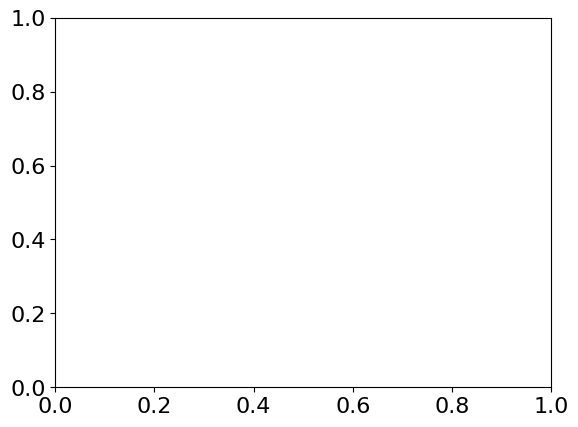

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :17.167919799498748

[0. 0. 1.]


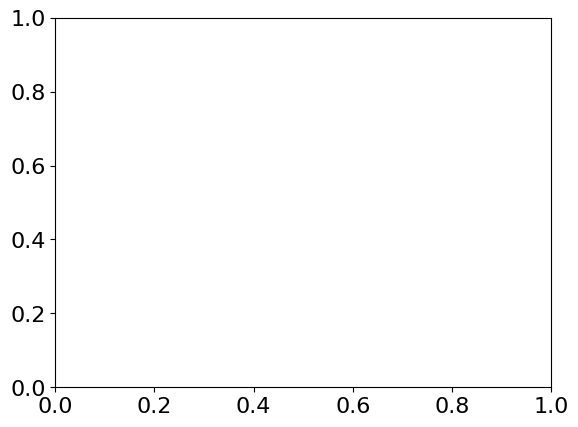

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :16.721804511278194

[0. 0. 1.]


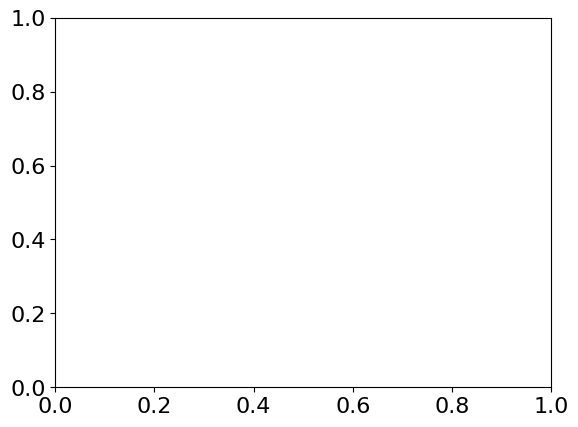

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :16.275689223057643

[0. 0. 1.]


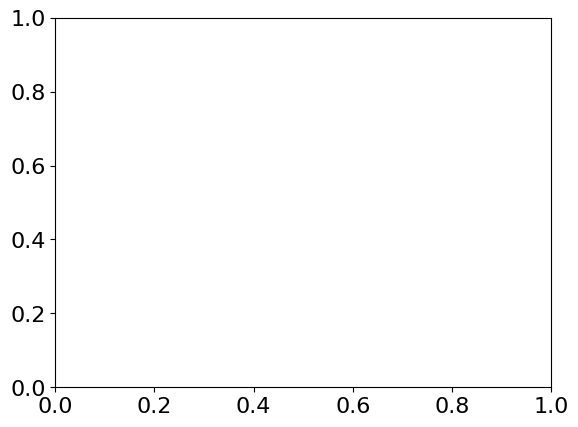

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :15.829573934837095

[0. 0. 1.]


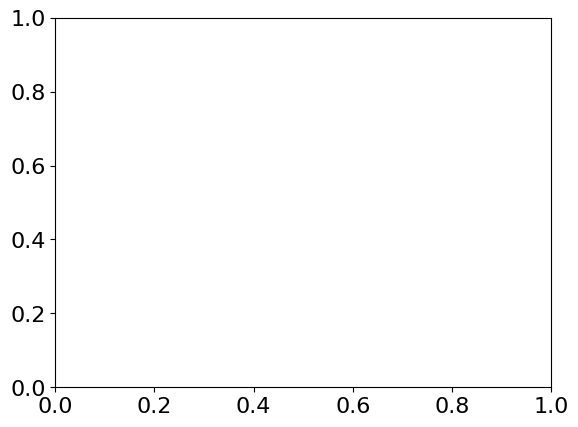

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :15.38345864661654

[0. 0. 1.]


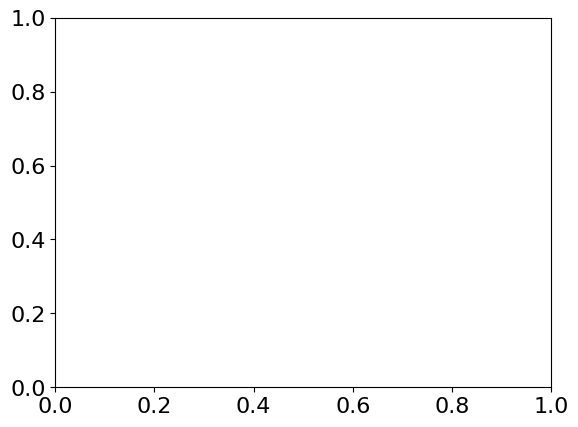

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :14.937343358395992

[0. 0. 1.]


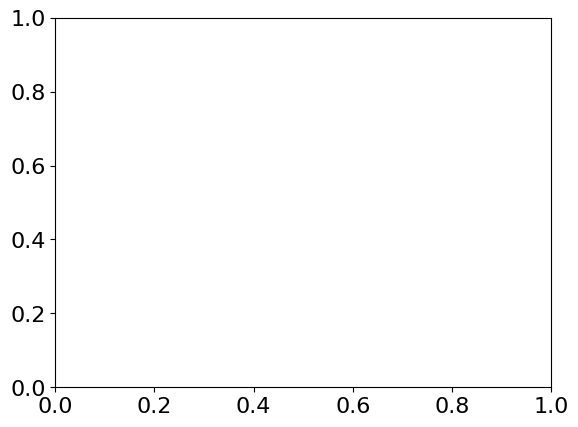

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :14.491228070175437

[0. 0. 1.]


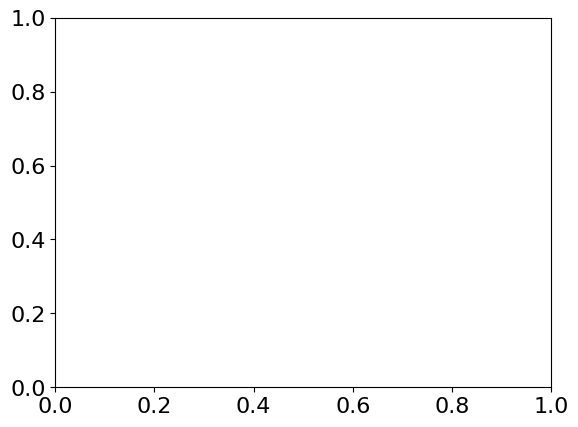

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :14.045112781954886

[0. 0. 1.]


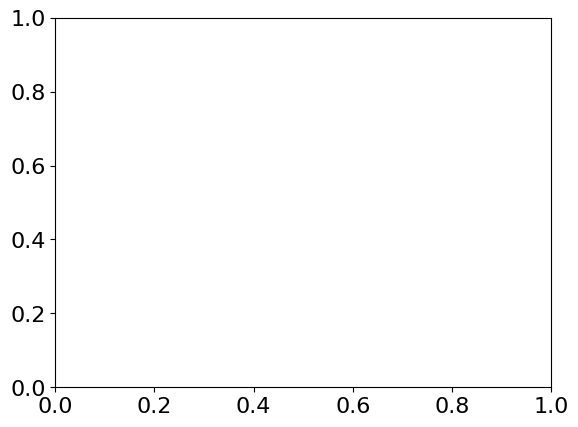

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :13.598997493734334

[0. 0. 1.]


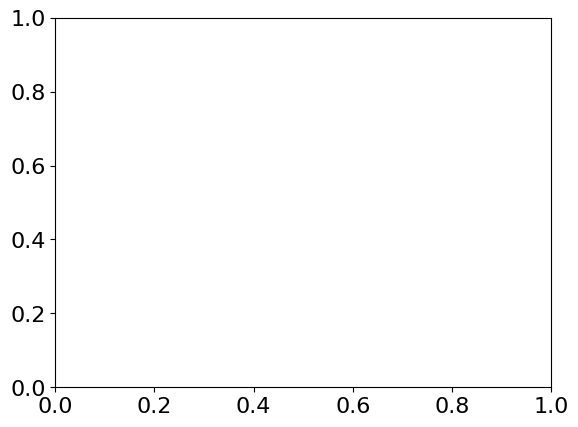

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :13.152882205513784

[0. 0. 1.]


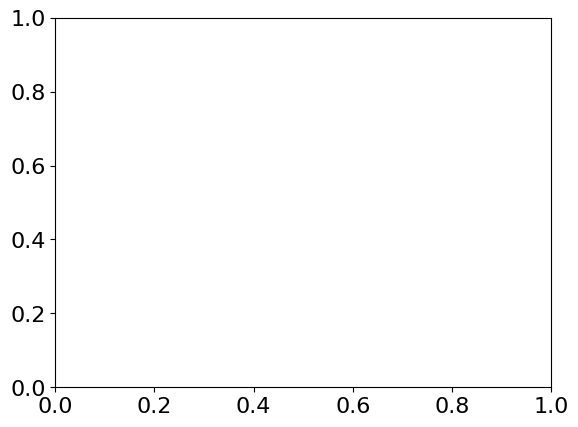

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :12.706766917293232

[0. 0. 1.]


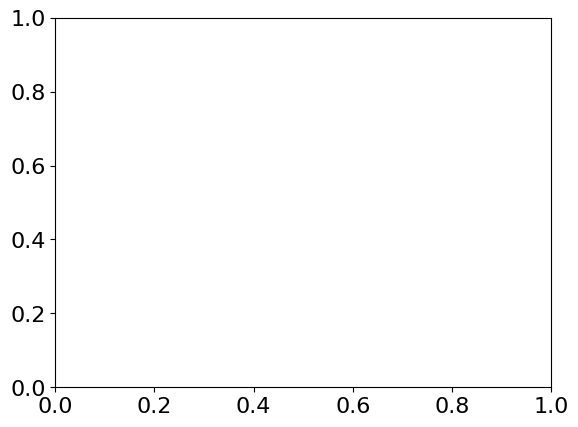

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :12.260651629072681

[0. 0. 1.]


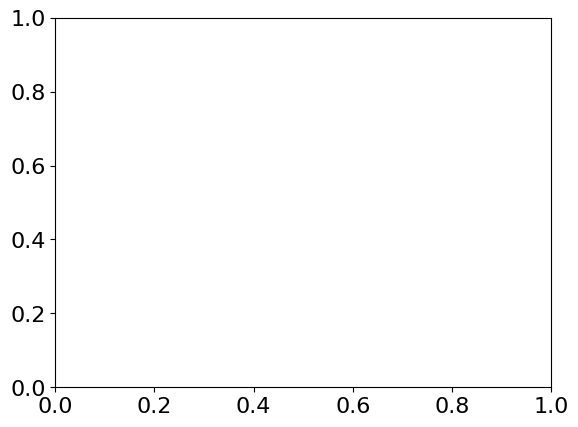

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :11.814536340852133

[0. 0. 1.]


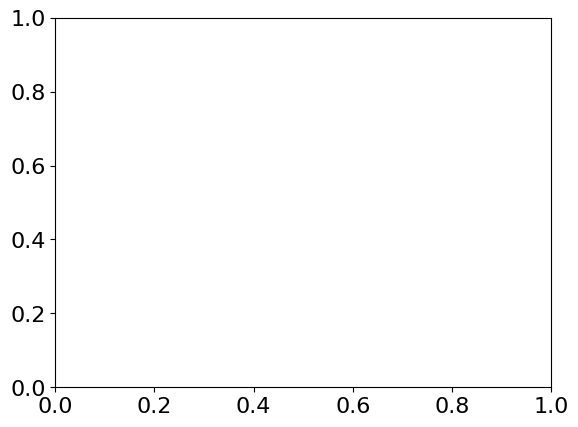

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :11.368421052631579

[0. 0. 1.]


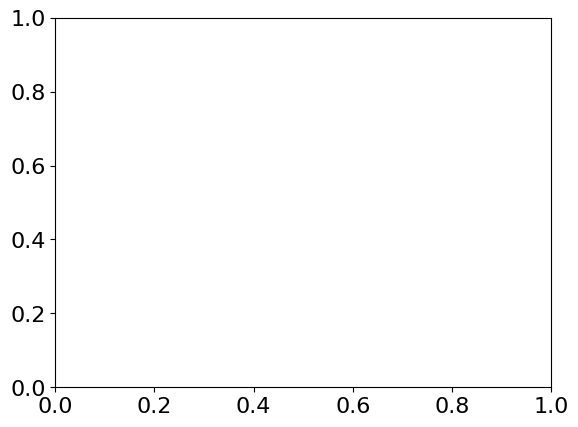

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :10.922305764411027

[0. 0. 1.]


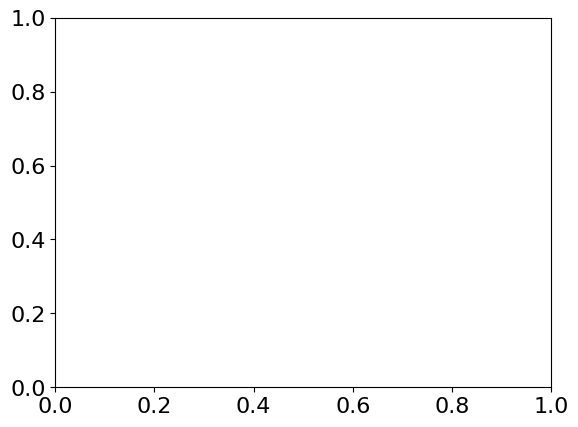

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :10.476190476190476

[0. 0. 1.]


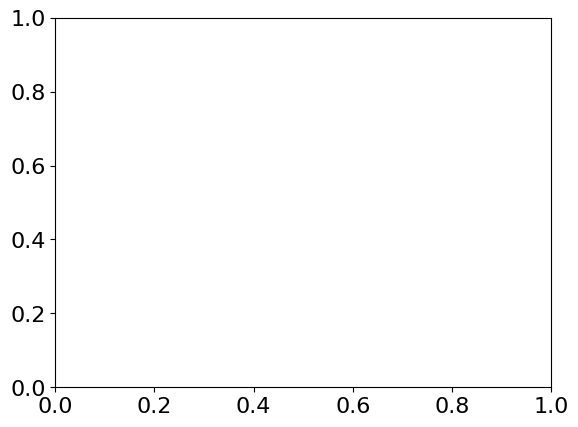

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :10.030075187969924

[0. 0. 1.]


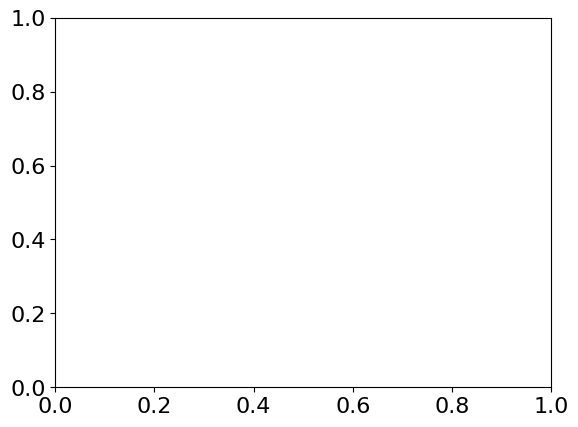

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :9.583959899749374

[0. 0. 1.]


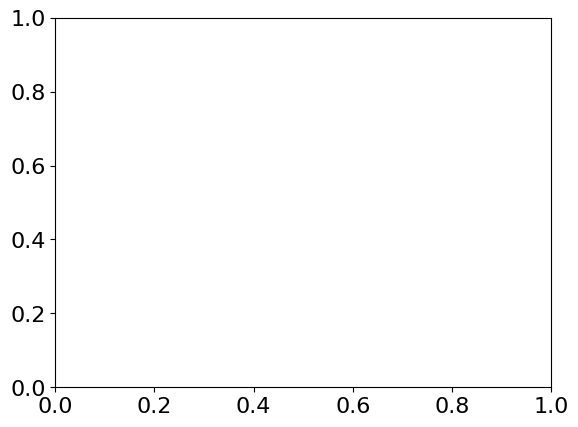

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :9.137844611528822

[0. 0. 1.]


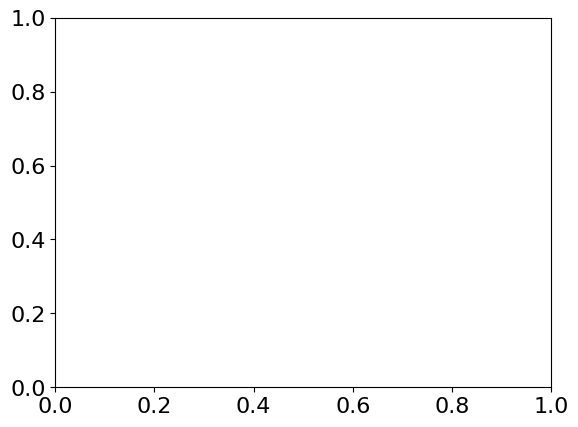

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :8.691729323308271

[0. 0. 1.]


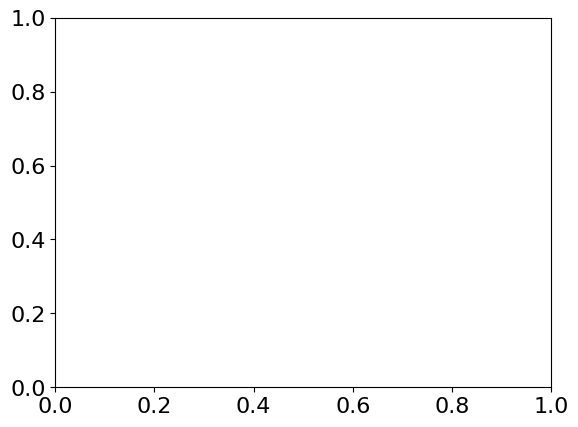

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :8.24561403508772

[0. 0. 1.]


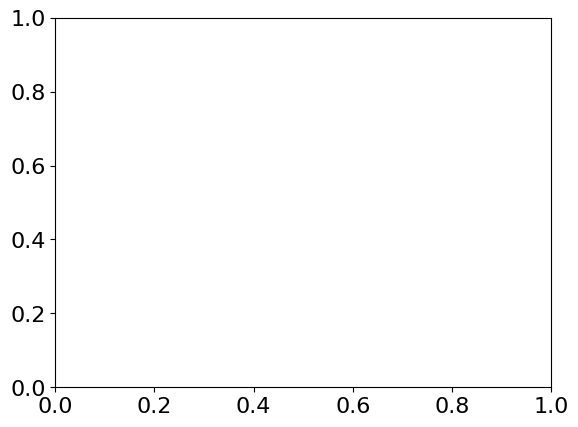

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :7.799498746867167

[0. 0. 1.]


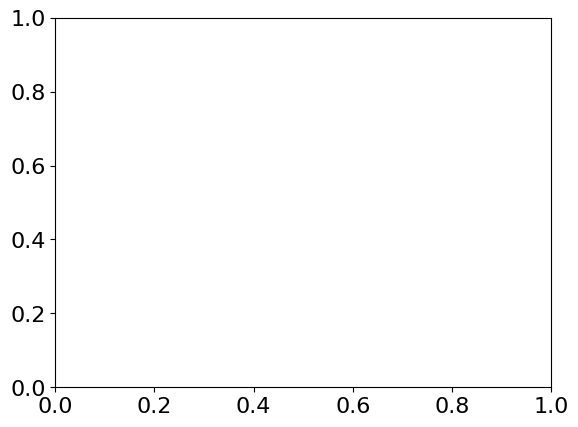

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :7.353383458646616

[0. 0. 1.]


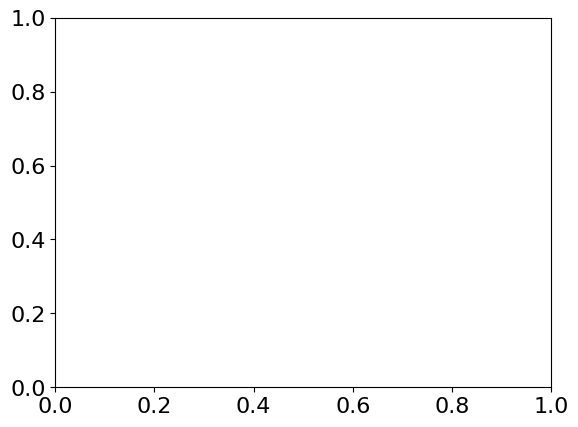

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :6.907268170426066

[0. 0. 1.]


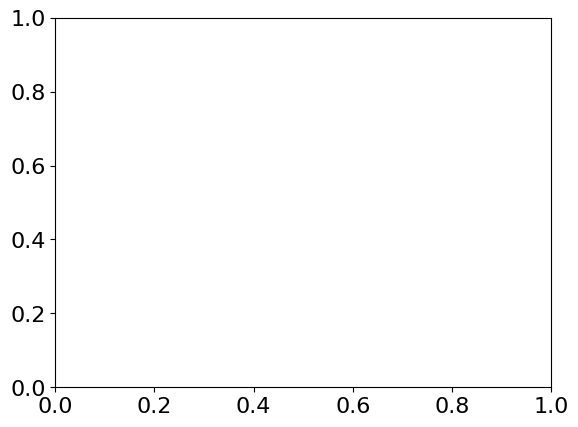

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :6.461152882205515

[0. 0. 1.]


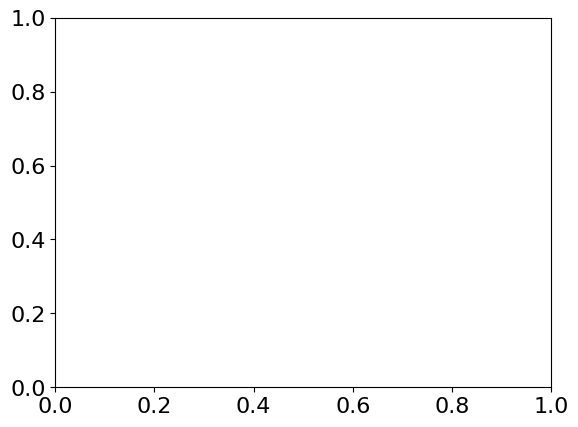

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :6.015037593984964

[0. 0. 1.]


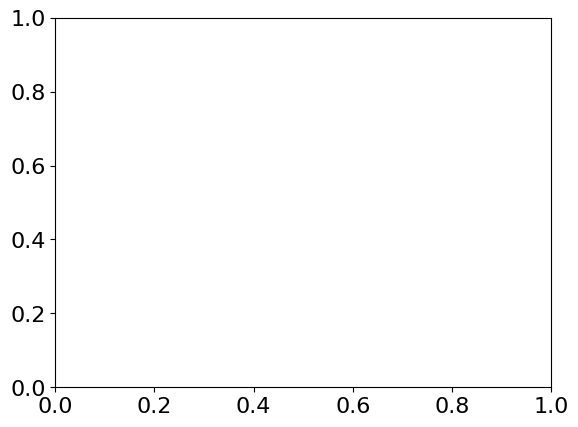

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :5.568922305764411

[0. 0. 1.]


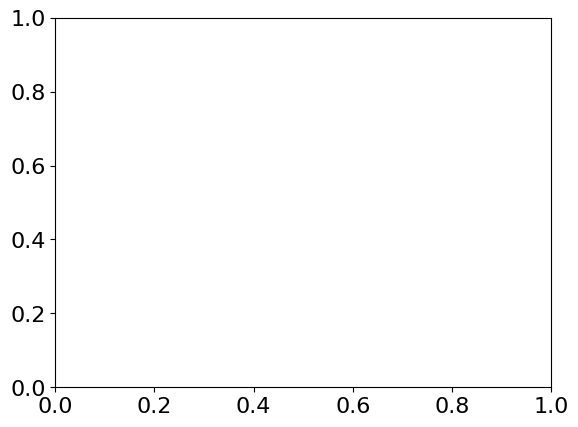

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :5.12280701754386

[0. 0. 1.]


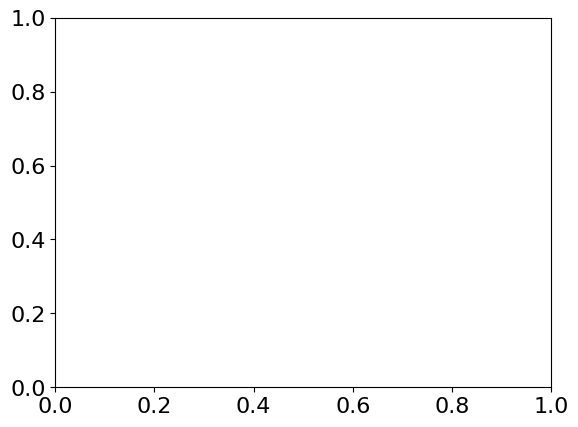

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :4.676691729323308

[0. 0. 1.]


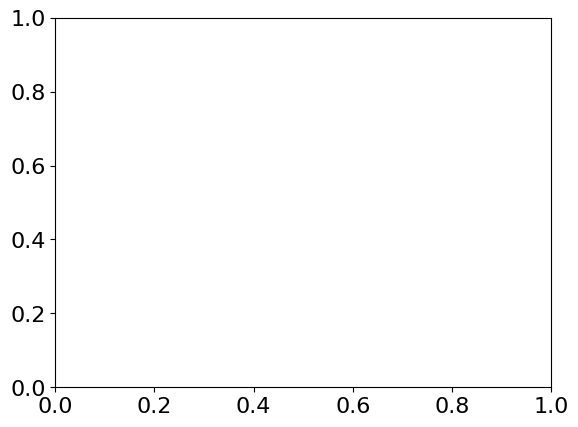

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :4.230576441102757

[0. 0. 1.]


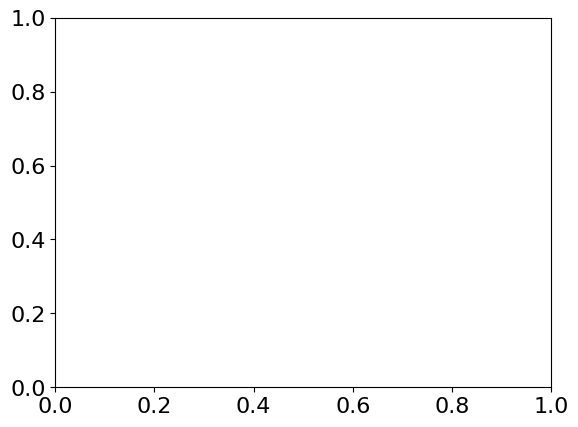

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :3.7844611528822054

[0. 0. 1.]


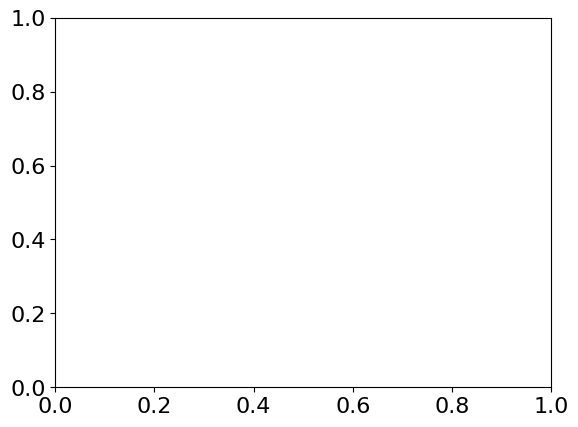

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :3.338345864661654

[0. 0. 1.]


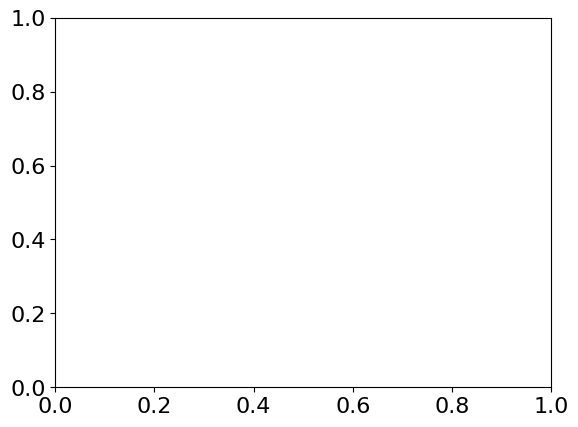

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :2.8922305764411025

[0. 0. 1.]


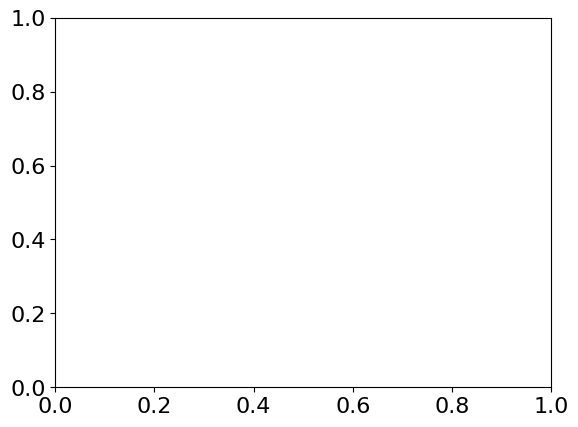

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :2.4461152882205517

[0. 0. 1.]


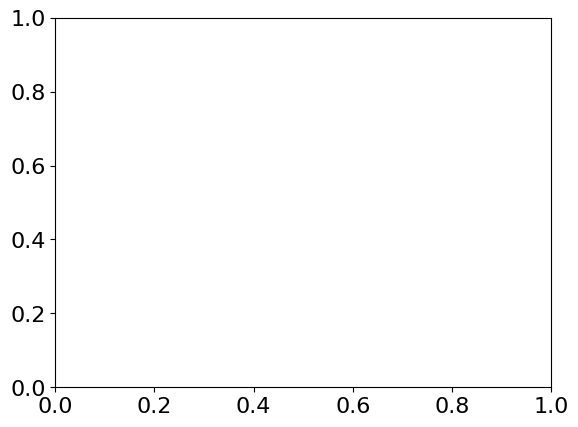

Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!
Hermiticity check passed!
Symmetry checks passed!

COMPLETE ANGLE :2.0

[0. 0. 1.]


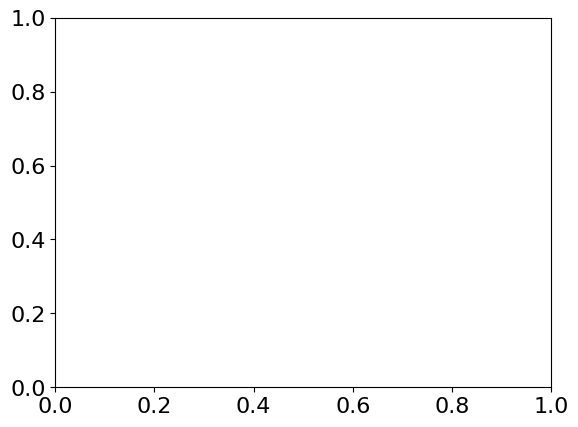

In [25]:
# TRIANGLE animation
from matplotlib.animation import PillowWriter
from matplotlib import gridspec

ket = [r'0', r'1']
labels = [r'0', r'1']
for i in range(3 - 1):
    labels = str_tens(labels, ket)
J = 1200
intervals = 400
angles = np.linspace(3*(np.pi/180), np.pi, intervals)[::-1]
ts = np.linspace(0, 0.02, 200)

intervals = 200
#holds = np.linspace(0, 350 * pulse_time, intervals)

free_t = pulse_time*100
params = [pulse_time, free_t, rabi_frequency]

tri_initial = np.zeros(2**3)
tri_initial[1] = 1 

metadata = dict(title='Movie', artist='codinglikemad')
writer = PillowWriter(fps=50, metadata=metadata)

fig = plt.figure(figsize=(15, 5))
spec = gridspec.GridSpec(ncols=2, nrows=1,
                         width_ratios=[1, 2], wspace=0.3)
ax1 = fig.add_subplot(spec[0], projection='polar')
ax2 = fig.add_subplot(spec[1])

with writer.saving(fig, f'TRIANGLE_ONE_FLIP.gif', 100):
    for i in angles:
        ax1.plot([0, 0], [0, 1])
        ax1.plot([0, i], [0, 1])
        ax1.set_rmax(1)
        ax1.set_rticks([]) 

        
            
        
        tri_H = construct_H(3, J, 0, 1, 1, 3, params, no_pulse, tri=True, angle=i)
        pops = tri_H.evolve(tri_initial, 0, ts)
        result = up_prob(3, 3, pops)
        
        print('\nCOMPLETE ANGLE :' + str(180*i/np.pi) + '\n')
        
    

        #tri_initial = (eigenvectors[0] + eigenvectors[7])/np.sqrt(2)

        
        up_pop_plot(3, result, ts, 'Free evolution time (ms)', fig, ax2)
        
        
        writer.grab_frame()
        ax1.clear()
        ax2.clear()

[0. 1.]
